# Guess the neuron Project: *Baseline Approach*
We start with a simple baseline approach to predict the neuron type based on average summuries.

## **1.** Defining the analysis population

### Goal of this section
Before choosing any model, we need to define a biologically coherent and statistically usable population of neurons. In this project we are interested in **functional classification**, so the relevant units are those for which structural annotations can be linked to functional recordings.

### Why we start from the unified `units` table
The `microns_datacleaner` package provides a cleaned unit table through `process_nucleus_data`. According to the documentation, this table:
- includes all AIBS-classified units,
- removes duplicated / overmerged objects,
- guarantees unique `nucleus_id` and `pt_root_id`,
- and can add manually coregistered `session`, `scan_idx`, and `unit_id` so that structural units can be matched to functional data.

### Filtering strategy
We restricted the analysis to neurons satisfying three conditions:

1. **Excitatory neurons only**  
   This is consistent with the functional imaging side of MICrONS, which focuses on excitatory neurons.

2. **Matched neurons only**  
   Here “matched” means that a neuron in the cleaned anatomical table has a valid correspondence with a neuron in the functional recordings, i.e. it has associated `session`, `scan_idx`, and `unit_id`.

3. **V1 only**  
   We begin from primary visual cortex because it is the cleanest area for a first analysis of visually evoked functional responses and laminar organization.


In [9]:
import pandas as pd
import numpy as np
import microns_datacleaner as mic
import microns_datacleaner.filters as fl

# 1. Build the unified table with one best functional match per neuron
cleaner = mic.MicronsDataCleaner(datadir="../data", version=1718, download_policy="minimum")
units, segments = cleaner.process_nucleus_data(functional_data="best_only")

print("units shape:", units.shape)
print("segments shape:", segments.shape)
print("\nColumns:")
print(sorted(units.columns.tolist()))

# 2. Basic sanity checks on the full table
for col in ["classification_system", "cell_type", "layer", "brain_area", "tuning_type", "session", "scan_idx", "unit_id"]:
    if col in units.columns:
        print(f"\nValue counts for {col}:")
        print(units[col].value_counts(dropna=False).head(20))

# 3. Restrict to the population relevant for the project
#    excitatory + matched functional + V1
u = units.copy()

# adjust these only if the exact column names/categories differ in your table
if "classification_system" in u.columns:
    u = u[u["classification_system"] == "excitatory_neuron"]

if "tuning_type" in u.columns:
    u = u[u["tuning_type"] != "not_matched"]

if "brain_area" in u.columns:
    u = u[u["brain_area"] == "V1"]

print("\nFiltered population shape (excitatory, matched, V1):", u.shape)

# 4. Check candidate targets
for col in ["layer", "cell_type"]:
    if col in u.columns:
        print(f"\nFiltered value counts for {col}:")
        print(u[col].value_counts(dropna=False))

# 5. Check uniqueness of neurons
for col in ["pt_root_id", "nucleus_id"]:
    if col in u.columns:
        print(f"\nUnique {col}: {u[col].nunique()} / rows: {len(u)}")

# 6. Missingness on likely important columns
important_cols = [c for c in ["pt_root_id", "nucleus_id", "layer", "cell_type", "brain_area",
                              "tuning_type", "session", "scan_idx", "unit_id"] if c in u.columns]
print("\nMissing values in important columns:")
print(u[important_cols].isna().sum().sort_values(ascending=False))

Transform positions: 100%|██████████| 94014/94014 [00:00<00:00, 134792.12it/s]


units shape: (90434, 20)
segments shape: (5, 5)

Columns:
['brain_area', 'cc_abs', 'cell_type', 'classification_system', 'gDSI', 'gOSI', 'layer', 'nucleus_id', 'pref_dir', 'pref_ori', 'pt_position_x', 'pt_position_y', 'pt_position_z', 'pt_root_id', 'scan_idx', 'session', 'strategy_axon', 'strategy_dendrite', 'tuning_type', 'unit_id']

Value counts for classification_system:
classification_system
excitatory_neuron    63822
nonneuron            18762
inhibitory_neuron     7850
Name: count, dtype: int64

Value counts for cell_type:
cell_type
23P          19658
4P           14729
6P-IT        11670
5P-IT         7909
astrocyte     7129
oligo         6909
6P-CT         6775
BC            3333
MC            2454
microglia     2413
5P-ET         2149
BPC           1499
OPC           1461
5P-NP          932
pericyte       850
NGC            564
Name: count, dtype: int64

Value counts for layer:
layer
L6      27447
L2/3    25153
L4      18770
L5      17576
L1       1487
NaN         1
Name: coun

### Results
The full cleaned table contains **90,434** units. Among them:
- **63,822** are classified as excitatory neurons,
- **13,005** are matched to functional recordings,
- and after restricting to **matched excitatory neurons in V1**, we obtain **8,910 neurons**.

Importantly, in the filtered table:
- `pt_root_id` is unique for every row,
- `nucleus_id` is unique for every row,
- and the key columns (`layer`, `cell_type`, `session`, `scan_idx`, `unit_id`) have no missing values.

This confirms that the filtered dataset is clean and suitable for supervised learning.

### Choosing the initial prediction target
We considered two possible labels:
- `layer`
- `cell_type`

After filtering, the class distribution for **layer** is:
- L2/3: 4247
- L4: 2670
- L5: 1615
- L6: 363
- L1: 15

The class distribution for **cell_type** is:
- 23P: 4213
- 4P: 2845
- 5P-IT: 1169
- 5P-ET: 320
- 6P-IT: 216
- 6P-CT: 121
- 5P-NP: 26

We exclude **L1** because it is too underrepresented.
> L1 was excluded from the primary classifier because it had only 15 neurons in the matched excitatory V1 population, which is too few for stable multiclass training and especially too few for session-grouped evaluation. This is a statistical decision, not a biological claim that L1 is unimportant.

### Interpretation
At this stage, the best primary target is **layer** rather than `cell_type`.

This choice is justified for two reasons:
1. **Neuroscience justification**
Layer is a strong biological axis in cortex: neurons in different layers differ in connectivity, input/output motifs, and often in visually evoked response properties. Therefore asking whether functional responses predict layer is scientifically meaningful.

2. **Machine learning justification**
The layer task has enough support in four classes (L2/3, L4, L5, L6), while `cell_type` is much more imbalanced. Moreover, many cell-type labels are partially layer-coded (`23P`, `4P`, `5P-*`, `6P-*`), so a direct cell-type classifier would be harder to interpret initially.

Therefore, the first supervised task will be:

**Predict cortical layer (L2/3, L4, L5, L6) from functional responses in matched excitatory V1 neurons.**

Fine-grained cell type classification will be treated as a secondary analysis, ideally performed **within layer**.

---

## **2.** Inspecting the functional recordings

### Goal of this section
Before deciding how to represent neural activity, we need to understand the structure of the functional dataset:
- how recordings are organized across sessions,
- whether stimuli are repeated,
- what the shape of a trial is,
- and whether trial-averaged / stimulus-locked features are feasible.

This step is necessary before choosing between simple summary features, stimulus averages, or raw time-series models.

### What the functional reader provides
The `MicronsFunctionalReader` API gives direct access to:
- session-specific trial data,
- condition hashes identifying stimuli,
- per-trial response matrices,
- and metadata such as stimulus times, treadmill, and pupil signals.

This is ideal for determining whether the functional dataset supports repeat-based analyses.

In [10]:
import microns_datacleaner as mic
import pandas as pd
import numpy as np

# Keep only the layer target we decided to use
u_layer = u[u["layer"].isin(["L2/3", "L4", "L5", "L6"])].copy()
print("u_layer shape:", u_layer.shape)
print("\nLayer counts:")
print(u_layer["layer"].value_counts())

# Build session keys available in the matched V1 excitatory set
u_layer["session_key"] = (
    u_layer["session"].astype(int).astype(str) + "_" +
    u_layer["scan_idx"].astype(int).astype(str)
)

print("\nNumber of distinct session_key:", u_layer["session_key"].nunique())
print("Session_key counts:")
print(u_layer["session_key"].value_counts())

# Open the functional reader
fr = mic.MicronsFunctionalReader(datadir="../data")

# Optional: inspect structure once
print("\nFunctional file structure:")
fr.print_structure()

# For each session_key, inspect how many condition hashes exist
session_keys = sorted(u_layer["session_key"].unique())

session_hash_summary = []
for sk in session_keys:
    hashes_all = fr.get_hashes_by_session(sk, return_unique=False)
    hashes_unique = fr.get_hashes_by_session(sk, return_unique=True)
    session_hash_summary.append({
        "session_key": sk,
        "n_trials_listed": len(hashes_all),
        "n_unique_hashes": len(hashes_unique)
    })

session_hash_summary = pd.DataFrame(session_hash_summary).sort_values("session_key")
print("\nSession/hash summary:")
print(session_hash_summary)

# Pick one session key to inspect in more detail: the one with most neurons
top_session = u_layer["session_key"].value_counts().idxmax()
print("\nTop session_key:", top_session)

hashes_all = fr.get_hashes_by_session(top_session, return_unique=False)
hashes_unique = list(fr.get_hashes_by_session(top_session, return_unique=True))

print("\nFirst 20 hashes in top session:")
print(hashes_all[:20])

print("\nNumber of repeated presentations in top session:")
print("total hashes listed:", len(hashes_all))
print("unique hashes:", len(hashes_unique))

# Inspect one example hash
example_hash = hashes_all[0]
print("\nExample hash:", example_hash)

resp = fr.get_responses_by_hash(example_hash, brain_area="V1")
print("\nType of resp:", type(resp))
print("Number of trial entries for this hash:", len(resp))

if len(resp) > 0:
    print("\nKeys in first response entry:")
    print(resp[0].keys())
    print("Session:", resp[0]["session"])
    print("Trial idx:", resp[0]["trial_idx"])
    print("Responses type:", type(resp[0]["responses"]))
    try:
        print("Responses shape:", np.array(resp[0]["responses"]).shape)
    except:
        print("Could not infer response shape directly")

# Inspect one trial directly
trial0 = fr.get_trial(top_session, 0, brain_area="V1")
print("\nTrial 0 keys:")
print(trial0.keys())

for k, v in trial0.items():
    if hasattr(v, "shape"):
        print(k, "shape:", v.shape)
    else:
        print(k, "type:", type(v))

u_layer shape: (8895, 20)

Layer counts:
layer
L2/3    4247
L4      2670
L5      1615
L6       363
Name: count, dtype: int64

Number of distinct session_key: 13
Session_key counts:
session_key
6_4    916
6_7    874
9_3    818
8_5    780
6_2    774
4_7    715
5_7    701
6_6    697
5_6    686
9_4    680
7_3    552
9_6    428
7_5    274
Name: count, dtype: int64

Functional file structure:

Structure of: /Users/katiarusso/Documents/VS CODE/Classes/Neuroscience/katia/FIRST APPROACH/../data/functional/microns_functional.h5
📂 BRAIN_AREAS/ 
    📂 AL/ 
        🔗 4_7                -> /sessions/4_7
        🔗 5_6                -> /sessions/5_6
        🔗 5_7                -> /sessions/5_7
        🔗 6_2                -> /sessions/6_2
        🔗 6_4                -> /sessions/6_4
        ... and 9 more items
    📂 LM/ 
        🔗 4_7                -> /sessions/4_7
        🔗 5_6                -> /sessions/5_6
        🔗 5_7                -> /sessions/5_7
        🔗 6_2                -> /sessions

### Clarifying the functional dataset structure

At this point it is important to distinguish several concepts.

A **session** is one experimental recording session, and `scan_idx` identifies a specific scan within that session. Their combination (`session_key = session_scan`) identifies one functional recording block, for example `6_4`.

A **trial** is one individual presentation of one stimulus condition during a given session/scan. Each trial contains:
- `responses`: neural activity of all neurons recorded in that session during that trial,
- `stim_times`: the stimulus time axis,
- `treadmill`: locomotion signal,
- `pupil`: pupil/eye-related variables.

A **stimulus condition** is identified by a **condition hash**. If two trials have the same hash, they correspond to repeated presentations of the same visual condition.

This distinction matters because the scientific question is not just whether raw activity differs across neurons, but whether neurons differ in a stimulus-locked and reproducible way.

### Results of the inspection

#### Session organization
After restricting to the layer-classification population, we have **8,895 neurons** distributed across **13 session/scan combinations** (`session_key`).

The largest sessions are:
- `6_4`: 916 neurons
- `6_7`: 874 neurons
- `9_3`: 818 neurons
- `8_5`: 780 neurons
- `6_2`: 774 neurons

This shows that the matched population is not concentrated in a single scan, but spread across multiple sessions.

#### Trial and stimulus structure
For each session:
- there are **464 listed trials**
- but only **280 unique condition hashes**

This means that many stimuli are **repeated across trials**, which is a crucial observation.

#### Trial contents
A single trial contains:
- `responses`: neural activity matrix of shape `(n_neurons, T)`
- `stim_times`: stimulus time vector
- `treadmill`: locomotion signal
- `pupil`: eye/pupil-related signal

For example, in session `6_4`, one trial has:
- `responses`: `(5999, 75)`
- `stim_times`: `(75,)`
- `treadmill`: `(75, 1)`
- `pupil`: `(4, 75)`

For one example condition hash, the functional reader returned **28 trial entries**, each containing a response matrix.

### Interpretation:

1. **Neuroscience interpretation**  
The presence of repeated condition hashes means the dataset contains repeated presentations of the same stimulus condition. This is extremely important because it allows us to separate:
    - stimulus-locked response structure,
    - from trial-to-trial variability.  
  
    That makes the analysis much more aligned with standard neuroscience practice: rather than using raw calcium traces directly, we can first summarize how consistently each neuron responds to repeated stimuli.

2. **Machine learning interpretation**   
The functional data are trial-structured and repeated, so the first representation should **not** be a raw CNN input.  
  
    Instead, the best first feature space should be based on:
    - trial-averaged responses,
    - response amplitude and temporal summaries,
    - reliability across repeated stimulus presentations,
    - and possibly low-dimensional embeddings of these summaries.  
    
    This gives a lower-dimensional, more interpretable, and statistically safer representation than raw traces, especially because the rarest target class (L6) has only 363 neurons.

### Conclusion of this section
The inspection strongly supports a **stimulus-locked, trial-aware feature extraction strategy** as the next step.

So, before any classifier, we should construct functional descriptors such as:
- mean evoked response,
- peak response,
- latency to peak,
- temporal center of mass,
- response variability,
- repeat reliability,
- and possibly condition-specific averages.

Only after evaluating the separability of layers in this feature space should we consider more complex temporal models.

---

### Why we do not start from a CNN on raw time series

At this stage we have **not** proved that a CNN cannot work.

What we have shown is that the dataset structure gives us a better-justified first baseline.

The reasons are:

1. **Repeated stimuli are available**  
   Since the same condition hash appears across multiple trials, we can build trial-averaged and reliability-based features. These are biologically interpretable and explicitly linked to stimulus processing.

2. **The target classes are not huge**  
   In the primary task, the rarest class (L6) is relatively small. A high-capacity temporal model would therefore have a higher overfitting risk than a lower-dimensional summary-feature baseline.

3. **Trials have different lengths across conditions**  
   Example trials had 75 or 113 time bins. Raw time-series modeling would require early design choices about alignment, truncation, or padding, whereas summary features are immediately comparable.

For these reasons, the most rigorous strategy is:
- first test whether simple stimulus-aware summaries already separate layers,
- only then move to more complex temporal models if the simple representation appears insufficient.

---

### Why are we not using the raw neural activity time series directly?
Because at this stage the scientific question is not ***Can a flexible model fit high-dimensional traces?***, but ***Is there stable layer-related signal in functional responses that generalizes across recording blocks?*** Those are not the same question.  

The raw object in the functional file is indeed a time series: for one trial, each neuron has a response vector over time. But that raw time series is nested inside a structure with repeated stimulus conditions, variable trial lengths, and session-specific neuron populations.  

The course logic for neural encoding starts from average responses across repeated presentations and from variability around that average, not from feeding raw traces directly into a black box. Your notes explicitly frame the problem this way: repeat the same stimulus over many trials, compute average response summaries, and then characterize trial-to-trial variability. [lecture notes]  

That is why we started from stimulus-aware summaries:
- they are not arbitrary reductions,
- they are directly motivated by standard sensory-neuroscience methodology (check lecture notes chapter 1/PSTH/STA..),
- and they let us ask whether layer information is present before adding model complexity.  

This does not prove that raw traces are useless. It means only that raw traces are not the first representation to trust for the main project claim.

### Why can that still be the right choice scientifically?

Because repeated presentations let you estimate two distinct things:
the stimulus-locked mean response, and the trial-to-trial variability around it. Both are central objects in neural coding. A recent Nature Reviews Neuroscience review also emphasizes that variability quenching under repeated stimulus presentations is a characteristic feature of visual cortex responses.   

[Response sub-additivity and variability quenching in visual cortex](https://www.nature.com/articles/s41583-024-00795-0?utm_source=chatgpt.com)  
[The Relationship between Trial-by-Trial Variability and Oscillations of Cortical Population Activity](https://www.nature.com/articles/s41598-019-53270-7?utm_source=chatgpt.com)

---

## **3.** Constructing the first functional feature representation

### Goal of this section
The purpose of this section is to construct the first interpretable functional representation of each neuron.

Instead of training directly on raw trial-wise time series, we start from repeated stimulus presentations and summarize, for each neuron:
- how strong its average evoked response is,
- when the response peaks,
- how variable its response is over time,
- and how reliable it is across repeated trials.

### Why we prototype within one session first
Functional recordings are organized by session/scan, and each session has its own neuron indexing and trial structure. For this reason, the cleanest first step is to prototype feature extraction within a single session before extending it across all sessions.

We chose the largest available matched V1 session:
- `session_key = 6_4`
- 916 matched neurons in the filtered table

After mapping unit IDs to the V1 functional matrix, 905 neurons were successfully found in the V1 response matrix and retained for feature extraction.

### Stimulus repetition structure
In session `6_4`:
- there are 464 trials,
- corresponding to 280 unique condition hashes.

Thus many stimuli are repeated. Among the 280 conditions:
- the median repetition count is 1,
- the upper quartile is 2,
- and some conditions are repeated up to 10 times.

To obtain trial-reliable summaries, we restricted the prototype analysis to the **136 condition hashes repeated at least twice**.

### Feature extraction strategy
For each repeated condition hash, we averaged the response across repetitions and computed, for every neuron:
- `peak`: maximum of the averaged response
- `trough`: minimum of the averaged response
- `mean_resp`: mean response over time
- `std_resp`: temporal standard deviation
- `argpeak`: time index of the peak response
- `com`: temporal center of mass of the response profile
- `reliability`: mean pairwise correlation across repeated trials

Then, to obtain one row per neuron, we aggregated these condition-level features across hashes using mean and standard deviation.

In [11]:
import numpy as np
import pandas as pd

# Primary task population
u_primary = u_layer.copy()

# Prototype on the largest session
session0 = u_primary["session_key"].value_counts().idxmax()
u0 = u_primary[u_primary["session_key"] == session0].copy()

print("Prototype session:", session0)
print("Neurons in prototype session:", len(u0))
print("Layer counts in prototype session:")
print(u0["layer"].value_counts())

# Build the row map correctly for V1-only responses
all_unit_ids = fr.f[f"sessions/{session0}/meta/unit_ids"][:]
v1_idx = fr.f[f"sessions/{session0}/meta/area_indices/V1"][:]
v1_unit_ids = all_unit_ids[v1_idx]

unitid_to_row_v1 = {int(uid): i for i, uid in enumerate(v1_unit_ids)}

u0["func_row"] = u0["unit_id"].astype(int).map(unitid_to_row_v1)

print("\nMatched neurons found in V1 functional matrix:", u0["func_row"].notna().sum(), "/", len(u0))

u0 = u0[u0["func_row"].notna()].copy()
u0["func_row"] = u0["func_row"].astype(int)

# Session hashes
hashes_all = fr.get_hashes_by_session(session0, return_unique=False)
hash_counts = pd.Series(hashes_all).value_counts()

print("\nTrials in session:", len(hashes_all))
print("Unique hashes:", hash_counts.shape[0])

print("\nRepetition count summary:")
print(hash_counts.describe())

print("\nMost repeated hashes:")
print(hash_counts.head(10))

usable_hashes = hash_counts[hash_counts >= 2].index.tolist()
print("\nUsable repeated hashes:", len(usable_hashes))

features = []

# Prototype on first 50 repeated hashes
for h in usable_hashes[:50]:
    resp_list = fr.get_responses_by_hash(h, brain_area="V1")
    resp_list = [r for r in resp_list if r["session"] == session0]

    if len(resp_list) < 2:
        continue

    # stack trials: (n_trials, n_neurons_in_V1, T)
    X = np.stack([r["responses"] for r in resp_list], axis=0)

    # keep only our matched neurons from this session
    X = X[:, u0["func_row"].values, :]

    # average across repeated trials for this condition
    Xmean = X.mean(axis=0)   # (n_neurons, T)

    T = Xmean.shape[1]
    t = np.arange(T)

    peak = Xmean.max(axis=1)
    trough = Xmean.min(axis=1)
    mean_resp = Xmean.mean(axis=1)
    std_resp = Xmean.std(axis=1)
    argpeak = Xmean.argmax(axis=1)

    Xshift = Xmean - Xmean.min(axis=1, keepdims=True)
    denom = Xshift.sum(axis=1)
    com = np.where(denom > 0, (Xshift * t).sum(axis=1) / denom, np.nan)

    # repeat reliability: mean pairwise correlation across repetitions
    reliability = []
    for i in range(X.shape[1]):
        Xi = X[:, i, :]
        if Xi.shape[0] < 2:
            reliability.append(np.nan)
            continue
        C = np.corrcoef(Xi)
        iu = np.triu_indices_from(C, k=1)
        reliability.append(np.nanmean(C[iu]))
    reliability = np.array(reliability)

    dfh = pd.DataFrame({
        "pt_root_id": u0["pt_root_id"].values,
        "layer": u0["layer"].values,
        "hash": h,
        "peak": peak,
        "trough": trough,
        "mean_resp": mean_resp,
        "std_resp": std_resp,
        "argpeak": argpeak,
        "com": com,
        "reliability": reliability,
        "n_repeats": X.shape[0]
    })
    features.append(dfh)

feat = pd.concat(features, ignore_index=True)
print("\nFeature table shape:", feat.shape)
print(feat.head())

feat_neuron = feat.groupby(["pt_root_id", "layer"]).agg({
    "peak": ["mean", "std"],
    "trough": ["mean", "std"],
    "mean_resp": ["mean", "std"],
    "std_resp": ["mean", "std"],
    "argpeak": ["mean", "std"],
    "com": ["mean", "std"],
    "reliability": ["mean", "std"],
    "n_repeats": "mean"
})

feat_neuron.columns = ["_".join(c).strip("_") for c in feat_neuron.columns]
feat_neuron = feat_neuron.reset_index()

print("\nNeuron-level feature table shape:", feat_neuron.shape)
print(feat_neuron.head())

print("\nMissing values per column:")
print(feat_neuron.isna().sum().sort_values(ascending=False).head(20))

print("\nLayer counts in neuron-level feature table:")
print(feat_neuron["layer"].value_counts())

Prototype session: 6_4
Neurons in prototype session: 916
Layer counts in prototype session:
layer
L2/3    497
L5      213
L4      143
L6       63
Name: count, dtype: int64

Matched neurons found in V1 functional matrix: 905 / 916

Trials in session: 464
Unique hashes: 280

Repetition count summary:
count    280.000000
mean       1.657143
std        1.332104
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max       10.000000
Name: count, dtype: float64

Most repeated hashes:
5zQTb77qI+ig8rigx1XU    10
Oup5uAZxF2G7zEJkT+ui    10
ecUQJtcERZJGdqza1k7h    10
KXdTNAGMo1gCWz2Ge8zr    10
7UETOWO5Z8aWuHDBJ2GG    10
GjCMo2GkJp6y5vricadg    10
Sqv4lziRTQgtkUPYRRiM     2
EKhyHmLj04EcBoR25T/e     2
YLuStB2eXkgOS+Cescsy     2
+zKgA9yfzzy8XGl9oM1O     2
Name: count, dtype: int64

Usable repeated hashes: 136

Feature table shape: (45250, 11)
           pt_root_id layer                  hash       peak        trough  \
0  864691135763941174  L2/3  5zQTb77qI+ig8rigx1XU   


### Results
The condition-level feature table has shape:
- **45,250 rows × 11 columns**

This corresponds to:
- 905 neurons
- across 50 repeated hashes used in the prototype
- giving approximately 905 × 50 rows.

After aggregation, the neuron-level feature table has shape:
- **905 rows × 17 columns**

No missing values were present in the final feature table.

The layer distribution in the final neuron-level table is:
- L2/3: 497
- L4: 141
- L5: 207
- L6: 60

### Interpretation:

1. **Neuroscience interpretation**
    These features summarize biologically meaningful aspects of visually evoked activity:
    - response magnitude,
    - temporal response profile,
    - and repeat reliability.  
  
    Thus the resulting representation is not an arbitrary compression of the data, but a stimulus-aware description of how each neuron behaves.

2. **Machine learning interpretation**
    This feature table gives a low-dimensional and interpretable baseline for the first layer-classification task.  
  
    At this stage, this is preferable to raw time-series modeling because:
    - it reduces dimensionality strongly,
    - it uses repeated-trial structure explicitly,
    - it keeps one row per neuron,
    - and it allows us to diagnose whether the task has signal before moving to more complex models.

## Conclusion of this section
We now have a clean neuron-level functional feature table for one session. The next step is to test whether these features already show structure by cortical layer using:
- summary statistics by layer,
- PCA / UMAP,
- and a simple baseline classifier.

---

## **4.** Do functional summary features already contain layer information?

### Goal of this section
After constructing one row of functional summary features per neuron, we now ask whether these features already contain structure related to cortical layer.

The purpose is not yet to maximize classification accuracy, but to determine whether the layer label is reflected in the feature space at all.

### Approach
We used the neuron-level feature table from session `6_4` and considered the following summary descriptors:
- response amplitude statistics (`peak_mean`, `peak_std`, `mean_resp_mean`, `std_resp_mean`, etc.)
- timing summaries (`argpeak_mean`, `com_mean`)
- repeat reliability (`reliability_mean`, `reliability_std`)
- average number of repeats

We first examined:
1. mean feature values by layer,
2. the first two principal components (PCA),
3. and the pairwise distances between layer centroids in the original feature space.


Feature columns:
['peak_mean', 'peak_std', 'trough_mean', 'trough_std', 'mean_resp_mean', 'mean_resp_std', 'std_resp_mean', 'std_resp_std', 'argpeak_mean', 'argpeak_std', 'com_mean', 'com_std', 'reliability_mean', 'reliability_std', 'n_repeats_mean']

Mean feature values by layer:
       peak_mean   peak_std   trough_mean    trough_std  mean_resp_mean  \
layer                                                                     
L2/3   26.448328  24.774073  3.701482e-04  1.894491e-03        1.751689   
L4     30.155630  28.580961  1.646381e-05  1.161518e-04        1.879066   
L5     14.340631  13.060170  1.902036e-06  1.331679e-05        1.003348   
L6      7.729249   6.282614  1.121062e-08  7.165590e-09        0.530005   

       mean_resp_std  std_resp_mean  std_resp_std  argpeak_mean  argpeak_std  \
layer                                                                          
L2/3        1.799244       4.204562      3.848323     45.810302    29.748163   
L4          1.918700       

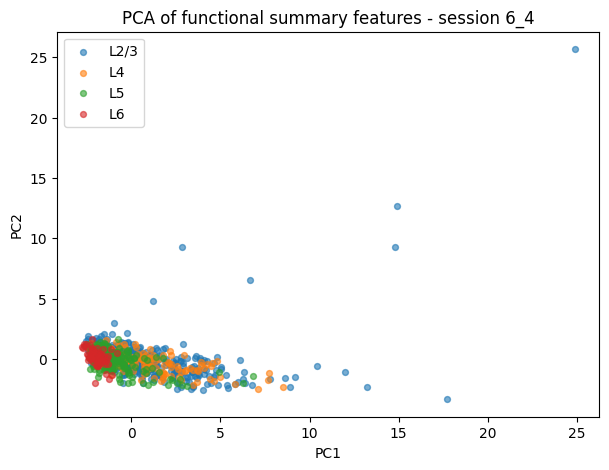


Pairwise distances between layer centroids:
layer       L2/3         L4         L5         L6
layer                                            
L2/3    0.000000   5.378450  17.082449  26.770594
L4      5.378450   0.000000  22.441178  32.108496
L5     17.082449  22.441178   0.000000   9.769247
L6     26.770594  32.108496   9.769247   0.000000


In [12]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Select numeric features
feature_cols = [c for c in feat_neuron.columns if c not in ["pt_root_id", "layer"]]
X = feat_neuron[feature_cols].copy()
y = feat_neuron["layer"].copy()

print("Feature columns:")
print(feature_cols)

# 1. Summary by layer
layer_summary = feat_neuron.groupby("layer")[feature_cols].mean()
print("\nMean feature values by layer:")
print(layer_summary)

# 2. Standardize
scaler = StandardScaler()
Xz = scaler.fit_transform(X)

# 3. PCA
pca = PCA(n_components=2)
Xpca = pca.fit_transform(Xz)

print("\nExplained variance ratio:")
print(pca.explained_variance_ratio_)
print("Total explained variance (2 PCs):", pca.explained_variance_ratio_.sum())

pca_df = pd.DataFrame({
    "PC1": Xpca[:, 0],
    "PC2": Xpca[:, 1],
    "layer": y.values
})

print("\nPCA means by layer:")
print(pca_df.groupby("layer")[["PC1", "PC2"]].mean())

# 4. Plot
plt.figure(figsize=(7, 5))
for layer in sorted(pca_df["layer"].unique()):
    idx = pca_df["layer"] == layer
    plt.scatter(pca_df.loc[idx, "PC1"], pca_df.loc[idx, "PC2"], s=18, alpha=0.6, label=layer)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"PCA of functional summary features - session {session0}")
plt.legend()
plt.show()

# 5. Check class-separation in the original feature space through simple distances
layer_centroids = feat_neuron.groupby("layer")[feature_cols].mean()
print("\nPairwise distances between layer centroids:")
from sklearn.metrics import pairwise_distances
D = pd.DataFrame(
    pairwise_distances(layer_centroids),
    index=layer_centroids.index,
    columns=layer_centroids.index
)
print(D)

### Results

#### Mean feature values by layer
The average feature values show a clear gradient across layers.

In particular:
- `peak_mean`, `mean_resp_mean`, and `std_resp_mean` are highest in **L4** and **L2/3**,
- lower in **L5**,
- and lowest in **L6**.

For example:
- `peak_mean` decreases from about **30.2 in L4** and **26.4 in L2/3**
  to **14.3 in L5**
  and **7.7 in L6**.
- `mean_resp_mean` follows the same pattern:
  **1.88 (L4)**, **1.75 (L2/3)**, **1.00 (L5)**, **0.53 (L6)**.

By contrast, timing-related features such as `argpeak_mean` and `com_mean` are very similar across layers.

#### PCA
The first two principal components explain:
- **43.9%** of the variance for PC1
- **13.8%** for PC2
- for a total of **57.7%**.

The layer means in PCA space are:
- L4: strongly positive on PC1
- L2/3: moderately positive on PC1
- L5: negative on PC1
- L6: more strongly negative on PC1

Thus PC1 captures a broad ordering from superficial to deeper layers.

However, the scatter plot does not show cleanly separated clusters: the classes overlap substantially, especially near the center of the distribution.

#### Pairwise centroid distances
The distances between layer centroids confirm the same pattern.

The closest pair is:
- **L2/3 vs L4**: distance ≈ **5.38**

The next closest deep pair is:
- **L5 vs L6**: distance ≈ **9.77**

The largest distances are between superficial and deep layers:
- **L4 vs L6**: distance ≈ **32.11**
- **L2/3 vs L6**: distance ≈ **26.77**

### Interpretation:

1. **Neuroscience interpretation**
  These results suggest that the current functional summaries capture a broad laminar gradient in visually evoked response properties.  
    
    The strongest differences appear in response magnitude and variability rather than in coarse timing. This is biologically plausible: layer organization may affect how strongly neurons respond and how variable those responses are, even if simple timing summaries remain similar.

2. **Machine learning interpretation**
  The feature space already contains layer signal, but the signal is not trivially separable in two unsupervised dimensions. This is an important point:   
    - the problem is **not hopeless**,
    - but it is also **not so easy** that layers form obvious clusters.

Therefore the next correct step is a **simple supervised baseline classifier**, which can test whether the layer signal is predictive above chance and identify which features are most informative.

## Conclusion
The current feature representation appears informative enough to justify supervised classification.

The evidence suggests a coarse separation between:
- superficial layers (L2/3, L4)
- and deeper layers (L5, L6),

with weaker separation within those groups.

This supports continuing with a baseline classifier before considering more complex models.

---

## **5.** Extending the feature representation across all sessions

### Goal of this section
The objective of this step is to move from a single-session prototype to a full dataset representation.

Because matched V1 excitatory neurons are distributed across multiple functional recording blocks, the final feature table must include neurons from all available sessions and retain session identity for later grouped evaluation.

### Why session identity must be preserved
A `session_key` identifies one specific functional recording block, i.e. one `(session, scan_idx)` pair. Different session keys correspond to different recording blocks with:
- different neuron populations,
- their own `unit_ids`,
- their own trial structure,
- and their own repeated stimulus presentations.

Therefore, neurons from the same session are not fully independent from one another in the evaluation sense. This is why `session_key` must be kept in the feature table: it will later be used to define group-based train/test splits.


### Why building both a 50 hashes feature table and a all repeated hashes feature table
We start with a 50-hash version, since it is useful as a prototype because it:
- reduced computational cost,
- emphasized more repeated conditions,
- and allow us to validate the feature extraction pipeline quickly.

However, for the main analysis it is preferable to use **all repeated hashes**, because:
- this removes an arbitrary cutoff,
- makes the representation less heuristic-dependent,
- and uses the full repeated-stimulus information available in each session.

Since every session contains the same number of repeated hashes (**136**), this also improves comparability across sessions.

**Prototype / Exploratory feature extraction on a restricted repeated-stimulus subset (50 hashes).**  


In [13]:
'''import numpy as np
import pandas as pd

# Primary task population: matched excitatory V1 neurons, layers L2/3-L6
u_primary = u_layer.copy()
u_primary["session_key"] = (
    u_primary["session"].astype(int).astype(str) + "_" +
    u_primary["scan_idx"].astype(int).astype(str)
)

print("Total neurons in primary population:", len(u_primary))
print("Number of sessions:", u_primary["session_key"].nunique())
print(u_primary["session_key"].value_counts())

all_feat_neuron = []
session_reports = []

session_keys = sorted(u_primary["session_key"].unique())

for session0 in session_keys:
    print(f"\n===== Processing session {session0} =====")
    
    # neurons from this session
    u0 = u_primary[u_primary["session_key"] == session0].copy()
    n_units_start = len(u0)
    
    # map unit_id to V1-row index in this session
    all_unit_ids = fr.f[f"sessions/{session0}/meta/unit_ids"][:]
    v1_idx = fr.f[f"sessions/{session0}/meta/area_indices/V1"][:]
    v1_unit_ids = all_unit_ids[v1_idx]
    unitid_to_row_v1 = {int(uid): i for i, uid in enumerate(v1_unit_ids)}
    
    u0["func_row"] = u0["unit_id"].astype(int).map(unitid_to_row_v1)
    u0 = u0[u0["func_row"].notna()].copy()
    u0["func_row"] = u0["func_row"].astype(int)
    n_units_found = len(u0)
    
    # repeated hashes in this session
    hashes_all = fr.get_hashes_by_session(session0, return_unique=False)
    hash_counts = pd.Series(hashes_all).value_counts()
    usable_hashes = hash_counts[hash_counts >= 2].index.tolist()
    
    # choose the 50 most repeated hashes for stability/comparability
    usable_hashes = hash_counts[hash_counts >= 2].sort_values(ascending=False).index.tolist()[:50]
    
    print("Neurons retained:", n_units_found, "/", n_units_start)
    print("Repeated hashes available:", (hash_counts >= 2).sum())
    print("Hashes used:", len(usable_hashes))
    
    features = []
    
    for h in usable_hashes:
        resp_list = fr.get_responses_by_hash(h, brain_area="V1")
        resp_list = [r for r in resp_list if r["session"] == session0]
        
        if len(resp_list) < 2:
            continue
        
        # stack repeated trials: (n_trials, n_neurons_in_V1, T)
        X = np.stack([r["responses"] for r in resp_list], axis=0)
        
        # keep only the matched neurons for this session
        X = X[:, u0["func_row"].values, :]
        
        # average across repeated trials
        Xmean = X.mean(axis=0)   # (n_neurons, T)
        
        T = Xmean.shape[1]
        t = np.arange(T)
        
        peak = Xmean.max(axis=1)
        trough = Xmean.min(axis=1)
        mean_resp = Xmean.mean(axis=1)
        std_resp = Xmean.std(axis=1)
        argpeak = Xmean.argmax(axis=1)
        
        Xshift = Xmean - Xmean.min(axis=1, keepdims=True)
        denom = Xshift.sum(axis=1)
        com = np.where(denom > 0, (Xshift * t).sum(axis=1) / denom, np.nan)
        
        # repeat reliability: mean pairwise correlation across repeated trials
        reliability = []
        for i in range(X.shape[1]):
            Xi = X[:, i, :]
            if Xi.shape[0] < 2:
                reliability.append(np.nan)
                continue
            C = np.corrcoef(Xi)
            iu = np.triu_indices_from(C, k=1)
            reliability.append(np.nanmean(C[iu]))
        reliability = np.array(reliability)
        
        dfh = pd.DataFrame({
            "pt_root_id": u0["pt_root_id"].values,
            "layer": u0["layer"].values,
            "session_key": session0,
            "hash": h,
            "peak": peak,
            "trough": trough,
            "mean_resp": mean_resp,
            "std_resp": std_resp,
            "argpeak": argpeak,
            "com": com,
            "reliability": reliability,
            "n_repeats": X.shape[0]
        })
        features.append(dfh)
    
    if len(features) == 0:
        print("No usable features extracted for this session.")
        continue
    
    feat = pd.concat(features, ignore_index=True)
    
    feat_neuron = feat.groupby(["pt_root_id", "layer", "session_key"]).agg({
        "peak": ["mean", "std"],
        "trough": ["mean", "std"],
        "mean_resp": ["mean", "std"],
        "std_resp": ["mean", "std"],
        "argpeak": ["mean", "std"],
        "com": ["mean", "std"],
        "reliability": ["mean", "std"],
        "n_repeats": "mean"
    })
    
    feat_neuron.columns = ["_".join(c).strip("_") for c in feat_neuron.columns]
    feat_neuron = feat_neuron.reset_index()
    
    all_feat_neuron.append(feat_neuron)
    
    session_reports.append({
        "session_key": session0,
        "n_units_start": n_units_start,
        "n_units_found": n_units_found,
        "n_repeated_hashes_available": int((hash_counts >= 2).sum()),
        "n_hashes_used": len(usable_hashes),
        "n_rows_final": len(feat_neuron)
    })

# merge all sessions
feat_all = pd.concat(all_feat_neuron, ignore_index=True)
session_report_df = pd.DataFrame(session_reports).sort_values("session_key")

print("\n===== FINAL REPORT =====")
print("Final feature table shape:", feat_all.shape)
print("\nLayer counts:")
print(feat_all["layer"].value_counts())

print("\nSession counts:")
print(feat_all["session_key"].value_counts().sort_index())

print("\nMissing values:")
print(feat_all.isna().sum().sort_values(ascending=False).head(20))

print("\nPer-session extraction report:")
print(session_report_df)

print("\nHead of final table:")
print(feat_all.head())'''

Total neurons in primary population: 8895
Number of sessions: 13
session_key
6_4    916
6_7    874
9_3    818
8_5    780
6_2    774
4_7    715
5_7    701
6_6    697
5_6    686
9_4    680
7_3    552
9_6    428
7_5    274
Name: count, dtype: int64

===== Processing session 4_7 =====
Neurons retained: 709 / 715
Repeated hashes available: 136
Hashes used: 50

===== Processing session 5_6 =====
Neurons retained: 682 / 686
Repeated hashes available: 136
Hashes used: 50

===== Processing session 5_7 =====
Neurons retained: 698 / 701
Repeated hashes available: 136
Hashes used: 50

===== Processing session 6_2 =====
Neurons retained: 764 / 774
Repeated hashes available: 136
Hashes used: 50

===== Processing session 6_4 =====
Neurons retained: 905 / 916
Repeated hashes available: 136
Hashes used: 50

===== Processing session 6_6 =====
Neurons retained: 692 / 697
Repeated hashes available: 136
Hashes used: 50

===== Processing session 6_7 =====
Neurons retained: 868 / 874
Repeated hashes availabl

**Main feature table used for the primary multi-session analysis.**

In [14]:
'''import numpy as np
import pandas as pd

# Primary task population
u_primary = u_layer.copy()
u_primary["session_key"] = (
    u_primary["session"].astype(int).astype(str) + "_" +
    u_primary["scan_idx"].astype(int).astype(str)
)

all_feat_neuron_full = []
session_reports_full = []

session_keys = sorted(u_primary["session_key"].unique())

for session0 in session_keys:
    print(f"\n===== Processing session {session0} with ALL repeated hashes =====")
    
    u0 = u_primary[u_primary["session_key"] == session0].copy()
    n_units_start = len(u0)
    
    all_unit_ids = fr.f[f"sessions/{session0}/meta/unit_ids"][:]
    v1_idx = fr.f[f"sessions/{session0}/meta/area_indices/V1"][:]
    v1_unit_ids = all_unit_ids[v1_idx]
    unitid_to_row_v1 = {int(uid): i for i, uid in enumerate(v1_unit_ids)}
    
    u0["func_row"] = u0["unit_id"].astype(int).map(unitid_to_row_v1)
    u0 = u0[u0["func_row"].notna()].copy()
    u0["func_row"] = u0["func_row"].astype(int)
    n_units_found = len(u0)
    
    hashes_all = fr.get_hashes_by_session(session0, return_unique=False)
    hash_counts = pd.Series(hashes_all).value_counts()
    
    # use ALL repeated hashes
    usable_hashes = hash_counts[hash_counts >= 2].index.tolist()
    
    print("Neurons retained:", n_units_found, "/", n_units_start)
    print("Repeated hashes used:", len(usable_hashes))
    
    features = []
    
    for h in usable_hashes:
        resp_list = fr.get_responses_by_hash(h, brain_area="V1")
        resp_list = [r for r in resp_list if r["session"] == session0]
        
        if len(resp_list) < 2:
            continue
        
        X = np.stack([r["responses"] for r in resp_list], axis=0)
        X = X[:, u0["func_row"].values, :]
        
        Xmean = X.mean(axis=0)
        T = Xmean.shape[1]
        t = np.arange(T)
        
        peak = Xmean.max(axis=1)
        trough = Xmean.min(axis=1)
        mean_resp = Xmean.mean(axis=1)
        std_resp = Xmean.std(axis=1)
        argpeak = Xmean.argmax(axis=1)
        
        Xshift = Xmean - Xmean.min(axis=1, keepdims=True)
        denom = Xshift.sum(axis=1)
        com = np.where(denom > 0, (Xshift * t).sum(axis=1) / denom, np.nan)
        
        reliability = []
        for i in range(X.shape[1]):
            Xi = X[:, i, :]
            C = np.corrcoef(Xi)
            iu = np.triu_indices_from(C, k=1)
            reliability.append(np.nanmean(C[iu]))
        reliability = np.array(reliability)
        
        dfh = pd.DataFrame({
            "pt_root_id": u0["pt_root_id"].values,
            "layer": u0["layer"].values,
            "session_key": session0,
            "hash": h,
            "peak": peak,
            "trough": trough,
            "mean_resp": mean_resp,
            "std_resp": std_resp,
            "argpeak": argpeak,
            "com": com,
            "reliability": reliability,
            "n_repeats": X.shape[0]
        })
        features.append(dfh)
    
    feat = pd.concat(features, ignore_index=True)
    
    feat_neuron_full = feat.groupby(["pt_root_id", "layer", "session_key"]).agg({
        "peak": ["mean", "std"],
        "trough": ["mean", "std"],
        "mean_resp": ["mean", "std"],
        "std_resp": ["mean", "std"],
        "argpeak": ["mean", "std"],
        "com": ["mean", "std"],
        "reliability": ["mean", "std"],
        "n_repeats": "mean"
    })
    
    feat_neuron_full.columns = ["_".join(c).strip("_") for c in feat_neuron_full.columns]
    feat_neuron_full = feat_neuron_full.reset_index()
    
    all_feat_neuron_full.append(feat_neuron_full)
    
    session_reports_full.append({
        "session_key": session0,
        "n_units_start": n_units_start,
        "n_units_found": n_units_found,
        "n_hashes_used": len(usable_hashes),
        "n_rows_final": len(feat_neuron_full)
    })

feat_all_full = pd.concat(all_feat_neuron_full, ignore_index=True)
session_report_full_df = pd.DataFrame(session_reports_full).sort_values("session_key")

print("\n===== FINAL FULL-HASH REPORT =====")
print("Final feature table shape:", feat_all_full.shape)

print("\nLayer counts:")
print(feat_all_full["layer"].value_counts())

print("\nSession counts:")
print(feat_all_full["session_key"].value_counts().sort_index())

print("\nMissing values:")
print(feat_all_full.isna().sum().sort_values(ascending=False).head(20))

print("\nPer-session extraction report:")
print(session_report_full_df)

print("\nHead:")
print(feat_all_full.head())

feat_all_full.to_pickle("dataset/feat_all_full.pkl")
session_report_full_df.to_pickle("dataset/session_report_full_df.pkl")'''

'import numpy as np\nimport pandas as pd\n\n# Primary task population\nu_primary = u_layer.copy()\nu_primary["session_key"] = (\n    u_primary["session"].astype(int).astype(str) + "_" +\n    u_primary["scan_idx"].astype(int).astype(str)\n)\n\nall_feat_neuron_full = []\nsession_reports_full = []\n\nsession_keys = sorted(u_primary["session_key"].unique())\n\nfor session0 in session_keys:\n    print(f"\n===== Processing session {session0} with ALL repeated hashes =====")\n    \n    u0 = u_primary[u_primary["session_key"] == session0].copy()\n    n_units_start = len(u0)\n    \n    all_unit_ids = fr.f[f"sessions/{session0}/meta/unit_ids"][:]\n    v1_idx = fr.f[f"sessions/{session0}/meta/area_indices/V1"][:]\n    v1_unit_ids = all_unit_ids[v1_idx]\n    unitid_to_row_v1 = {int(uid): i for i, uid in enumerate(v1_unit_ids)}\n    \n    u0["func_row"] = u0["unit_id"].astype(int).map(unitid_to_row_v1)\n    u0 = u0[u0["func_row"].notna()].copy()\n    u0["func_row"] = u0["func_row"].astype(int)\n   

In [15]:
feat_all_full = pd.read_pickle("dataset/feat_all_full.pkl")
session_report_full_df = pd.read_pickle("dataset/session_report_full_df.pkl")

### Results
Using all repeated hashes, the final neuron-level feature table has:

- **8,832 neurons**
- **18 columns**
- **13 sessions**
- **no missing values**

The final layer distribution is:
- L2/3: 4240
- L4: 2651
- L5: 1587
- L6: 354

Thus the full-hash representation preserves almost the entire filtered V1 matched excitatory population.

### Session coverage
All 13 session/scan combinations contributed successfully.

The number of retained neurons per session ranges from:
- **269** in session `7_5`
to
- **905** in session `6_4`.

This confirms that the main feature table is genuinely multi-session.

### Effect of using all repeated hashes
Compared with the earlier 50-hash table, the sample coverage did not change, but the feature values did.

In particular, the mean number of repetitions contributing to each neuron summary decreases (for example `n_repeats_mean` is now around **2.35** in the example rows), which is expected because we are now including all repeated conditions, not only the most repeated ones.

This makes the representation more representative of the real repeated-stimulus structure of the dataset.

### Interpretation

1. **Neuroscience interpretation**  
The final table still represents each neuron through stimulus-aware functional summaries:
    - response magnitude,
    - temporal profile,
    - and repeat reliability.  
  
    These are derived from the raw trial-wise neural activity and are therefore a compact description of each neuron’s functional response phenotype.

2. **Machine learning interpretation**  
This is now the correct table to use for the first serious classifier.  
  
    The feature table:
    - contains one row per neuron,
    - has no missing values,
    - spans all sessions,
    - and includes `session_key`, which allows grouped evaluation.  
  
    This makes it possible to compare two evaluation protocols:
    1. random neuron-wise cross-validation,
    2. session-grouped cross-validation.  
  
    That comparison will provide empirical evidence on whether evaluation is sensitive to session structure.

---

## **6.** Baseline classification and evaluation protocol

### **Goal of this section**
The objective is to evaluate whether functional summary features can predict cortical layer in matched excitatory V1 neurons, and to assess how sensitive the results are to the evaluation protocol.

In particular, we compare:
1. Random neuron-wise cross-validation
2. Session-grouped cross-validation

This comparison is critical to assess whether performance reflects true functional signal or is influenced by session-specific structure.

### **Model choice**

We use **multinomial logistic regression** with L2 regularization.

#### Why logistic regression?

This choice is deliberate:

- It is a **low-capacity, interpretable model**
- It avoids overfitting in a setting with moderate sample size and class imbalance
- It provides a **baseline** to test whether signal exists in the feature space

From a machine learning perspective, this corresponds to the standard practice of starting with a simple linear model before introducing more complex architectures.

From a neuroscience perspective, this is consistent with the idea of decoding based on linear readouts of population activity, which are commonly used as first-order models of neural decoding.


### **Pipeline design**

The classifier is implemented inside a **scikit-learn Pipeline**:

- `StandardScaler`
- `LogisticRegression`

#### Why a pipeline?

This ensures that:
- scaling is fitted **only on training data**
- no information from the test set leaks into preprocessing

This is essential for a valid evaluation.


### **Hyperparameter tuning**

We tune the regularization parameter `C` using:

- **inner cross-validation**
- optimization metric: **balanced accuracy**

#### Why balanced accuracy?

Because class sizes are highly imbalanced:
- L2/3 ≈ 4240
- L6 ≈ 354

Balanced accuracy gives equal weight to each class, avoiding dominance by large classes.


### **Evaluation protocols**

#### 1. Random neuron-wise CV

- Stratified 5-fold split
- Neurons are randomly divided into train/test sets

This evaluates:
> performance when train and test data come from the same pooled distribution


#### 2. Session-grouped CV

- Leave-One-Session-Out (LOSO)
- Entire sessions are held out

This evaluates:
> performance on completely unseen recording blocks

> L1 was excluded from the primary classifier because it had only 15 neurons in the matched excitatory V1 population, which is too few for stable multiclass training and especially too few for session-grouped evaluation. This is a statistical decision, not a biological claim that L1 is unimportant.

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    StratifiedKFold,
    GroupKFold,
    LeaveOneGroupOut,
    GridSearchCV
)
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [17]:
df = feat_all_full.copy()

feature_cols = [c for c in df.columns if c not in ["pt_root_id", "layer", "session_key"]]
X = df[feature_cols].copy()
y = df["layer"].copy()
groups = df["session_key"].copy()

print("Feature columns:", feature_cols)
print("\nLayer counts:\n", y.value_counts())
print("\nSession counts:\n", groups.value_counts().sort_index())

Feature columns: ['peak_mean', 'peak_std', 'trough_mean', 'trough_std', 'mean_resp_mean', 'mean_resp_std', 'std_resp_mean', 'std_resp_std', 'argpeak_mean', 'argpeak_std', 'com_mean', 'com_std', 'reliability_mean', 'reliability_std', 'n_repeats_mean']

Layer counts:
 layer
L2/3    4240
L4      2651
L5      1587
L6       354
Name: count, dtype: int64

Session counts:
 session_key
4_7    709
5_6    682
5_7    698
6_2    764
6_4    905
6_6    692
6_7    868
7_3    549
7_5    269
8_5    776
9_3    813
9_4    680
9_6    427
Name: count, dtype: int64


In [18]:
base_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=42
    ))
])

param_grid = {
    "clf__C": [0.01, 0.1, 1.0, 10.0]
}

In [19]:
def plot_confusion_matrix(y_true, y_pred, labels, title, normalize=False):
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    if normalize:
        cm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    cm_df = pd.DataFrame(cm, index=labels, columns=labels)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm_df,
        annot=True,
        fmt=".2f" if normalize else "d",
        cmap="Blues",
        cbar=True,
        linewidths=0.5,
        linecolor="white"
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.tight_layout()
    plt.show()

    return cm_df

#### **Random nested CV**

In [20]:
outer_random = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_random = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

random_preds = []
random_true = []
random_best_params = []

for fold, (train_idx, test_idx) in enumerate(outer_random.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    search = GridSearchCV(
        base_pipe,
        param_grid,
        scoring="balanced_accuracy",
        cv=inner_random,
        n_jobs=-1
    )
    search.fit(X_train, y_train)

    y_pred = search.predict(X_test)

    random_true.extend(y_test.tolist())
    random_preds.extend(y_pred.tolist())
    random_best_params.append(search.best_params_)

    print(f"Fold {fold} best params: {search.best_params_}")

Fold 1 best params: {'clf__C': 10.0}
Fold 2 best params: {'clf__C': 10.0}
Fold 3 best params: {'clf__C': 10.0}
Fold 4 best params: {'clf__C': 10.0}
Fold 5 best params: {'clf__C': 10.0}


Accuracy: 0.4958106884057971
Balanced accuracy: 0.5865653048353289
Macro F1: 0.47831171503229875

Classification report:

              precision    recall  f1-score   support

        L2/3       0.67      0.53      0.59      4240
          L4       0.43      0.33      0.37      2651
          L5       0.38      0.61      0.47      1587
          L6       0.33      0.88      0.48       354

    accuracy                           0.50      8832
   macro avg       0.45      0.59      0.48      8832
weighted avg       0.53      0.50      0.50      8832



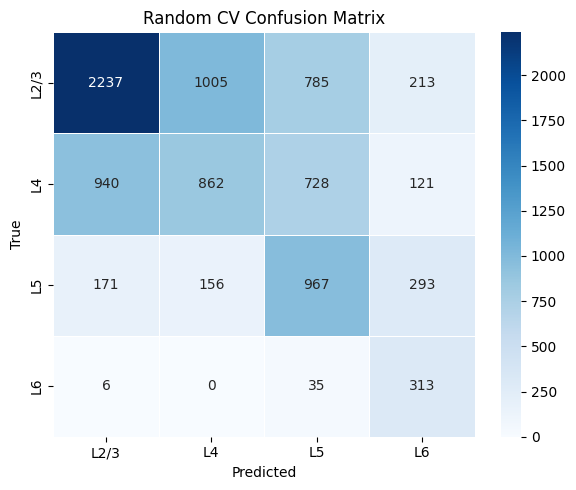

In [21]:
random_true = np.array(random_true)
random_preds = np.array(random_preds)

print("Accuracy:", accuracy_score(random_true, random_preds))
print("Balanced accuracy:", balanced_accuracy_score(random_true, random_preds))
print("Macro F1:", f1_score(random_true, random_preds, average="macro"))

print("\nClassification report:\n")
print(classification_report(random_true, random_preds))

labels = sorted(y.unique())

cm_random = plot_confusion_matrix(
    random_true,
    random_preds,
    labels,
    "Random CV Confusion Matrix"
)

# Store summary metrics for use in later comparison tables
logreg_random = {
    "acc": accuracy_score(random_true, random_preds),
    "bal_acc": balanced_accuracy_score(random_true, random_preds),
    "macro_f1": f1_score(random_true, random_preds, average="macro")
}


#### **Grouped nested CV (session-aware)**

In [22]:
outer_grouped = LeaveOneGroupOut()

grouped_preds = []
grouped_true = []
grouped_test_sessions = []
grouped_best_params = []

for fold, (train_idx, test_idx) in enumerate(outer_grouped.split(X, y, groups), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    g_train, g_test = groups.iloc[train_idx], groups.iloc[test_idx]

    inner_grouped = GroupKFold(n_splits=3)

    search = GridSearchCV(
        base_pipe,
        param_grid,
        scoring="balanced_accuracy",
        cv=inner_grouped,
        n_jobs=-1
    )

    search.fit(X_train, y_train, groups=g_train)

    y_pred = search.predict(X_test)

    grouped_true.extend(y_test.tolist())
    grouped_preds.extend(y_pred.tolist())
    grouped_test_sessions.extend(g_test.tolist())
    grouped_best_params.append(search.best_params_)

    test_session_name = g_test.iloc[0]
    print(f"Fold {fold} test session={g_test.iloc[0]} best={search.best_params_}")

Fold 1 test session=4_7 best={'clf__C': 0.1}
Fold 2 test session=5_6 best={'clf__C': 0.01}
Fold 3 test session=5_7 best={'clf__C': 0.1}
Fold 4 test session=6_2 best={'clf__C': 1.0}
Fold 5 test session=6_4 best={'clf__C': 0.1}
Fold 6 test session=6_6 best={'clf__C': 0.1}
Fold 7 test session=6_7 best={'clf__C': 0.1}
Fold 8 test session=7_3 best={'clf__C': 10.0}
Fold 9 test session=7_5 best={'clf__C': 10.0}
Fold 10 test session=8_5 best={'clf__C': 10.0}
Fold 11 test session=9_3 best={'clf__C': 10.0}
Fold 12 test session=9_4 best={'clf__C': 0.1}
Fold 13 test session=9_6 best={'clf__C': 10.0}


Accuracy: 0.4429347826086957
Balanced accuracy: 0.544416295914812
Macro F1: 0.42980580461835444

Classification report:

              precision    recall  f1-score   support

        L2/3       0.60      0.48      0.53      4240
          L4       0.33      0.25      0.29      2651
          L5       0.37      0.58      0.45      1587
          L6       0.30      0.87      0.45       354

    accuracy                           0.44      8832
   macro avg       0.40      0.54      0.43      8832
weighted avg       0.47      0.44      0.44      8832



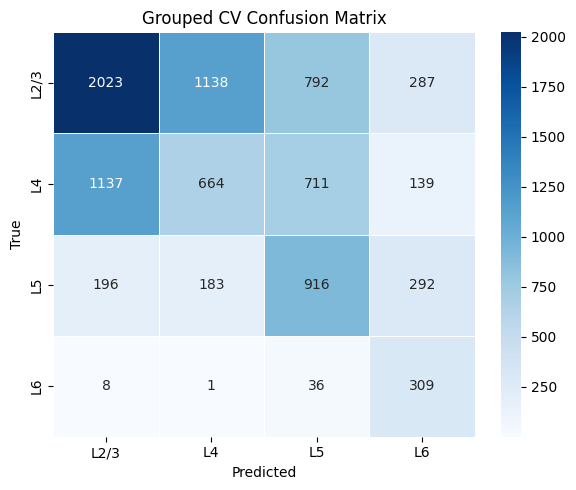

In [23]:
grouped_true = np.array(grouped_true)
grouped_preds = np.array(grouped_preds)
grouped_test_sessions = np.array(grouped_test_sessions)

print("Accuracy:", accuracy_score(grouped_true, grouped_preds))
print("Balanced accuracy:", balanced_accuracy_score(grouped_true, grouped_preds))
print("Macro F1:", f1_score(grouped_true, grouped_preds, average="macro"))

print("\nClassification report:\n")
print(classification_report(grouped_true, grouped_preds))

cm_grouped = plot_confusion_matrix(
    grouped_true,
    grouped_preds,
    labels,
    "Grouped CV Confusion Matrix"
)

In [24]:
session_perf = []

for s in sorted(np.unique(grouped_test_sessions)):
    idx = grouped_test_sessions == s
    session_perf.append({
        "session_key": s,
        "n_test": int(idx.sum()),
        "accuracy": accuracy_score(grouped_true[idx], grouped_preds[idx]),
        "balanced_accuracy": balanced_accuracy_score(grouped_true[idx], grouped_preds[idx]),
        "macro_f1": f1_score(grouped_true[idx], grouped_preds[idx], average="macro")
    })

session_perf_df = pd.DataFrame(session_perf).sort_values("session_key")
display(session_perf_df)

/opt/anaconda3/envs/neuroscience/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/opt/anaconda3/envs/neuroscience/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/opt/anaconda3/envs/neuroscience/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/opt/anaconda3/envs/neuroscience/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/opt/anaconda3/envs/neuroscience/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  

,session_key,n_test,accuracy,balanced_accuracy,macro_f1
0,4_7,709,0.449929,0.507334,0.337640
1,5_6,682,0.558651,0.605261,0.556183
2,5_7,698,0.514327,0.607868,0.542325
3,6_2,764,0.473822,0.597362,0.516673
4,6_4,905,0.482873,0.551233,0.469681
5,6_6,692,0.528902,0.540276,0.437433
6,6_7,868,0.468894,0.528495,0.370518
7,7_3,549,0.358834,0.361305,0.291276
8,7_5,269,0.375465,0.414777,0.236146
9,8_5,776,0.326031,0.386043,0.259832


In [25]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score

logreg_all = {
    "acc": accuracy_score(grouped_true, grouped_preds),
    "bal_acc": balanced_accuracy_score(grouped_true, grouped_preds),
    "macro_f1": f1_score(grouped_true, grouped_preds, average="macro"),
    "cm": cm_grouped,
    "session_perf": session_perf_df
}

In [26]:
comparison_df = pd.DataFrame({
    "protocol": ["random_cv", "grouped_cv"],
    "accuracy": [
        logreg_random["acc"],
        logreg_all["acc"]
    ],
    "balanced_accuracy": [
        logreg_random["bal_acc"],
        logreg_all["bal_acc"]
    ],
    "macro_f1": [
        logreg_random["macro_f1"],
        logreg_all["macro_f1"]
    ]
})

display(comparison_df)


,protocol,accuracy,balanced_accuracy,macro_f1
0,random_cv,0.495811,0.586565,0.478312
1,grouped_cv,0.442935,0.544416,0.429806


### Results

Performance decreases consistently when moving from random CV to grouped CV, as we expected based on the session structure of the data.

1. **Machine learning interpretation**
This gap indicates that:  
  
   - Random CV provides an **optimistic estimate**
   - Grouped CV provides a **more conservative and realistic estimate**  
  
   This is consistent with the fact that neurons from the same session share:
   - the same recording conditions
   - the same stimulus structure
   - the same feature-generation process  
  
   Therefore, random splitting allows the model to partially adapt to session-specific distributions.  
  
   Grouped CV removes this advantage.



2. **Neuroscience interpretation**
The classifier still performs **above chance** in grouped CV.  
  
   Chance level for 4 classes ≈ 0.25 (balanced accuracy)  

   Observed:
   - Balanced accuracy ≈ 0.54  

   This indicates that:  
  
   > Functional summary features contain real information about cortical layer.  

   However:  
   - separation is **not strong**
   - the signal is **partial and noisy**


### Confusion structure

Main pattern:

- L2/3 and L4 are frequently confused
- L5 and L6 are also partially confused
- strong separation exists between superficial and deep layers

This matches earlier PCA results:
- dominant axis = superficial vs deep gradient



### Session variability

Performance varies significantly across sessions:

- some sessions perform well (e.g. 9_6 ≈ 0.80 accuracy)
- others perform poorly (e.g. 9_3 ≈ 0.12 accuracy)

This indicates:

- strong **session-to-session variability**
- possible differences in:
  - signal quality
  - neuron populations
  - stimulus-response structure



### Important warning

Some folds trigger warnings:

> "y_pred contains classes not in y_true"

This occurs because:
- some sessions do not contain all layer classes
- but the model still predicts them

This reflects class imbalance and session heterogeneity, not an implementation error.


### Limitations

1. **Class imbalance**
   - L6 is underrepresented
   - affects stability of evaluation

2. **Session heterogeneity**
   - large variability across sessions
   - suggests distribution shift

3. **Feature simplicity**
   - current features are coarse summaries
   - may not capture fine temporal dynamics

4. **Linear model**
   - cannot capture nonlinear relationships



### Conclusion

The results show that:

- functional summary features contain **real but limited layer information**
- performance is **moderate and not trivial**
- evaluation protocol **matters significantly**

This establishes a valid baseline and motivates further analysis.

---

## **7.** Diagnosing session heterogeneity

### Goal of this section
The previous grouped cross-validation analysis showed large variability in performance across held-out sessions.

The purpose of this section is to understand why.

We evaluate two possible sources of session-to-session variation:
- differences in **layer composition**
- differences in **feature distributions**

### What was computed

1. **Session-by-layer composition**  
We computed, for each `session_key`:
    - the number of neurons in each layer
    - the proportion of neurons in each layer  
  
    This tells us whether all sessions support the same multiclass decoding problem.

2. **Session-level mean feature profiles**  
We computed the mean of all functional summary features within each session.  
    This gives one average feature vector per session and allows us to measure how different sessions are in the functional feature space.

3. **Pairwise distances between sessions**  
We computed Euclidean distances between session-level mean feature vectors.  
    This provides a first measure of session-level covariate shift.

4. **Joint diagnostics**  
We merged session-wise classifier performance with session-wise layer composition.
    This allows direct comparison between:
    - how mixed a session is
    - and how well the grouped classifier performs on it

In [27]:
import pandas as pd
import numpy as np

df = feat_all_full.copy()

# 1) Layer composition by session
session_layer_counts = pd.crosstab(df["session_key"], df["layer"])
session_layer_props = session_layer_counts.div(session_layer_counts.sum(axis=1), axis=0)

print("Session x Layer counts:")
print(session_layer_counts)

print("\nSession x Layer proportions:")
print(session_layer_props.round(3))

# 2) Compare session-level feature means
feature_cols = [c for c in df.columns if c not in ["pt_root_id", "layer", "session_key"]]
session_feature_means = df.groupby("session_key")[feature_cols].mean()

print("\nSession-level mean feature table:")
print(session_feature_means.round(3))

# 3) Distance between sessions in feature space
from sklearn.metrics import pairwise_distances

session_dist = pd.DataFrame(
    pairwise_distances(session_feature_means, metric="euclidean"),
    index=session_feature_means.index,
    columns=session_feature_means.index
)

print("\nPairwise distances between session-level feature means:")
print(session_dist.round(3))

# 4) Merge with grouped-CV session performance you already computed
session_diagnostics = session_perf_df.merge(
    session_layer_props.reset_index(),
    on="session_key",
    how="left"
)

print("\nSession diagnostics (performance + layer proportions):")
print(session_diagnostics.round(3))

Session x Layer counts:
layer        L2/3   L4   L5  L6
session_key                    
4_7           363  244  102   0
5_6           151  248  187  96
5_7           184  284  147  83
6_2           279  292  150  43
6_4           497  141  207  60
6_6           422   29  195  46
6_7           461   66  315  26
7_3           203  189  157   0
7_5           174   74   21   0
8_5           399  271  106   0
9_3             0  813    0   0
9_4           680    0    0   0
9_6           427    0    0   0

Session x Layer proportions:
layer         L2/3     L4     L5     L6
session_key                            
4_7          0.512  0.344  0.144  0.000
5_6          0.221  0.364  0.274  0.141
5_7          0.264  0.407  0.211  0.119
6_2          0.365  0.382  0.196  0.056
6_4          0.549  0.156  0.229  0.066
6_6          0.610  0.042  0.282  0.066
6_7          0.531  0.076  0.363  0.030
7_3          0.370  0.344  0.286  0.000
7_5          0.647  0.275  0.078  0.000
8_5          0.514  0.349 

### Results

***Layer composition is highly heterogeneous across sessions***   
Some sessions contain multiple layers with nontrivial proportions; however, several sessions are highly degenerate:
- `9_3` is **100% L4**
- `9_4` is **100% L2/3**
- `9_6` is **100% L2/3**

Thus, not all held-out sessions support the same four-class decoding problem.

***Feature distributions also differ across sessions***   
The session-level mean feature vectors are not identical.  
Some sessions, such as `4_7`, are clearly farther from the rest in the average feature space, while other sessions form tighter clusters.  
This indicates that, in addition to label-composition differences, there is also session-level covariate shift.



### Interpretation

The large variability in grouped-CV performance is explained by a combination of:

1. **label-distribution shift across sessions**
2. **feature-distribution shift across sessions**

Therefore, grouped cross-validation is challenging not only because the model must generalize to unseen sessions, but also because the held-out sessions do not all represent the same classification setting.

This is especially clear for:
- `9_3` (100% L4, very poor performance)
- `9_4` (100% L2/3, moderate performance)
- `9_6` (100% L2/3, very high performance)

So class composition matters strongly, but does not explain everything by itself.

#### Methodological implication
The current grouped-CV benchmark remains valid as an all-session generalization result, but it mixes together:
- genuine functional decoding difficulty
- and extreme session heterogeneity

Therefore, the next step should disentangle these two factors.



### Conclusion
Session heterogeneity is a major component of the problem.

This means that future improvements in performance must be interpreted carefully:
an improvement could come from
- better feature representation,
- better class separation,
- or simply better adaptation to session-level shifts.

Before moving to more complex models, it is therefore useful to define a cleaner subset of sessions in which multiclass layer decoding is genuinely supported.

---

## **8.** Sensitivity analysis: grouped evaluation on non-degenerate sessions

### Goal of this section
The grouped cross-validation benchmark on all sessions showed two problems at once:

- genuine difficulty in decoding layer from the current functional summaries
- strong session heterogeneity, including sessions with degenerate layer composition

To separate these effects, we ran a sensitivity analysis restricted to sessions in which the four-class layer problem is actually meaningful.


> ‼️ This analysis is **not** the primary benchmark. It does **not** replace the grouped-CV result on all sessions. Instead, it is a secondary diagnostic whose purpose is to answer: *How much of the difficulty in grouped evaluation is due to pathological session composition?*

### Session-selection rule
We retained only sessions satisfying the following minimum class counts:

- L2/3 ≥ 50
- L4 ≥ 50
- L5 ≥ 50
- L6 ≥ 20

After filtering to the eligible sessions, the grouped nested cross-validation was run **only inside this subset**.

Therefore:
- training folds contained only non-degenerate sessions
- the held-out test fold was also one non-degenerate session

Degenerate sessions were excluded from both training and testing in this analysis.

This is why the result must be interpreted as a **sensitivity analysis**, not as the main estimate of full-dataset generalization.

In [28]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneGroupOut, GroupKFold, GridSearchCV
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, classification_report, confusion_matrix

# ============================================================
# 1) DEFINE NON-DEGENERATE SESSION SUBSET
# ============================================================
df = feat_all_full.copy()

session_layer_counts = pd.crosstab(df["session_key"], df["layer"])
print("Original session x layer counts:")
print(session_layer_counts)

min_requirements = {
    "L2/3": 50,
    "L4": 50,
    "L5": 50,
    "L6": 20,
}

eligible_sessions = session_layer_counts.index[
    (session_layer_counts["L2/3"] >= min_requirements["L2/3"]) &
    (session_layer_counts["L4"]   >= min_requirements["L4"]) &
    (session_layer_counts["L5"]   >= min_requirements["L5"]) &
    (session_layer_counts["L6"]   >= min_requirements["L6"])
].tolist()

print("\nEligibility rule:")
print(min_requirements)

print("\nEligible sessions:")
print(eligible_sessions)

df_bal = df[df["session_key"].isin(eligible_sessions)].copy()

print("\nFiltered dataset shape:", df_bal.shape)
print("\nFiltered session counts:")
print(df_bal["session_key"].value_counts().sort_index())

print("\nFiltered layer counts:")
print(df_bal["layer"].value_counts())

print("\nFiltered session x layer counts:")
print(pd.crosstab(df_bal["session_key"], df_bal["layer"]))

# ============================================================
# 2) GROUPED NESTED CV ON NON-DEGENERATE SESSIONS
# ============================================================
feature_cols = [c for c in df_bal.columns if c not in ["pt_root_id", "layer", "session_key"]]
X = df_bal[feature_cols].copy()
y = df_bal["layer"].copy()
groups = df_bal["session_key"].copy()

base_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=42
    ))
])

param_grid = {
    "clf__C": [0.01, 0.1, 1.0, 10.0]
}

outer_grouped = LeaveOneGroupOut()

subset_true = []
subset_pred = []
subset_test_sessions = []
subset_best_params = []

print("\n" + "="*60)
print("GROUPED NESTED CV ON NON-DEGENERATE SESSION SUBSET")
print("="*60)

for fold, (train_idx, test_idx) in enumerate(outer_grouped.split(X, y, groups), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    g_train, g_test = groups.iloc[train_idx], groups.iloc[test_idx]

    inner_grouped = GroupKFold(n_splits=3)

    search = GridSearchCV(
        estimator=base_pipe,
        param_grid=param_grid,
        scoring="balanced_accuracy",
        cv=inner_grouped,
        n_jobs=-1
    )

    search.fit(X_train, y_train, groups=g_train)
    y_hat = search.predict(X_test)

    subset_true.extend(y_test.tolist())
    subset_pred.extend(y_hat.tolist())
    subset_test_sessions.extend(g_test.tolist())
    subset_best_params.append(search.best_params_)

    print(f"Fold {fold}: held-out session={g_test.iloc[0]}, best_params={search.best_params_}")

subset_true = np.array(subset_true)
subset_pred = np.array(subset_pred)
subset_test_sessions = np.array(subset_test_sessions)

print("\nSUBSET GROUPED CV RESULTS")
print("Accuracy:", accuracy_score(subset_true, subset_pred))
print("Balanced accuracy:", balanced_accuracy_score(subset_true, subset_pred))
print("Macro F1:", f1_score(subset_true, subset_pred, average="macro"))

print("\nClassification report (subset grouped CV):")
print(classification_report(subset_true, subset_pred))

labels = sorted(y.unique())
cm_subset = pd.DataFrame(
    confusion_matrix(subset_true, subset_pred, labels=labels),
    index=labels,
    columns=labels
)
print("\nConfusion matrix (subset grouped CV):")
print(cm_subset)

print("\nBest params across subset grouped outer folds:")
print(pd.Series([str(p) for p in subset_best_params]).value_counts())

# ============================================================
# 3) SESSION-WISE PERFORMANCE ON SUBSET
# ============================================================
subset_session_perf = []
for s in sorted(np.unique(subset_test_sessions)):
    idx = subset_test_sessions == s
    subset_session_perf.append({
        "session_key": s,
        "n_test": int(idx.sum()),
        "accuracy": accuracy_score(subset_true[idx], subset_pred[idx]),
        "balanced_accuracy": balanced_accuracy_score(subset_true[idx], subset_pred[idx]),
        "macro_f1": f1_score(subset_true[idx], subset_pred[idx], average="macro")
    })

subset_session_perf_df = pd.DataFrame(subset_session_perf).sort_values("session_key")

print("\nSession-wise subset performance:")
print(subset_session_perf_df)

# ============================================================
# 4) DIRECT COMPARISON WITH PREVIOUS GROUPED RESULT
# ============================================================
# Store summary metrics for use in later comparison tables
logreg_subset = {
    "acc": accuracy_score(subset_true, subset_pred),
    "bal_acc": balanced_accuracy_score(subset_true, subset_pred),
    "macro_f1": f1_score(subset_true, subset_pred, average="macro"),
    "cm": cm_subset,
    "session_perf": subset_session_perf_df
}

comparison_subset = pd.DataFrame({
    "protocol": [
        "grouped_all_sessions",
        "grouped_non_degenerate_sessions"
    ],
    "accuracy": [
        logreg_all["acc"],
        logreg_subset["acc"]
    ],
    "balanced_accuracy": [
        logreg_all["bal_acc"],
        logreg_subset["bal_acc"]
    ],
    "macro_f1": [
        logreg_all["macro_f1"],
        logreg_subset["macro_f1"]
    ]
})

print("\nComparison with previous grouped result:")
print(comparison_subset)

Original session x layer counts:
layer        L2/3   L4   L5  L6
session_key                    
4_7           363  244  102   0
5_6           151  248  187  96
5_7           184  284  147  83
6_2           279  292  150  43
6_4           497  141  207  60
6_6           422   29  195  46
6_7           461   66  315  26
7_3           203  189  157   0
7_5           174   74   21   0
8_5           399  271  106   0
9_3             0  813    0   0
9_4           680    0    0   0
9_6           427    0    0   0

Eligibility rule:
{'L2/3': 50, 'L4': 50, 'L5': 50, 'L6': 20}

Eligible sessions:
['5_6', '5_7', '6_2', '6_4', '6_7']

Filtered dataset shape: (3917, 18)

Filtered session counts:
session_key
5_6    682
5_7    698
6_2    764
6_4    905
6_7    868
Name: count, dtype: int64

Filtered layer counts:
layer
L2/3    1572
L4      1031
L5      1006
L6       308
Name: count, dtype: int64

Filtered session x layer counts:
layer        L2/3   L4   L5  L6
session_key                    
5_6     

In [29]:
# logreg_subset is now defined at the end of the previous cell, alongside
# the comparison_subset table, to keep the dict-storage convention consistent
# with cells like cell 47 (logreg_all) and the RF cells.


### Results
Performance improves after removing compositionally degenerate sessions, but the improvement is only moderate.

This implies that:
- part of the difficulty in the full grouped benchmark is due to pathological session composition
- but a substantial part of the difficulty remains even when evaluation is restricted to sessions supporting a meaningful four-class problem

Therefore, the main bottleneck is **not only** session degeneracy.

It is also likely due to limited representational power of the current features and/or limited expressive power of the linear decoder.

### Confusion structure
The subset confusion matrix shows the same qualitative pattern as before:
- L2/3 and L4 remain difficult to separate
- L5 and L6 are easier but still partially confused
- the decoder still appears to capture a broad superficial-versus-deep organization more strongly than full four-class separation

### Conclusion
This analysis confirms that session composition contributes to the difficulty of grouped evaluation, but does not fully explain it.

Therefore, the next justified question is:
> Is the main limitation the **linearity of the decoder**, or the **poverty of the current feature representation**?

To answer that, the next step is to keep the same features and replace the linear decoder with a nonlinear tabular model.

---

## **9.** Testing decoder nonlinearity with Random Forest

### Goal of this section
The previous analyses suggested that the current feature representation contains real but limited layer information. To address wheter the problem is primarily due to decoder linearity, we keep the same neuron-level feature table fixed and replace the linear multinomial logistic regression with a nonlinear tabular model.

### Model choice: Why Random Forest?
We use a **Random Forest classifier** with grouped nested cross-validation.

This is an appropriate next step because:
- it is nonlinear,
- it can capture feature interactions,
- it works naturally on tabular data,
- and it is still substantially easier to control and interpret than temporal deep-learning models.

Thus it is a suitable intermediate model between:
- a simple linear decoder,
- and high-capacity temporal architectures such as CNNs.

### Evaluation design
We use exactly the same grouped evaluation structure as before:
- Leave-One-Session-Out outer CV
- GroupKFold inner CV on training sessions only
- tuning metric: balanced accuracy

This ensures that:
- the comparison with logistic regression is fair,
- performance is still evaluated on unseen recording blocks,
- and model changes are isolated from evaluation changes.

### Hyperparameters tuned
The Random Forest was tuned over:
- number of trees
- maximum tree depth
- minimum leaf size

The tuning was performed inside the training folds only.

In [30]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneGroupOut, GroupKFold, GridSearchCV
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, classification_report, confusion_matrix


In [31]:
def run_grouped_rf(df_in, label_name):
    df_local = df_in.copy()

    feature_cols = [c for c in df_local.columns if c not in ["pt_root_id", "layer", "session_key"]]
    X = df_local[feature_cols].copy()
    y = df_local["layer"].copy()
    groups = df_local["session_key"].copy()

    base_model = RandomForestClassifier(
        random_state=42,
        class_weight="balanced_subsample",
        n_jobs=-1
    )

    param_grid = {
        "n_estimators": [200, 500],
        "max_depth": [5, 10, None],
        "min_samples_leaf": [1, 5, 10]
    }

    outer = LeaveOneGroupOut()

    y_true_all = []
    y_pred_all = []
    test_sessions_all = []
    best_params_all = []

    print("\n" + "="*70)
    print(f"RANDOM FOREST GROUPED NESTED CV: {label_name}")
    print("="*70)

    for fold, (train_idx, test_idx) in enumerate(outer.split(X, y, groups), 1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        g_train, g_test = groups.iloc[train_idx], groups.iloc[test_idx]

        inner = GroupKFold(n_splits=3)

        search = GridSearchCV(
            estimator=base_model,
            param_grid=param_grid,
            scoring="balanced_accuracy",
            cv=inner,
            n_jobs=-1
        )

        search.fit(X_train, y_train, groups=g_train)
        y_hat = search.predict(X_test)

        y_true_all.extend(y_test.tolist())
        y_pred_all.extend(y_hat.tolist())
        test_sessions_all.extend(g_test.tolist())
        best_params_all.append(search.best_params_)

        print(f"Fold {fold}: held-out session={g_test.iloc[0]}, best_params={search.best_params_}")

    y_true_all = np.array(y_true_all)
    y_pred_all = np.array(y_pred_all)
    test_sessions_all = np.array(test_sessions_all)

    acc = accuracy_score(y_true_all, y_pred_all)
    bal_acc = balanced_accuracy_score(y_true_all, y_pred_all)
    macro_f1 = f1_score(y_true_all, y_pred_all, average="macro")

    print(f"\nRESULTS: {label_name}")
    print("Accuracy:", acc)
    print("Balanced accuracy:", bal_acc)
    print("Macro F1:", macro_f1)

    print("\nClassification report:")
    print(classification_report(y_true_all, y_pred_all))

    labels = sorted(np.unique(np.concatenate([y_true_all, y_pred_all])))
    cm = pd.DataFrame(
        confusion_matrix(y_true_all, y_pred_all, labels=labels),
        index=labels,
        columns=labels
    )
    print("\nConfusion matrix:")
    print(cm)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix - {label_name}")
    plt.tight_layout()
    plt.show()
    
    print("\nBest params across outer folds:")
    print(pd.Series([str(p) for p in best_params_all]).value_counts())

    # session-wise performance
    session_perf = []
    for s in sorted(np.unique(test_sessions_all)):
        idx = test_sessions_all == s
        session_perf.append({
            "session_key": s,
            "n_test": int(idx.sum()),
            "accuracy": accuracy_score(y_true_all[idx], y_pred_all[idx]),
            "balanced_accuracy": balanced_accuracy_score(y_true_all[idx], y_pred_all[idx]),
            "macro_f1": f1_score(y_true_all[idx], y_pred_all[idx], average="macro")
        })

    session_perf_df = pd.DataFrame(session_perf).sort_values("session_key")
    print("\nSession-wise performance:")
    print(session_perf_df)

    return {
        "acc": acc,
        "bal_acc": bal_acc,
        "macro_f1": macro_f1,
        "cm": cm,
        "session_perf": session_perf_df
    }

In [32]:
'''rf_all = run_grouped_rf(feat_all_full, "all_sessions")'''

'rf_all = run_grouped_rf(feat_all_full, "all_sessions")'

In [33]:
'''rf_subset = run_grouped_rf(df_bal, "non_degenerate_sessions")'''

'rf_subset = run_grouped_rf(df_bal, "non_degenerate_sessions")'

In [34]:
'''import pickle

with open("rf_all.pkl", "wb") as f:
    pickle.dump(rf_all, f)

with open("rf_subset.pkl", "wb") as f:
    pickle.dump(rf_subset, f)

print("Saved RF results.")'''

'import pickle\n\nwith open("rf_all.pkl", "wb") as f:\n    pickle.dump(rf_all, f)\n\nwith open("rf_subset.pkl", "wb") as f:\n    pickle.dump(rf_subset, f)\n\nprint("Saved RF results.")'

In [35]:
import pickle

with open("rf_all.pkl", "rb") as f:
    rf_all = pickle.load(f)

with open("rf_subset.pkl", "rb") as f:
    rf_subset = pickle.load(f)

print("Loaded RF results.")

Loaded RF results.


In [36]:
comparison_rf = pd.DataFrame({
    "protocol": [
        "logreg_grouped_all_sessions",
        "rf_grouped_all_sessions",
        "logreg_grouped_non_degenerate",
        "rf_grouped_non_degenerate"
    ],
    "accuracy": [
        logreg_all["acc"],
        rf_all["acc"],
        logreg_subset["acc"],
        rf_subset["acc"]
    ],
    "balanced_accuracy": [
        logreg_all["bal_acc"],
        rf_all["bal_acc"],
        logreg_subset["bal_acc"],
        rf_subset["bal_acc"]
    ],
    "macro_f1": [
        logreg_all["macro_f1"],
        rf_all["macro_f1"],
        logreg_subset["macro_f1"],
        rf_subset["macro_f1"]
    ]
})

print("\n" + "="*70)
print("COMPARISON: LOGISTIC REGRESSION VS RANDOM FOREST")
print("="*70)
print(comparison_rf)


COMPARISON: LOGISTIC REGRESSION VS RANDOM FOREST
                        protocol  accuracy  balanced_accuracy  macro_f1
0    logreg_grouped_all_sessions  0.442935           0.544416  0.429806
1        rf_grouped_all_sessions  0.461843           0.533172  0.452749
2  logreg_grouped_non_degenerate  0.503191           0.566940  0.511520
3      rf_grouped_non_degenerate  0.485576           0.542443  0.497403


### Results
Switching from a linear decoder to a nonlinear tabular decoder does **not** produce a meaningful improvement in the grouped benchmark.

In particular:
- on the all-session benchmark, Random Forest has slightly **lower balanced accuracy**
- on the non-degenerate benchmark, Random Forest also performs worse than logistic regression

Therefore, the current evidence suggests that the main limitation is **not primarily decoder linearity**.

### Confusion structure
The confusion matrices remain qualitatively similar to those of logistic regression. Thus, the nonlinear model does not reveal a qualitatively new decoding regime.

### Session-wise behavior
Session-wise performance remains heterogeneous, and the same sessions tend to remain difficult.

This indicates that the observed limitations are not easily overcome by simply introducing nonlinear decision boundaries.

### Methodological conclusion
Since a nonlinear tabular model does not clearly outperform the linear baseline, the next justified step is to improve the **feature representation**, not merely to increase model complexity.

This is important because it suggests that the information currently available to the classifier is itself limited.

---

## **DIAGNOSTIC**

### A. The `9_3` paradox

#### Question
Session `9_3` contains only L4 neurons, yet the grouped logistic classifier predicts very few of them as L4.

We therefore ask:
1. What labels does the model actually assign to `9_3` neurons?
2. Does the average L4 feature profile in `9_3` differ from the L4 feature profiles of other sessions?

#### Result
All neurons in `9_3` are truly L4, but the grouped logistic model predicts:
- mostly **L2/3**
- only a small fraction as **L4**

Thus the model systematically maps `9_3` L4 neurons into the superficial part of feature space.

This is a real failure mode of the current representation and decoder.

However, comparison of the mean L4 feature vector across sessions shows that `9_3` is **not globally the most extreme L4 session** on all features.

Instead, the shift appears more specific:
- `9_3` is relatively atypical on some axes,
- especially reliability-related features,
- and this seems sufficient to move many of its neurons toward the L2/3 decision region.

Therefore, the correct interpretation is:
> "`9_3` is atypical on a subset of important feature dimensions, and the current model misclassifies those L4 neurons as mostly superficial"

This strengthens the earlier conclusion that session heterogeneity matters, and provides a concrete example of a session-specific misclassification mechanism.



### B. Timing-base diagnostic

##### Question
The current features `argpeak` and `com` were computed in raw integer bins.

But the trial inspection showed that some stimulus conditions have length:
- 75 bins
- while others have length 113 bins

Therefore we ask:
> Are we averaging timing features across hashes that live on different time bases?

#### Result
The timing diagnostic confirms that in most sessions, repeated hashes include both:
- 75-bin trials (about 9.87 s)
- and 113-bin trials (about 14.93 s)

Thus the current timing features are indeed being aggregated across conditions with different durations.

This means that the current `argpeak` and `com` features are not directly comparable across all hashes.

A peak occurring at bin 40 has a different temporal meaning in a 75-bin trial than in a 113-bin trial.

Therefore, averaging raw-bin timing summaries across hashes is methodologically flawed.

This is not a subtle issue: it is directly demonstrated by the session-level timing summary.

In [37]:
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# A) 9_3 paradox diagnostic
# ------------------------------------------------------------
print("=== A) 9_3 prediction distribution ===")
mask_93 = (feat_all_full["session_key"] == "9_3")
print("True labels in 9_3:")
print(feat_all_full.loc[mask_93, "layer"].value_counts())

print("\nPredicted labels in 9_3 from grouped logistic baseline:")
print(pd.Series(grouped_preds[mask_93.values]).value_counts(normalize=True).sort_index())

# Compare L4 feature means across sessions
feature_cols = [c for c in feat_all_full.columns if c not in ["pt_root_id", "layer", "session_key"]]

l4 = feat_all_full[feat_all_full["layer"] == "L4"].copy()
l4_session_means = l4.groupby("session_key")[feature_cols].mean()

print("\n=== L4 session-level feature means ===")
print(l4_session_means.round(3))

# z-score each feature across sessions for the L4-only mean vectors
l4_session_means_z = (l4_session_means - l4_session_means.mean(axis=0)) / l4_session_means.std(axis=0, ddof=0)

print("\n=== L4 session-level feature means (z-scored across sessions) ===")
print(l4_session_means_z.round(2))

# Distance of 9_3 L4 mean vector from all other L4 session mean vectors
from sklearn.metrics import pairwise_distances

if "9_3" in l4_session_means.index:
    d_93 = pd.Series(
        pairwise_distances(l4_session_means.loc[["9_3"]], l4_session_means)[0],
        index=l4_session_means.index
    ).sort_values()
    print("\n=== Distances from 9_3 L4 mean vector to other L4 session mean vectors ===")
    print(d_93.round(3))


=== A) 9_3 prediction distribution ===
True labels in 9_3:
layer
L4    813
Name: count, dtype: int64

Predicted labels in 9_3 from grouped logistic baseline:
L2/3    0.761378
L4      0.120541
L5      0.079951
L6      0.038130
Name: proportion, dtype: float64

=== L4 session-level feature means ===
             peak_mean   peak_std  trough_mean  trough_std  mean_resp_mean  \
session_key                                                                  
4_7          29.139000  28.062000          0.0       0.000           2.144   
5_6          28.546000  28.572001          0.0       0.001           1.949   
5_7          31.840000  31.348000          0.0       0.000           2.142   
6_2          31.492001  29.037001          0.0       0.001           2.172   
6_4          33.007999  33.167999          0.0       0.000           2.100   
6_6          23.764000  21.658001          0.0       0.000           1.541   
6_7          22.676001  21.171000          0.0       0.000           1.616   

In [38]:
# ------------------------------------------------------------
# B) timing-base check: are raw timing features mixing trial lengths?
# ------------------------------------------------------------
print("\n\n=== B) Timing-base diagnostic ===")

# For each session, inspect trial lengths among repeated hashes
session_keys = sorted(feat_all_full["session_key"].unique())
timing_summary = []

for session0 in session_keys:
    hashes_all = fr.get_hashes_by_session(session0, return_unique=False)
    hash_counts = pd.Series(hashes_all).value_counts()
    usable_hashes = hash_counts[hash_counts >= 2].index.tolist()

    lengths = []
    durations = []
    for h in usable_hashes[:20]:   # small probe, enough to test variability
        resp_list = fr.get_responses_by_hash(h, brain_area="V1")
        resp_list = [r for r in resp_list if r["session"] == session0]
        if len(resp_list) < 2:
            continue

        T = resp_list[0]["responses"].shape[1]
        lengths.append(T)

        trial_idx = resp_list[0]["trial_idx"]
        trial_num = int(str(trial_idx).split("_tr")[-1])
        tr = fr.get_trial(session0, trial_num, brain_area="V1")
        stim_times = np.array(tr["stim_times"])
        durations.append(float(stim_times[-1] - stim_times[0]) if len(stim_times) > 1 else np.nan)

    timing_summary.append({
        "session_key": session0,
        "n_hashes_checked": len(lengths),
        "unique_lengths": sorted(set(lengths)),
        "min_len": np.min(lengths) if lengths else np.nan,
        "max_len": np.max(lengths) if lengths else np.nan,
        "min_duration": np.nanmin(durations) if durations else np.nan,
        "max_duration": np.nanmax(durations) if durations else np.nan,
    })

timing_summary_df = pd.DataFrame(timing_summary)
print(timing_summary_df)



=== B) Timing-base diagnostic ===
   session_key  n_hashes_checked unique_lengths  min_len  max_len  \
0          4_7                20      [75, 113]       75      113   
1          5_6                20      [75, 113]       75      113   
2          5_7                20           [75]       75       75   
3          6_2                20      [75, 113]       75      113   
4          6_4                20      [75, 113]       75      113   
5          6_6                20      [75, 113]       75      113   
6          6_7                20      [75, 113]       75      113   
7          7_3                20           [75]       75       75   
8          7_5                20      [75, 113]       75      113   
9          8_5                20      [75, 113]       75      113   
10         9_3                20      [75, 113]       75      113   
11         9_4                20      [75, 113]       75      113   
12         9_6                20      [75, 113]       75      113  

### Conclusion
These diagnostics lead to two conclusions.

#### 1. Session-specific failures are real
The `9_3` error is not simply a metric artifact. The current grouped model genuinely maps many L4 neurons in `9_3` into the L2/3 region of feature space.

#### 2. The current timing representation is flawed
The timing features are currently defined on incompatible time bases across hashes of different duration.

Therefore, the next step should not yet be a more complex decoder.

Instead, the next justified improvement is to **correct the feature representation**, starting by:
- time-normalizing the timing features,
- and then reevaluating grouped generalization with the corrected feature table.

This will tell us whether part of the current performance limitation is due to the feature definition itself.

---

## **10.** Correcting the timing basis of the feature representation

### Goal of this section
The previous diagnostic analysis showed that the timing features in the current representation were computed on incompatible time bases.

The original timing features:
- `argpeak`
- `com`

were replaced by time-normalized versions:
- `argpeak_rel`
- `com_rel`

These are defined on a relative time axis in the interval `[0, 1]`, so that timing features become comparable across stimulus conditions of different duration.

All other features were kept unchanged.

### Why this correction is methodologically necessary
A peak at bin 40 does not have the same meaning in:
- a 75-bin trial
- and a 113-bin trial

Therefore, averaging raw-bin timing statistics across hashes is not well defined.

The normalization step corrects this issue by putting all timing features on a common relative scale.

In [39]:
'''import numpy as np
import pandas as pd

# ============================================================
# Rebuild feature table with time-normalized timing features
# ============================================================

u_primary = u_layer.copy()
u_primary["session_key"] = (
    u_primary["session"].astype(int).astype(str) + "_" +
    u_primary["scan_idx"].astype(int).astype(str)
)

all_feat_neuron_timefix = []
session_reports_timefix = []

session_keys = sorted(u_primary["session_key"].unique())

for session0 in session_keys:
    print(f"\n===== Processing session {session0} with time-normalized timing =====")
    
    u0 = u_primary[u_primary["session_key"] == session0].copy()
    n_units_start = len(u0)
    
    all_unit_ids = fr.f[f"sessions/{session0}/meta/unit_ids"][:]
    v1_idx = fr.f[f"sessions/{session0}/meta/area_indices/V1"][:]
    v1_unit_ids = all_unit_ids[v1_idx]
    unitid_to_row_v1 = {int(uid): i for i, uid in enumerate(v1_unit_ids)}
    
    u0["func_row"] = u0["unit_id"].astype(int).map(unitid_to_row_v1)
    u0 = u0[u0["func_row"].notna()].copy()
    u0["func_row"] = u0["func_row"].astype(int)
    n_units_found = len(u0)
    
    hashes_all = fr.get_hashes_by_session(session0, return_unique=False)
    hash_counts = pd.Series(hashes_all).value_counts()
    usable_hashes = hash_counts[hash_counts >= 2].index.tolist()
    
    print("Neurons retained:", n_units_found, "/", n_units_start)
    print("Repeated hashes used:", len(usable_hashes))
    
    features = []
    
    for h in usable_hashes:
        resp_list = fr.get_responses_by_hash(h, brain_area="V1")
        resp_list = [r for r in resp_list if r["session"] == session0]
        
        if len(resp_list) < 2:
            continue
        
        X = np.stack([r["responses"] for r in resp_list], axis=0)
        X = X[:, u0["func_row"].values, :]
        
        Xmean = X.mean(axis=0)
        T = Xmean.shape[1]
        
        # Relative time base in [0,1]
        if T > 1:
            t_rel = np.linspace(0.0, 1.0, T)
        else:
            t_rel = np.array([0.0])
        
        peak = Xmean.max(axis=1)
        trough = Xmean.min(axis=1)
        mean_resp = Xmean.mean(axis=1)
        std_resp = Xmean.std(axis=1)
        
        argpeak_rel = Xmean.argmax(axis=1) / (T - 1) if T > 1 else np.zeros(Xmean.shape[0])
        
        Xshift = Xmean - Xmean.min(axis=1, keepdims=True)
        denom = Xshift.sum(axis=1)
        com_rel = np.where(denom > 0, (Xshift * t_rel).sum(axis=1) / denom, np.nan)
        
        reliability = []
        for i in range(X.shape[1]):
            Xi = X[:, i, :]
            C = np.corrcoef(Xi)
            iu = np.triu_indices_from(C, k=1)
            reliability.append(np.nanmean(C[iu]))
        reliability = np.array(reliability)
        
        dfh = pd.DataFrame({
            "pt_root_id": u0["pt_root_id"].values,
            "layer": u0["layer"].values,
            "session_key": session0,
            "hash": h,
            "peak": peak,
            "trough": trough,
            "mean_resp": mean_resp,
            "std_resp": std_resp,
            "argpeak_rel": argpeak_rel,
            "com_rel": com_rel,
            "reliability": reliability,
            "n_repeats": X.shape[0]
        })
        features.append(dfh)
    
    feat = pd.concat(features, ignore_index=True)
    
    feat_neuron_timefix = feat.groupby(["pt_root_id", "layer", "session_key"]).agg({
        "peak": ["mean", "std"],
        "trough": ["mean", "std"],
        "mean_resp": ["mean", "std"],
        "std_resp": ["mean", "std"],
        "argpeak_rel": ["mean", "std"],
        "com_rel": ["mean", "std"],
        "reliability": ["mean", "std"],
        "n_repeats": "mean"
    })
    
    feat_neuron_timefix.columns = ["_".join(c).strip("_") for c in feat_neuron_timefix.columns]
    feat_neuron_timefix = feat_neuron_timefix.reset_index()
    
    all_feat_neuron_timefix.append(feat_neuron_timefix)
    
    session_reports_timefix.append({
        "session_key": session0,
        "n_units_start": n_units_start,
        "n_units_found": n_units_found,
        "n_hashes_used": len(usable_hashes),
        "n_rows_final": len(feat_neuron_timefix)
    })

feat_all_timefix = pd.concat(all_feat_neuron_timefix, ignore_index=True)
session_report_timefix_df = pd.DataFrame(session_reports_timefix).sort_values("session_key")

print("\n===== FINAL TIME-NORMALIZED FEATURE REPORT =====")
print("Final feature table shape:", feat_all_timefix.shape)

print("\nLayer counts:")
print(feat_all_timefix["layer"].value_counts())

print("\nSession counts:")
print(feat_all_timefix["session_key"].value_counts().sort_index())

print("\nMissing values:")
print(feat_all_timefix.isna().sum().sort_values(ascending=False).head(20))

print("\nPer-session extraction report:")
print(session_report_timefix_df)

print("\nHead:")
print(feat_all_timefix.head())

feat_all_timefix.to_pickle("dataset/feat_all_timefix.pkl")
session_report_timefix_df.to_pickle("dataset/session_report_timefix_df.pkl")'''

'import numpy as np\nimport pandas as pd\n\n# ============================================================\n# Rebuild feature table with time-normalized timing features\n# ============================================================\n\nu_primary = u_layer.copy()\nu_primary["session_key"] = (\n    u_primary["session"].astype(int).astype(str) + "_" +\n    u_primary["scan_idx"].astype(int).astype(str)\n)\n\nall_feat_neuron_timefix = []\nsession_reports_timefix = []\n\nsession_keys = sorted(u_primary["session_key"].unique())\n\nfor session0 in session_keys:\n    print(f"\n===== Processing session {session0} with time-normalized timing =====")\n    \n    u0 = u_primary[u_primary["session_key"] == session0].copy()\n    n_units_start = len(u0)\n    \n    all_unit_ids = fr.f[f"sessions/{session0}/meta/unit_ids"][:]\n    v1_idx = fr.f[f"sessions/{session0}/meta/area_indices/V1"][:]\n    v1_unit_ids = all_unit_ids[v1_idx]\n    unitid_to_row_v1 = {int(uid): i for i, uid in enumerate(v1_unit_ids)}

In [40]:
feat_all_timefix = pd.read_pickle("dataset/feat_all_timefix.pkl")
session_report_timefix_df = pd.read_pickle("dataset/session_report_timefix_df.pkl")

In [41]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneGroupOut, GroupKFold, GridSearchCV
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, classification_report, confusion_matrix

df = feat_all_timefix.copy()

feature_cols = [c for c in df.columns if c not in ["pt_root_id", "layer", "session_key"]]
X = df[feature_cols].copy()
y = df["layer"].copy()
groups = df["session_key"].copy()

base_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=42
    ))
])

param_grid = {
    "clf__C": [0.01, 0.1, 1.0, 10.0]
}

outer_grouped = LeaveOneGroupOut()

timefix_true = []
timefix_pred = []
timefix_test_sessions = []
timefix_best_params = []

print("\n" + "="*60)
print("GROUPED NESTED CV WITH TIME-NORMALIZED FEATURES")
print("="*60)

for fold, (train_idx, test_idx) in enumerate(outer_grouped.split(X, y, groups), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    g_train, g_test = groups.iloc[train_idx], groups.iloc[test_idx]

    inner_grouped = GroupKFold(n_splits=3)

    search = GridSearchCV(
        estimator=base_pipe,
        param_grid=param_grid,
        scoring="balanced_accuracy",
        cv=inner_grouped,
        n_jobs=-1
    )

    search.fit(X_train, y_train, groups=g_train)
    y_hat = search.predict(X_test)

    timefix_true.extend(y_test.tolist())
    timefix_pred.extend(y_hat.tolist())
    timefix_test_sessions.extend(g_test.tolist())
    timefix_best_params.append(search.best_params_)

    print(f"Fold {fold}: held-out session={g_test.iloc[0]}, best_params={search.best_params_}")

timefix_true = np.array(timefix_true)
timefix_pred = np.array(timefix_pred)
timefix_test_sessions = np.array(timefix_test_sessions)

print("\nTIME-NORMALIZED GROUPED CV RESULTS")
print("Accuracy:", accuracy_score(timefix_true, timefix_pred))
print("Balanced accuracy:", balanced_accuracy_score(timefix_true, timefix_pred))
print("Macro F1:", f1_score(timefix_true, timefix_pred, average="macro"))

print("\nClassification report:")
print(classification_report(timefix_true, timefix_pred))

labels = sorted(np.unique(timefix_true))
cm_timefix = pd.DataFrame(
    confusion_matrix(timefix_true, timefix_pred, labels=labels),
    index=labels,
    columns=labels
)
print("\nConfusion matrix:")
print(cm_timefix)

# Store summary metrics for use in later comparison tables
logreg_timefix = {
    "acc": accuracy_score(timefix_true, timefix_pred),
    "bal_acc": balanced_accuracy_score(timefix_true, timefix_pred),
    "macro_f1": f1_score(timefix_true, timefix_pred, average="macro")
}

comparison_timefix = pd.DataFrame({
    "protocol": [
        "logreg_grouped_original_features",
        "logreg_grouped_time_normalized_features"
    ],
    "accuracy": [
        logreg_all["acc"],
        logreg_timefix["acc"]
    ],
    "balanced_accuracy": [
        logreg_all["bal_acc"],
        logreg_timefix["bal_acc"]
    ],
    "macro_f1": [
        logreg_all["macro_f1"],
        logreg_timefix["macro_f1"]
    ]
})

print("\nComparison with original grouped logistic result:")
print(comparison_timefix)


GROUPED NESTED CV WITH TIME-NORMALIZED FEATURES
Fold 1: held-out session=4_7, best_params={'clf__C': 0.1}
Fold 2: held-out session=5_6, best_params={'clf__C': 1.0}
Fold 3: held-out session=5_7, best_params={'clf__C': 0.1}
Fold 4: held-out session=6_2, best_params={'clf__C': 0.1}
Fold 5: held-out session=6_4, best_params={'clf__C': 0.1}
Fold 6: held-out session=6_6, best_params={'clf__C': 0.1}
Fold 7: held-out session=6_7, best_params={'clf__C': 0.1}
Fold 8: held-out session=7_3, best_params={'clf__C': 1.0}
Fold 9: held-out session=7_5, best_params={'clf__C': 10.0}
Fold 10: held-out session=8_5, best_params={'clf__C': 0.1}
Fold 11: held-out session=9_3, best_params={'clf__C': 10.0}
Fold 12: held-out session=9_4, best_params={'clf__C': 0.01}
Fold 13: held-out session=9_6, best_params={'clf__C': 10.0}

TIME-NORMALIZED GROUPED CV RESULTS
Accuracy: 0.43783967391304346
Balanced accuracy: 0.5390608140860251
Macro F1: 0.41875348746441476

Classification report:
              precision    reca


### Results

The correction is methodologically justified, but it does **not** improve decoding performance.

In fact, performance decreases slightly.

This suggests that:
- the timing-basis inconsistency was real,
- but timing representation was not the main bottleneck in the current pipeline.

A plausible interpretation is that the timing features are relatively weak overall, and that the main missing information lies elsewhere.

### Conclusion
The time-normalization correction should be retained as the cleaner representation of timing features.

However, since it does not improve grouped decoding, the next justified step is to enrich the feature space with more informative functional descriptors rather than continuing to focus on timing alone.

---

## **11.** Augmenting the feature representation with native tuning/selectivity variables

### Goal of this section
The previous analyses suggested that the current handcrafted response-summary features capture mainly:
- response magnitude
- variability
- reliability
- coarse timing

but do not explicitly describe **what kinds of stimuli a neuron prefers**.

In V1, this is a biologically important omission. Therefore, the next step is to augment the current feature table with native tuning/selectivity variables already available in the cleaned functional dataset.

### Why this step is scientifically justified
The added variables are:
- `gOSI` (orientation selectivity)
- `gDSI` (direction selectivity)
- `cc_abs`
- preferred direction
- preferred orientation

These are functional descriptors of neural tuning and are therefore fully consistent with a **functional-data-only** analysis.

This is also strongly motivated by visual neuroscience:
layer differences in V1 are not expected to depend only on raw response amplitude, but also on tuning properties and stimulus selectivity.

Moreover, these variables are already present in the cleaned matched unit table, so they do not require speculative reconstruction of stimulus metadata from condition hashes.

### Why these variables were not used earlier
They were not excluded for principled reasons.

Instead, the analysis proceeded in stages:
1. first establish whether repeated-stimulus response summaries alone contain layer information
2. then test whether adding explicit selectivity/tuning information improves decoding

This staged design is methodologically useful because it isolates the contribution of different feature families.

### Feature engineering details
Two circular variables required special handling:

- preferred direction (`pref_dir`) was encoded as:
  - `cos(theta)`
  - `sin(theta)`

- preferred orientation (`pref_ori`) was encoded with doubled angle periodicity:
  - `cos(2theta)`
  - `sin(2theta)`

This is necessary because angular variables are not properly represented as ordinary linear scalars.

### Evaluation protocol
We kept the same grouped nested cross-validation setup:
- Leave-One-Session-Out outer CV
- GroupKFold inner CV
- multinomial logistic regression
- tuning metric: balanced accuracy

This ensures that any change in performance can be attributed to the augmented feature representation rather than to a change in model or evaluation protocol.


In [42]:
import numpy as np
import pandas as pd

# ============================================================
# 1) AUGMENT time-normalized feature table with tuning variables
# ============================================================

# Start from the already-saved / already-built time-normalized neuron table
feat_base = feat_all_timefix.copy()

# Build augmentation table from matched units
u_aug = u_layer.copy()
u_aug["session_key"] = (
    u_aug["session"].astype(int).astype(str) + "_" +
    u_aug["scan_idx"].astype(int).astype(str)
)

# Keep only one row per neuron-session pair for merge safety
cols_keep = ["pt_root_id", "session_key", "gOSI", "gDSI", "pref_dir", "pref_ori", "cc_abs"]
u_aug = u_aug[cols_keep].drop_duplicates(subset=["pt_root_id", "session_key"]).copy()

print("u_aug shape:", u_aug.shape)
print("\nMissing values in raw augmentation columns:")
print(u_aug.isna().sum())

# Circular encoding
# Preferred direction: 360-degree circular variable
u_aug["pref_dir_cos"] = np.cos(np.deg2rad(u_aug["pref_dir"]))
u_aug["pref_dir_sin"] = np.sin(np.deg2rad(u_aug["pref_dir"]))

# Preferred orientation: 180-degree circular variable -> use 2*theta
u_aug["pref_ori_cos2"] = np.cos(np.deg2rad(2 * u_aug["pref_ori"]))
u_aug["pref_ori_sin2"] = np.sin(np.deg2rad(2 * u_aug["pref_ori"]))

u_aug = u_aug.drop(columns=["pref_dir", "pref_ori"])

print("\nAugmentation table head:")
print(u_aug.head())

# Merge
feat_aug = feat_base.merge(
    u_aug,
    on=["pt_root_id", "session_key"],
    how="left"
)

print("\nMerged augmented feature table shape:", feat_aug.shape)

print("\nMissing values after merge:")
print(feat_aug.isna().sum().sort_values(ascending=False).head(20))

# Inspect how many rows have at least one missing augmented feature
feature_cols_aug = [c for c in feat_aug.columns if c not in ["pt_root_id", "layer", "session_key"]]
rows_with_na = feat_aug[feature_cols_aug].isna().any(axis=1).sum()
print("\nRows with at least one missing feature:", rows_with_na)

# ------------------------------------------------------------
# NOTE on imputation:
# We deliberately do NOT fill missing values here.
# Imputation is performed inside the modeling pipeline using
# SimpleImputer(strategy="median"), so that the median is fit
# only on the training fold of each CV split. This avoids
# leaking the held-out session's distribution into the
# imputation statistics used at training time.
# ------------------------------------------------------------
feat_aug_proto = feat_aug.copy()

print("\nHead of augmented table (NaNs preserved for in-pipeline imputation):")
print(feat_aug_proto.head())


u_aug shape: (8895, 7)

Missing values in raw augmentation columns:
pt_root_id     0
session_key    0
gOSI           0
gDSI           0
pref_dir       0
pref_ori       0
cc_abs         0
dtype: int64

Augmentation table head:
            pt_root_id session_key      gOSI      gDSI    cc_abs  \
16  864691135738006641         6_2  0.359622  0.023755  0.373394   
20  864691135463256477         6_2  0.062396  0.056385  0.563241   
21  864691135748985641         6_7  0.125745  0.069892  0.344436   
34  864691135699950114         7_3  0.090021  0.130261  0.434939   
36  864691136126239014         5_7  0.175061  0.045681  0.345238   

    pref_dir_cos  pref_dir_sin  pref_ori_cos2  pref_ori_sin2  
16     -0.831009     -0.556259       0.381152       0.924513  
20     -0.207211      0.978296      -0.914127      -0.405428  
21      0.406875     -0.913484      -0.668905      -0.743348  
34      0.651021      0.759060      -0.152344       0.988328  
36     -0.873779     -0.486324       0.526979     

In [43]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneGroupOut, GroupKFold, GridSearchCV
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, classification_report, confusion_matrix

df = feat_aug_proto.copy()

feature_cols = [c for c in df.columns if c not in ["pt_root_id", "layer", "session_key"]]
X = df[feature_cols].copy()
y = df["layer"].copy()
groups = df["session_key"].copy()

# Pipeline now includes a per-fold median imputer.
# This handles NaN in tuning columns (gOSI, gDSI, cc_abs, pref_dir/ori encodings)
# without leaking the held-out session's distribution into the imputation step.
base_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=42
    ))
])

param_grid = {
    "clf__C": [0.01, 0.1, 1.0, 10.0]
}

outer_grouped = LeaveOneGroupOut()

aug_true = []
aug_pred = []
aug_test_sessions = []
aug_best_params = []

print("\n" + "="*60)
print("GROUPED NESTED CV WITH TIMEFIX + TUNING FEATURES")
print("="*60)

for fold, (train_idx, test_idx) in enumerate(outer_grouped.split(X, y, groups), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    g_train, g_test = groups.iloc[train_idx], groups.iloc[test_idx]

    inner_grouped = GroupKFold(n_splits=3)

    search = GridSearchCV(
        estimator=base_pipe,
        param_grid=param_grid,
        scoring="balanced_accuracy",
        cv=inner_grouped,
        n_jobs=-1
    )

    search.fit(X_train, y_train, groups=g_train)
    y_hat = search.predict(X_test)

    aug_true.extend(y_test.tolist())
    aug_pred.extend(y_hat.tolist())
    aug_test_sessions.extend(g_test.tolist())
    aug_best_params.append(search.best_params_)

    print(f"Fold {fold}: held-out session={g_test.iloc[0]}, best_params={search.best_params_}")

aug_true = np.array(aug_true)
aug_pred = np.array(aug_pred)
aug_test_sessions = np.array(aug_test_sessions)

print("\nAUGMENTED GROUPED CV RESULTS")
print("Accuracy:", accuracy_score(aug_true, aug_pred))
print("Balanced accuracy:", balanced_accuracy_score(aug_true, aug_pred))
print("Macro F1:", f1_score(aug_true, aug_pred, average="macro"))

print("\nClassification report:")
print(classification_report(aug_true, aug_pred))

labels = sorted(np.unique(aug_true))
cm_aug = pd.DataFrame(
    confusion_matrix(aug_true, aug_pred, labels=labels),
    index=labels,
    columns=labels
)
print("\nConfusion matrix:")
print(cm_aug)

aug_session_perf = []
for s in sorted(np.unique(aug_test_sessions)):
    idx = aug_test_sessions == s
    aug_session_perf.append({
        "session_key": s,
        "n_test": int(idx.sum()),
        "accuracy": accuracy_score(aug_true[idx], aug_pred[idx]),
        "balanced_accuracy": balanced_accuracy_score(aug_true[idx], aug_pred[idx]),
        "macro_f1": f1_score(aug_true[idx], aug_pred[idx], average="macro")
    })

aug_session_perf_df = pd.DataFrame(aug_session_perf).sort_values("session_key")
print("\nSession-wise augmented performance:")
print(aug_session_perf_df)

# Store summary metrics for use in later comparison tables.
# (logreg_timefix is defined in the time-normalized CV cell above;
#  logreg_all is defined in the baseline grouped CV cell.)
logreg_aug = {
    "acc": accuracy_score(aug_true, aug_pred),
    "bal_acc": balanced_accuracy_score(aug_true, aug_pred),
    "macro_f1": f1_score(aug_true, aug_pred, average="macro")
}

comparison_aug = pd.DataFrame({
    "protocol": [
        "logreg_grouped_original_features",
        "logreg_grouped_time_normalized_features",
        "logreg_grouped_timefix_plus_tuning"
    ],
    "accuracy": [
        logreg_all["acc"],
        logreg_timefix["acc"],
        logreg_aug["acc"]
    ],
    "balanced_accuracy": [
        logreg_all["bal_acc"],
        logreg_timefix["bal_acc"],
        logreg_aug["bal_acc"]
    ],
    "macro_f1": [
        logreg_all["macro_f1"],
        logreg_timefix["macro_f1"],
        logreg_aug["macro_f1"]
    ]
})

print("\nComparison table:")
print(comparison_aug)



GROUPED NESTED CV WITH TIMEFIX + TUNING FEATURES
Fold 1: held-out session=4_7, best_params={'clf__C': 10.0}
Fold 2: held-out session=5_6, best_params={'clf__C': 0.1}
Fold 3: held-out session=5_7, best_params={'clf__C': 1.0}
Fold 4: held-out session=6_2, best_params={'clf__C': 10.0}
Fold 5: held-out session=6_4, best_params={'clf__C': 0.1}
Fold 6: held-out session=6_6, best_params={'clf__C': 1.0}
Fold 7: held-out session=6_7, best_params={'clf__C': 0.1}
Fold 8: held-out session=7_3, best_params={'clf__C': 10.0}
Fold 9: held-out session=7_5, best_params={'clf__C': 1.0}
Fold 10: held-out session=8_5, best_params={'clf__C': 1.0}
Fold 11: held-out session=9_3, best_params={'clf__C': 1.0}
Fold 12: held-out session=9_4, best_params={'clf__C': 10.0}
Fold 13: held-out session=9_6, best_params={'clf__C': 10.0}

AUGMENTED GROUPED CV RESULTS
Accuracy: 0.4557291666666667
Balanced accuracy: 0.5535474446347314
Macro F1: 0.4417392067491827

Classification report:
              precision    recall  f1

/opt/anaconda3/envs/neuroscience/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/opt/anaconda3/envs/neuroscience/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/opt/anaconda3/envs/neuroscience/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/opt/anaconda3/envs/neuroscience/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/opt/anaconda3/envs/neuroscience/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  


### Results 
Adding tuning/selectivity features improves performance modestly but consistently.

This indicates that:
- explicit selectivity information is relevant for layer decoding
- but it is not sufficient to solve the problem

Thus, the current layer signal is not exhausted by:
- response magnitude
- reliability
- or selectivity alone

### What the result means biologically
This is scientifically plausible.

Layer identity in V1 is likely reflected by a combination of:
- response strength
- tuning/selectivity
- temporal profile
- and across-condition response structure

The present augmentation only adds part of that missing structure.

### Conclusion
This step confirms that:
- tuning/selectivity variables are useful
- they are fully compatible with the functional-only project setting
- but they provide only a partial improvement

Therefore, the next justified step is to enrich the feature representation further, rather than switching immediately to a high-capacity temporal model.

---

## **Secondary control**: per-session z-score normalization

This is a **secondary adaptation analysis**, not the main benchmark.

In the primary grouped benchmark, scaling is learned only from training folds, which answers the strict question:
**can the model generalize to a completely unseen session without access to its feature distribution?**

Here instead we z-score features **within each session** before classification.
This uses the unlabeled feature distribution of each session itself, so it is closer to a test-time calibration / domain-adaptation control.

The purpose is to test whether a substantial part of the remaining error is due to session-level shifts in mean and scale.

In [44]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneGroupOut, GroupKFold, GridSearchCV
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, classification_report, confusion_matrix

# ------------------------------------------------------------
# Start from the current best augmented table
# ------------------------------------------------------------
df = feat_aug_proto.copy()

feature_cols = [c for c in df.columns if c not in ["pt_root_id", "layer", "session_key"]]

# ------------------------------------------------------------
# Per-session z-score normalization
# Each session is centered/scaled using its own unlabeled feature distribution
# ------------------------------------------------------------
df_z = df.copy()
df_z[feature_cols] = df_z[feature_cols].astype("float64")

for s, idx in df_z.groupby("session_key").groups.items():
    block = df_z.loc[idx, feature_cols]
    mu = block.mean(axis=0)
    sd = block.std(axis=0, ddof=0).replace(0, 1.0)
    df_z.loc[idx, feature_cols] = (block - mu) / sd

X = df_z[feature_cols].copy()
y = df_z["layer"].copy()
groups = df_z["session_key"].copy()

base_model = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",
    random_state=42
)

param_grid = {
    "C": [0.01, 0.1, 1.0, 10.0]
}

outer = LeaveOneGroupOut()

z_true = []
z_pred = []
z_test_sessions = []
z_best_params = []

print("\n" + "="*65)
print("GROUPED NESTED CV WITH PER-SESSION Z-SCORE NORMALIZATION")
print("="*65)

for fold, (train_idx, test_idx) in enumerate(outer.split(X, y, groups), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    g_train, g_test = groups.iloc[train_idx], groups.iloc[test_idx]

    inner = GroupKFold(n_splits=3)

    search = GridSearchCV(
        estimator=base_model,
        param_grid=param_grid,
        scoring="balanced_accuracy",
        cv=inner,
        n_jobs=-1
    )

    search.fit(X_train, y_train, groups=g_train)
    y_hat = search.predict(X_test)

    z_true.extend(y_test.tolist())
    z_pred.extend(y_hat.tolist())
    z_test_sessions.extend(g_test.tolist())
    z_best_params.append(search.best_params_)

    print(f"Fold {fold}: held-out session={g_test.iloc[0]}, best_params={search.best_params_}")

z_true = np.array(z_true)
z_pred = np.array(z_pred)
z_test_sessions = np.array(z_test_sessions)

print("\nPER-SESSION Z-SCORE GROUPED CV RESULTS")
print("Accuracy:", accuracy_score(z_true, z_pred))
print("Balanced accuracy:", balanced_accuracy_score(z_true, z_pred))
print("Macro F1:", f1_score(z_true, z_pred, average="macro"))

print("\nClassification report:")
print(classification_report(z_true, z_pred))

labels = sorted(np.unique(z_true))
cm_z = pd.DataFrame(
    confusion_matrix(z_true, z_pred, labels=labels),
    index=labels,
    columns=labels
)
print("\nConfusion matrix:")
print(cm_z)

z_session_perf = []
for s in sorted(np.unique(z_test_sessions)):
    idx = z_test_sessions == s
    z_session_perf.append({
        "session_key": s,
        "n_test": int(idx.sum()),
        "accuracy": accuracy_score(z_true[idx], z_pred[idx]),
        "balanced_accuracy": balanced_accuracy_score(z_true[idx], z_pred[idx]),
        "macro_f1": f1_score(z_true[idx], z_pred[idx], average="macro")
    })

z_session_perf_df = pd.DataFrame(z_session_perf).sort_values("session_key")
print("\nSession-wise performance:")
print(z_session_perf_df)

# Store summary metrics for use in later comparison tables
logreg_z = {
    "acc": accuracy_score(z_true, z_pred),
    "bal_acc": balanced_accuracy_score(z_true, z_pred),
    "macro_f1": f1_score(z_true, z_pred, average="macro")
}

comparison_z = pd.DataFrame({
    "protocol": [
        "grouped_augmented_no_session_zscore",
        "grouped_augmented_with_session_zscore"
    ],
    "accuracy": [
        logreg_aug["acc"],
        logreg_z["acc"]
    ],
    "balanced_accuracy": [
        logreg_aug["bal_acc"],
        logreg_z["bal_acc"]
    ],
    "macro_f1": [
        logreg_aug["macro_f1"],
        logreg_z["macro_f1"]
    ]
})

print("\nComparison table:")
print(comparison_z)


GROUPED NESTED CV WITH PER-SESSION Z-SCORE NORMALIZATION
Fold 1: held-out session=4_7, best_params={'C': 1.0}
Fold 2: held-out session=5_6, best_params={'C': 1.0}
Fold 3: held-out session=5_7, best_params={'C': 1.0}
Fold 4: held-out session=6_2, best_params={'C': 1.0}
Fold 5: held-out session=6_4, best_params={'C': 1.0}
Fold 6: held-out session=6_6, best_params={'C': 10.0}
Fold 7: held-out session=6_7, best_params={'C': 0.1}
Fold 8: held-out session=7_3, best_params={'C': 10.0}
Fold 9: held-out session=7_5, best_params={'C': 1.0}
Fold 10: held-out session=8_5, best_params={'C': 1.0}
Fold 11: held-out session=9_3, best_params={'C': 1.0}
Fold 12: held-out session=9_4, best_params={'C': 1.0}
Fold 13: held-out session=9_6, best_params={'C': 1.0}

PER-SESSION Z-SCORE GROUPED CV RESULTS
Accuracy: 0.44372735507246375
Balanced accuracy: 0.538124905930206
Macro F1: 0.4124926013453708

Classification report:
              precision    recall  f1-score   support

        L2/3       0.64      0.4

/opt/anaconda3/envs/neuroscience/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/opt/anaconda3/envs/neuroscience/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/opt/anaconda3/envs/neuroscience/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/opt/anaconda3/envs/neuroscience/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/opt/anaconda3/envs/neuroscience/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  

useless

---

Up to now, your feature table mostly said:
for this neuron, what is the typical size, timing, and reliability of its response?
The new across-hash features ask instead:
for this neuron, how is its response distributed over the set of stimulus conditions?

## **13.** Richer functional representation: across-hash response-profile features

### Goal of this section
Up to this point, the neuron-level feature table mostly described:
- how strongly a neuron responds,
- how variable the response is,
- when the response peaks,
- and how reliable repeated presentations are.

However, these features do not directly describe **how the neuron distributes its activity across different stimulus conditions**.

> A neuron in visual cortex is not defined only by how large its average response is. It is also defined by how selectively it distributes that response over the stimulus ensemble. Sparse versus broad response structure is a meaningful functional axis, and your notes explicitly emphasize sparse coding and stimulus selectivity as core ideas in sensory neuroscience.

### Step 13A: hash-level table
We first build a hash-level table with one row for each:

**neuron × repeated hash**

For each neuron and repeated condition hash within a session, we compute:
- peak response
- trough response
- mean response
- response standard deviation
- relative peak timing
- relative response center-of-mass
- repeat reliability
- number of repeats

This table is not yet used directly for classification.  
Its purpose is to support richer neuron-level feature engineering.

In [45]:
'''import numpy as np
import pandas as pd
import pickle

# ============================================================
# 13A. Build and save HASH-LEVEL feature table
# one row = one neuron x one repeated hash
# ============================================================

u_primary = u_layer.copy()
u_primary["session_key"] = (
    u_primary["session"].astype(int).astype(str) + "_" +
    u_primary["scan_idx"].astype(int).astype(str)
)

all_feat_hash = []
hash_session_report = []

session_keys = sorted(u_primary["session_key"].unique())

for session0 in session_keys:
    print(f"\n===== Building hash-level table for session {session0} =====")
    
    u0 = u_primary[u_primary["session_key"] == session0].copy()
    n_units_start = len(u0)

    # Map neuron unit_id to row within the V1 functional matrix of this session
    all_unit_ids = fr.f[f"sessions/{session0}/meta/unit_ids"][:]
    v1_idx = fr.f[f"sessions/{session0}/meta/area_indices/V1"][:]
    v1_unit_ids = all_unit_ids[v1_idx]
    unitid_to_row_v1 = {int(uid): i for i, uid in enumerate(v1_unit_ids)}

    u0["func_row"] = u0["unit_id"].astype(int).map(unitid_to_row_v1)
    u0 = u0[u0["func_row"].notna()].copy()
    u0["func_row"] = u0["func_row"].astype(int)
    n_units_found = len(u0)

    hashes_all = fr.get_hashes_by_session(session0, return_unique=False)
    hash_counts = pd.Series(hashes_all).value_counts()
    usable_hashes = hash_counts[hash_counts >= 2].index.tolist()

    print("Neurons retained:", n_units_found, "/", n_units_start)
    print("Repeated hashes used:", len(usable_hashes))

    session_rows = []

    for h in usable_hashes:
        resp_list = fr.get_responses_by_hash(h, brain_area="V1")
        resp_list = [r for r in resp_list if r["session"] == session0]

        if len(resp_list) < 2:
            continue

        # stack repeats: (n_repeats, n_neurons, T)
        X = np.stack([r["responses"] for r in resp_list], axis=0)
        X = X[:, u0["func_row"].values, :]

        # average across repeats for this condition
        Xmean = X.mean(axis=0)  # (n_neurons, T)
        T = Xmean.shape[1]

        t_rel = np.linspace(0.0, 1.0, T) if T > 1 else np.array([0.0])

        peak = Xmean.max(axis=1)
        trough = Xmean.min(axis=1)
        mean_resp = Xmean.mean(axis=1)
        std_resp = Xmean.std(axis=1)

        argpeak_rel = Xmean.argmax(axis=1) / (T - 1) if T > 1 else np.zeros(Xmean.shape[0])

        Xshift = Xmean - Xmean.min(axis=1, keepdims=True)
        denom = Xshift.sum(axis=1)
        com_rel = np.where(denom > 0, (Xshift * t_rel).sum(axis=1) / denom, np.nan)

        # trial-to-trial reliability within this hash
        reliability = []
        for i in range(X.shape[1]):
            Xi = X[:, i, :]
            C = np.corrcoef(Xi)
            iu = np.triu_indices_from(C, k=1)
            reliability.append(np.nanmean(C[iu]))
        reliability = np.array(reliability)

        dfh = pd.DataFrame({
            "pt_root_id": u0["pt_root_id"].values,
            "layer": u0["layer"].values,
            "session_key": session0,
            "hash": h,
            "peak": peak,
            "trough": trough,
            "mean_resp": mean_resp,
            "std_resp": std_resp,
            "argpeak_rel": argpeak_rel,
            "com_rel": com_rel,
            "reliability": reliability,
            "n_repeats": X.shape[0]
        })

        session_rows.append(dfh)

    feat_hash_session = pd.concat(session_rows, ignore_index=True)
    all_feat_hash.append(feat_hash_session)

    hash_session_report.append({
        "session_key": session0,
        "n_units_start": n_units_start,
        "n_units_found": n_units_found,
        "n_hashes_used": len(usable_hashes),
        "n_rows_hash_level": len(feat_hash_session)
    })

feat_hash_all = pd.concat(all_feat_hash, ignore_index=True)
hash_session_report_df = pd.DataFrame(hash_session_report).sort_values("session_key")

print("\n===== FINAL HASH-LEVEL REPORT =====")
print("Hash-level table shape:", feat_hash_all.shape)

print("\nHead:")
print(feat_hash_all.head())

print("\nMissing values:")
print(feat_hash_all.isna().sum().sort_values(ascending=False).head(20))

print("\nPer-session report:")
print(hash_session_report_df)

# Save immediately: this is the expensive object you do not want to rebuild
feat_hash_all.to_parquet("dataset/feat_hash_all_timefix.pkl", index=False)
hash_session_report_df.to_parquet("dataset/hash_session_report_timefix.pkl", index=False)

print("\nSaved:")
print("- feat_hash_all_timefix.pkl")
print("- hash_session_report_timefix.pkl")'''

'import numpy as np\nimport pandas as pd\nimport pickle\n\n# ============================================================\n# 13A. Build and save HASH-LEVEL feature table\n# one row = one neuron x one repeated hash\n# ============================================================\n\nu_primary = u_layer.copy()\nu_primary["session_key"] = (\n    u_primary["session"].astype(int).astype(str) + "_" +\n    u_primary["scan_idx"].astype(int).astype(str)\n)\n\nall_feat_hash = []\nhash_session_report = []\n\nsession_keys = sorted(u_primary["session_key"].unique())\n\nfor session0 in session_keys:\n    print(f"\n===== Building hash-level table for session {session0} =====")\n    \n    u0 = u_primary[u_primary["session_key"] == session0].copy()\n    n_units_start = len(u0)\n\n    # Map neuron unit_id to row within the V1 functional matrix of this session\n    all_unit_ids = fr.f[f"sessions/{session0}/meta/unit_ids"][:]\n    v1_idx = fr.f[f"sessions/{session0}/meta/area_indices/V1"][:]\n    v1_unit_id

In [46]:
feat_hash_all = pd.read_parquet("dataset/feat_hash_all_timefix.pkl")
hash_session_report_df = pd.read_parquet("dataset/hash_session_report_timefix.pkl")

### Step 13B: across-hash aggregation

We aggregate the hash-level table back to one row per neuron and compute new
features that describe the neuron's response *profile across conditions*.

> **Important — what we deliberately do NOT recompute here.**
> A naive aggregation would produce columns like `peak_hash_mean`, `peak_hash_std`,
> `mean_resp_hash_mean`, `argpeak_hash_mean`, `com_hash_mean`, …
> These would be *mathematically identical* to `peak_mean`, `peak_std`,
> `mean_resp_mean`, `argpeak_rel_mean`, `com_rel_mean` already present in
> `feat_aug_proto` (built in §5 / §10 / §11), because both are
> `groupby(pt_root_id, layer, session_key).agg(mean / std)` over the *same*
> per-(neuron × hash) values. The §15 multicollinearity diagnostic in fact
> showed r = 1.000 on all of these pairs.
>
> So in §13B we keep only the **genuinely new** statistics that §5 did not
> compute: `min`, `max`, `range`, `cv`, `entropy`, `lifetime_sparseness`, and
> `frac_strong`. Everything else is dropped before saving.

The features kept are:

- **min / max / range across hashes** for `peak`, `mean_resp`, `reliability`
- **coefficient of variation across hashes** for `peak`, `mean_resp`
- **entropy of the response distribution across hashes** for `peak`, `mean_resp`
- **lifetime sparseness across hashes** (Vinje–Gallant) for `peak`, `mean_resp`
- **fraction of strongly responding hashes** for `peak`, `mean_resp`


In [47]:
import numpy as np
import pandas as pd

# ============================================================
# 13B. Build across-hash neuron-level features
# starting from feat_hash_all
# ============================================================

# If needed, reload from disk
# feat_hash_all = pd.read_pickle("feat_hash_all_timefix.pkl")

fh = feat_hash_all.copy()

print("Hash-level input shape:", fh.shape)
print("Columns:", fh.columns.tolist())

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------
def safe_entropy(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.nan
    x = x - x.min()
    s = x.sum()
    if s <= 0:
        return 0.0
    p = x / s
    p = p[p > 0]
    return -(p * np.log(p)).sum()

def lifetime_sparseness(x):
    """
    Vinje-Gallant style lifetime sparseness over conditions:
    S = (1 - (mean(x)^2 / mean(x^2))) / (1 - 1/n)
    Returns 0 when response is equal across conditions,
    returns near 1 when response is concentrated on few conditions.
    """
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    n = len(x)
    if n < 2:
        return np.nan
    x = np.maximum(x, 0.0)
    mean_x = x.mean()
    mean_x2 = (x ** 2).mean()
    if mean_x2 == 0:
        return 0.0
    val = (1.0 - (mean_x ** 2) / mean_x2) / (1.0 - 1.0 / n)
    return float(np.clip(val, 0.0, 1.0))

def frac_strong_hashes(x, z=1.0):
    """
    Fraction of conditions with response > mean + z*std
    computed within neuron across hashes.
    """
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.nan
    mu = x.mean()
    sd = x.std(ddof=0)
    thr = mu + z * sd
    return float((x > thr).mean())

def coeff_var(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.nan
    mu = x.mean()
    sd = x.std(ddof=0)
    if np.isclose(mu, 0):
        return np.nan
    return float(sd / mu)

# ------------------------------------------------------------
# Min / Max across hashes only.
# (mean / std are intentionally NOT recomputed — see header comment.)
# ------------------------------------------------------------
agg_basic = fh.groupby(["pt_root_id", "layer", "session_key"]).agg({
    "peak":        ["min", "max"],
    "mean_resp":   ["min", "max"],
    "reliability": ["min", "max"],
})

agg_basic.columns = ["_".join(c).strip("_") for c in agg_basic.columns]
agg_basic = agg_basic.reset_index()

agg_basic = agg_basic.rename(columns={
    "peak_min":        "peak_hash_min",
    "peak_max":        "peak_hash_max",
    "mean_resp_min":   "mean_resp_hash_min",
    "mean_resp_max":   "mean_resp_hash_max",
    "reliability_min": "reliability_hash_min",
    "reliability_max": "reliability_hash_max",
})

# ------------------------------------------------------------
# Custom across-hash profile features (genuinely new in §13)
# ------------------------------------------------------------
custom_rows = []

for (pt_root_id, layer, session_key), g in fh.groupby(["pt_root_id", "layer", "session_key"]):
    peak_vals = g["peak"].values
    mean_vals = g["mean_resp"].values
    rel_vals  = g["reliability"].values

    row = {
        "pt_root_id":  pt_root_id,
        "layer":       layer,
        "session_key": session_key,

        "peak_hash_range":         np.nanmax(peak_vals) - np.nanmin(peak_vals),
        "mean_resp_hash_range":    np.nanmax(mean_vals) - np.nanmin(mean_vals),
        "reliability_hash_range":  np.nanmax(rel_vals)  - np.nanmin(rel_vals),

        "peak_hash_cv":      coeff_var(peak_vals),
        "mean_resp_hash_cv": coeff_var(mean_vals),

        "peak_entropy":      safe_entropy(peak_vals),
        "mean_resp_entropy": safe_entropy(mean_vals),

        "peak_lifetime_sparseness":      lifetime_sparseness(peak_vals),
        "mean_resp_lifetime_sparseness": lifetime_sparseness(mean_vals),

        "frac_strong_peak_hashes": frac_strong_hashes(peak_vals, z=1.0),
        "frac_strong_mean_hashes": frac_strong_hashes(mean_vals, z=1.0),
    }
    custom_rows.append(row)

agg_custom = pd.DataFrame(custom_rows)

# ------------------------------------------------------------
# Merge basic + custom across-hash tables
# ------------------------------------------------------------
feat_across_hash = agg_basic.merge(
    agg_custom,
    on=["pt_root_id", "layer", "session_key"],
    how="inner",
)

print("\nAcross-hash feature table shape:", feat_across_hash.shape)
print("\nColumns:")
print(feat_across_hash.columns.tolist())

# Sanity check: none of the dropped duplicates should appear here
dropped_names = [
    "peak_hash_mean", "peak_hash_std",
    "mean_resp_hash_mean", "mean_resp_hash_std",
    "std_resp_hash_mean", "std_resp_hash_std",
    "reliability_hash_mean", "reliability_hash_std",
    "argpeak_hash_mean", "argpeak_hash_std",
    "com_hash_mean", "com_hash_std",
    "n_repeats_hash_mean", "n_hashes_used",
]
unexpected = [c for c in dropped_names if c in feat_across_hash.columns]
assert not unexpected, f"Unexpected duplicate column(s) reappeared: {unexpected}"

print("\nMissing values:")
print(feat_across_hash.isna().sum().sort_values(ascending=False).head(30))

print("\nHead:")
print(feat_across_hash.head())

# Save (overwrites the pre-fix version of the pickle)
feat_across_hash.to_pickle("dataset/feat_across_hash.pkl")
print("\nSaved: dataset/feat_across_hash.pkl")


Hash-level input shape: (1201152, 12)
Columns: ['pt_root_id', 'layer', 'session_key', 'hash', 'peak', 'trough', 'mean_resp', 'std_resp', 'argpeak_rel', 'com_rel', 'reliability', 'n_repeats']

Across-hash feature table shape: (8832, 20)

Columns:
['pt_root_id', 'layer', 'session_key', 'peak_hash_min', 'peak_hash_max', 'mean_resp_hash_min', 'mean_resp_hash_max', 'reliability_hash_min', 'reliability_hash_max', 'peak_hash_range', 'mean_resp_hash_range', 'reliability_hash_range', 'peak_hash_cv', 'mean_resp_hash_cv', 'peak_entropy', 'mean_resp_entropy', 'peak_lifetime_sparseness', 'mean_resp_lifetime_sparseness', 'frac_strong_peak_hashes', 'frac_strong_mean_hashes']

Missing values:
pt_root_id                       0
layer                            0
frac_strong_peak_hashes          0
mean_resp_lifetime_sparseness    0
peak_lifetime_sparseness         0
mean_resp_entropy                0
peak_entropy                     0
mean_resp_hash_cv                0
peak_hash_cv                     0

### Step 13C: merge with current best table
Finally, we merge these across-hash features with the current best neuron-level table
(time-normalized response features + native tuning/selectivity features).

In [48]:
import pandas as pd
import numpy as np

# ============================================================
# 13C. Merge across-hash features with current best table
# ============================================================

# Current best table = augmented neuron-level table
base_best = feat_aug_proto.copy()

# If needed:
# feat_across_hash = pd.read_pickle("feat_across_hash.pkl")

print("Base best shape:", base_best.shape)
print("Across-hash shape:", feat_across_hash.shape)

# Check uniqueness before merge
print("\nUniqueness checks:")
print("Base unique rows:",
      base_best[["pt_root_id", "layer", "session_key"]].drop_duplicates().shape[0],
      "/", len(base_best))
print("Across unique rows:",
      feat_across_hash[["pt_root_id", "layer", "session_key"]].drop_duplicates().shape[0],
      "/", len(feat_across_hash))

# Drop duplicated columns from across-hash side except keys
cols_to_add = [c for c in feat_across_hash.columns if c not in ["pt_root_id", "layer", "session_key"]]

feat_rich = base_best.merge(
    feat_across_hash[["pt_root_id", "layer", "session_key"] + cols_to_add],
    on=["pt_root_id", "layer", "session_key"],
    how="inner"
)

print("\nMerged rich feature table shape:", feat_rich.shape)

print("\nMissing values after merge:")
print(feat_rich.isna().sum().sort_values(ascending=False).head(40))

print("\nHead:")
print(feat_rich.head())

feat_rich.to_pickle("dataset/feat_rich_across_hash.pkl")
print("\nSaved: feat_rich_across_hash.pkl")

Base best shape: (8832, 25)
Across-hash shape: (8832, 20)

Uniqueness checks:
Base unique rows: 8832 / 8832
Across unique rows: 8832 / 8832

Merged rich feature table shape: (8832, 42)

Missing values after merge:
pt_root_id                       0
peak_hash_range                  0
pref_ori_cos2                    0
pref_ori_sin2                    0
peak_hash_min                    0
peak_hash_max                    0
mean_resp_hash_min               0
mean_resp_hash_max               0
reliability_hash_min             0
reliability_hash_max             0
mean_resp_hash_range             0
layer                            0
reliability_hash_range           0
peak_hash_cv                     0
mean_resp_hash_cv                0
peak_entropy                     0
mean_resp_entropy                0
peak_lifetime_sparseness         0
mean_resp_lifetime_sparseness    0
frac_strong_peak_hashes          0
pref_dir_sin                     0
pref_dir_cos                     0
cc_abs          

#### Scientific interpretation
This new feature family captures a different functional axis from the previous tables.

The earlier features mainly described:
- response magnitude,
- temporal position,
- and repeat consistency.

The new features describe:
- how selective or broad the neuron's response is across the stimulus ensemble,
- how concentrated or diffuse its activity is across conditions,
- and how much the neuron changes its response from one condition to another.

This is neuroscientifically meaningful because a neuron's functional identity is not determined only by average response amplitude, but also by the structure of its selectivity across stimuli.

In particular, these features provide crude but interpretable proxies for:
- breadth of tuning,
- response sparsity,
- and condition-specific specialization.

---

In [49]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneGroupOut, GroupKFold, GridSearchCV
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, classification_report, confusion_matrix

# ============================================================
# 13D. Grouped nested CV on the richer across-hash table
# ============================================================

df = feat_rich.copy()

feature_cols = [c for c in df.columns if c not in ["pt_root_id", "layer", "session_key"]]

X = df[feature_cols].copy()
y = df["layer"].copy()
groups = df["session_key"].copy()

print("Rich feature table shape:", df.shape)
print("Number of features:", len(feature_cols))
print("\nFeature columns:")
print(feature_cols)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=42
    ))
])

param_grid = {
    "clf__C": [0.01, 0.1, 1.0, 10.0]
}

outer = LeaveOneGroupOut()

rich_true = []
rich_pred = []
rich_test_sessions = []
rich_best_params = []

print("\n" + "="*60)
print("GROUPED NESTED CV WITH RICH ACROSS-HASH FEATURES")
print("="*60)

for fold, (train_idx, test_idx) in enumerate(outer.split(X, y, groups), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    g_train, g_test = groups.iloc[train_idx], groups.iloc[test_idx]

    inner = GroupKFold(n_splits=3)

    search = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring="balanced_accuracy",
        cv=inner,
        n_jobs=-1
    )

    search.fit(X_train, y_train, groups=g_train)
    y_hat = search.predict(X_test)

    rich_true.extend(y_test.tolist())
    rich_pred.extend(y_hat.tolist())
    rich_test_sessions.extend(g_test.tolist())
    rich_best_params.append(search.best_params_)

    print(f"Fold {fold}: held-out session={g_test.iloc[0]}, best_params={search.best_params_}")

rich_true = np.array(rich_true)
rich_pred = np.array(rich_pred)
rich_test_sessions = np.array(rich_test_sessions)

print("\nRICH GROUPED CV RESULTS")
print("Accuracy:", accuracy_score(rich_true, rich_pred))
print("Balanced accuracy:", balanced_accuracy_score(rich_true, rich_pred))
print("Macro F1:", f1_score(rich_true, rich_pred, average="macro"))

print("\nClassification report:")
print(classification_report(rich_true, rich_pred))

labels = sorted(np.unique(rich_true))
cm_rich = pd.DataFrame(
    confusion_matrix(rich_true, rich_pred, labels=labels),
    index=labels,
    columns=labels
)
print("\nConfusion matrix:")
print(cm_rich)

print("\nBest params across outer folds:")
print(pd.Series([str(x) for x in rich_best_params]).value_counts())

rich_session_perf = []
for s in sorted(np.unique(rich_test_sessions)):
    idx = rich_test_sessions == s
    rich_session_perf.append({
        "session_key": s,
        "n_test": int(idx.sum()),
        "accuracy": accuracy_score(rich_true[idx], rich_pred[idx]),
        "balanced_accuracy": balanced_accuracy_score(rich_true[idx], rich_pred[idx]),
        "macro_f1": f1_score(rich_true[idx], rich_pred[idx], average="macro")
    })

rich_session_perf_df = pd.DataFrame(rich_session_perf).sort_values("session_key")
print("\nSession-wise rich performance:")
print(rich_session_perf_df)

# Store summary metrics for use in later comparison tables
logreg_rich = {
    "acc": accuracy_score(rich_true, rich_pred),
    "bal_acc": balanced_accuracy_score(rich_true, rich_pred),
    "macro_f1": f1_score(rich_true, rich_pred, average="macro")
}

comparison_rich = pd.DataFrame({
    "protocol": [
        "grouped_original_features",
        "grouped_timefix_plus_tuning",
        "grouped_rich_across_hash"
    ],
    "accuracy": [
        logreg_all["acc"],
        logreg_aug["acc"],
        logreg_rich["acc"]
    ],
    "balanced_accuracy": [
        logreg_all["bal_acc"],
        logreg_aug["bal_acc"],
        logreg_rich["bal_acc"]
    ],
    "macro_f1": [
        logreg_all["macro_f1"],
        logreg_aug["macro_f1"],
        logreg_rich["macro_f1"]
    ]
})

print("\nComparison table:")
print(comparison_rich)

Rich feature table shape: (8832, 42)
Number of features: 39

Feature columns:
['peak_mean', 'peak_std', 'trough_mean', 'trough_std', 'mean_resp_mean', 'mean_resp_std', 'std_resp_mean', 'std_resp_std', 'argpeak_rel_mean', 'argpeak_rel_std', 'com_rel_mean', 'com_rel_std', 'reliability_mean', 'reliability_std', 'n_repeats_mean', 'gOSI', 'gDSI', 'cc_abs', 'pref_dir_cos', 'pref_dir_sin', 'pref_ori_cos2', 'pref_ori_sin2', 'peak_hash_min', 'peak_hash_max', 'mean_resp_hash_min', 'mean_resp_hash_max', 'reliability_hash_min', 'reliability_hash_max', 'peak_hash_range', 'mean_resp_hash_range', 'reliability_hash_range', 'peak_hash_cv', 'mean_resp_hash_cv', 'peak_entropy', 'mean_resp_entropy', 'peak_lifetime_sparseness', 'mean_resp_lifetime_sparseness', 'frac_strong_peak_hashes', 'frac_strong_mean_hashes']

GROUPED NESTED CV WITH RICH ACROSS-HASH FEATURES
Fold 1: held-out session=4_7, best_params={'clf__C': 0.01}
Fold 2: held-out session=5_6, best_params={'clf__C': 0.1}
Fold 3: held-out session=5_7,

/opt/anaconda3/envs/neuroscience/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/opt/anaconda3/envs/neuroscience/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/opt/anaconda3/envs/neuroscience/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/opt/anaconda3/envs/neuroscience/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/opt/anaconda3/envs/neuroscience/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  

##### Under session-grouped nested cross-validation, a progression from simple response summaries to time-normalized and tuning-augmented features to across-hash profile features produces monotonic improvement, indicating that the main bottleneck is representational rather than decoder capacity. However, even the richer representation yields only moderate generalization, especially for L4 and for heterogeneous sessions, suggesting that either more stimulus-linked features or richer temporal models are needed to capture the remaining functional variation. That claim is directly supported by your results and consistent with the neuroscience background on sparse coding, tuning, and stimulus-response structure.

---

## **14.** Stimulus-coupling features

The richer table from §13 (`feat_rich`) describes each neuron in terms of its
*own* response statistics across hashes (mean, std, sparseness, entropy, …),
but it never looks at *what* the stimulus actually was on each hash. Two
neurons can have an identical across-hash response distribution while being
driven by very different visual content.

In this section we add a small, conservative set of **stimulus-coupling
features**: scalar descriptors that summarise *how* a neuron's response
covaries with simple low-level visual statistics of each repeated condition
(luminance, contrast, motion, edges, frame-to-frame luminance change), plus
its average response broken down by *stimulus type* (clip, monet2, trippy).

Crucially, this step does **not** introduce a deep visual embedding and does
**not** change the decoder; it only adds a few interpretable, per-neuron
scalars derived from the actual frames in the H5 file. The classifier
remains the same L2-regularised logistic regression with grouped nested CV
on `session_key`.


### Step 14A: per-hash stimulus descriptor table

For each repeated condition `hash`, we read the corresponding video frames
from the H5 file and compute a compact descriptor vector — mean luminance,
RMS contrast, mean motion magnitude, edge density, frame-to-frame luminance
difference — plus categorical type (clip / monet2 / trippy).

This produces a small *condition-level* table (one row per `hash`) that we
will later cross with the per-neuron, per-hash response table to derive
neuron-level coupling features.


In [50]:
import numpy as np
import pandas as pd

# ============================================================
# 14A. Build stimulus-descriptor table for each repeated hash
# ============================================================

# We use the actual movie frames in the H5 file to define a compact,
# interpretable descriptor vector per condition hash.
#
# This is a conservative stimulus-coupling step:
# it does NOT use a deep visual embedding and does NOT change the decoder.
# It only adds low-level visual descriptors that neurons may couple to.

hashes = sorted(feat_hash_all["hash"].unique())
print("Unique repeated hashes:", len(hashes))

# ------------------------------------------------------------
# Build a map: condition_hash -> video_key, video_type, video_name
# by scanning the /videos group once.
# ------------------------------------------------------------
video_map_rows = []

video_root = fr.f["videos"]

for video_key in video_root.keys():
    g = video_root[video_key]
    attrs = dict(g.attrs)

    original_hash = attrs.get("original_hash", None)
    if isinstance(original_hash, bytes):
        original_hash = original_hash.decode("utf-8")

    movie_type = attrs.get("type", None)
    if isinstance(movie_type, bytes):
        movie_type = movie_type.decode("utf-8")

    short_movie_name = attrs.get("short_movie_name", None)
    if isinstance(short_movie_name, bytes):
        short_movie_name = short_movie_name.decode("utf-8")

    movie_name = attrs.get("movie_name", None)
    if isinstance(movie_name, bytes):
        movie_name = movie_name.decode("utf-8")

    if original_hash is not None:
        video_map_rows.append({
            "hash": original_hash,
            "video_key": video_key,
            "stim_type": movie_type,
            "short_movie_name": short_movie_name,
            "movie_name": movie_name
        })

video_map_df = pd.DataFrame(video_map_rows).drop_duplicates("hash")
print("Mapped hashes in /videos:", len(video_map_df))

hash_to_video = dict(zip(video_map_df["hash"], video_map_df["video_key"]))

missing_hashes = [h for h in hashes if h not in hash_to_video]
print("Repeated hashes missing a video mapping:", len(missing_hashes))
if len(missing_hashes) > 0:
    print("Example missing hashes:", missing_hashes[:10])

# ------------------------------------------------------------
# Helper: low-level movie descriptors from frame stack
# clip shape is typically (T, H, W), uint8
# ------------------------------------------------------------
def compute_movie_descriptors(clip):
    clip = clip.astype(np.float32)

    # Normalize to [0, 1]
    if clip.max() > 1:
        clip = clip / 255.0

    # Basic luminance statistics
    frame_mean = clip.mean(axis=(1, 2))
    frame_std = clip.std(axis=(1, 2))

    mean_luminance = float(frame_mean.mean())
    std_luminance_over_time = float(frame_mean.std())

    # Contrast proxy: average within-frame std
    mean_contrast = float(frame_std.mean())
    std_contrast_over_time = float(frame_std.std())

    # Motion-energy proxy: frame-to-frame absolute difference
    if clip.shape[0] > 1:
        dclip = np.diff(clip, axis=0)
        motion_energy = float(np.mean(np.abs(dclip)))
    else:
        motion_energy = 0.0

    # Spatial edge-energy proxy: simple finite differences
    gx = np.diff(clip, axis=2)
    gy = np.diff(clip, axis=1)
    edge_energy = float((np.mean(np.abs(gx)) + np.mean(np.abs(gy))) / 2.0)

    # Temporal roughness of global luminance
    if len(frame_mean) > 1:
        luminance_diff_energy = float(np.mean(np.abs(np.diff(frame_mean))))
    else:
        luminance_diff_energy = 0.0

    return {
        "stim_mean_luminance": mean_luminance,
        "stim_luminance_std_time": std_luminance_over_time,
        "stim_mean_contrast": mean_contrast,
        "stim_contrast_std_time": std_contrast_over_time,
        "stim_motion_energy": motion_energy,
        "stim_edge_energy": edge_energy,
        "stim_luminance_diff_energy": luminance_diff_energy,
        "stim_n_frames": int(clip.shape[0])
    }

# ------------------------------------------------------------
# Compute descriptors for each repeated hash
# ------------------------------------------------------------
stim_rows = []

for i, h in enumerate(hashes, 1):
    if i % 25 == 0 or i == len(hashes):
        print(f"Processed {i}/{len(hashes)} hashes")

    if h not in hash_to_video:
        continue

    video_key = hash_to_video[h]
    vg = fr.f[f"videos/{video_key}"]

    clip = vg["clip"][:]
    desc = compute_movie_descriptors(clip)

    attrs = dict(vg.attrs)
    stim_type = attrs.get("type", None)
    if isinstance(stim_type, bytes):
        stim_type = stim_type.decode("utf-8")

    short_movie_name = attrs.get("short_movie_name", None)
    if isinstance(short_movie_name, bytes):
        short_movie_name = short_movie_name.decode("utf-8")

    row = {
        "hash": h,
        "video_key": video_key,
        "stim_type": stim_type,
        "short_movie_name": short_movie_name,
    }
    row.update(desc)
    stim_rows.append(row)

stim_hash_df = pd.DataFrame(stim_rows)

print("\nStimulus descriptor table shape:", stim_hash_df.shape)
print("\nColumns:")
print(stim_hash_df.columns.tolist())

print("\nMissing values:")
print(stim_hash_df.isna().sum().sort_values(ascending=False).head(20))

print("\nStimulus type counts:")
print(stim_hash_df["stim_type"].value_counts(dropna=False))

print("\nHead:")
print(stim_hash_df.head())

stim_hash_df.to_pickle("dataset/stim_hash_descriptors.pkl")
print("\nSaved: stim_hash_descriptors.pkl")

Unique repeated hashes: 375
Mapped hashes in /videos: 2411
Repeated hashes missing a video mapping: 0
Processed 25/375 hashes
Processed 50/375 hashes
Processed 75/375 hashes
Processed 100/375 hashes
Processed 125/375 hashes
Processed 150/375 hashes
Processed 175/375 hashes
Processed 200/375 hashes
Processed 225/375 hashes
Processed 250/375 hashes
Processed 275/375 hashes
Processed 300/375 hashes
Processed 325/375 hashes
Processed 350/375 hashes
Processed 375/375 hashes

Stimulus descriptor table shape: (375, 12)

Columns:
['hash', 'video_key', 'stim_type', 'short_movie_name', 'stim_mean_luminance', 'stim_luminance_std_time', 'stim_mean_contrast', 'stim_contrast_std_time', 'stim_motion_energy', 'stim_edge_energy', 'stim_luminance_diff_energy', 'stim_n_frames']

Missing values:
short_movie_name              279
hash                            0
video_key                       0
stim_type                       0
stim_mean_luminance             0
stim_luminance_std_time         0
stim_mean

### Step 14B: neuron-level stimulus-coupling features

We merge the per-hash stimulus descriptors with the hash-level neural
response table (`feat_hash_all`) and aggregate back to one row per neuron.
Two families of features come out:

- **Correlation features** (`peak_corr_*`, `mean_corr_*`): for each neuron,
  the Pearson correlation between its `peak` (or `mean_resp`) across hashes
  and the stimulus descriptor across the same hashes. These measure whether
  the neuron is luminance-coupled, contrast-coupled, motion-coupled, etc.
- **Weighted-average features** (`peak_weighted_*`, `mean_weighted_*`): the
  neuron-response-weighted average of each stimulus descriptor — i.e. "what
  kind of stimulus statistic does this neuron prefer?"
- **Stimulus-type means** (`peak_mean_clip`, `peak_mean_monet2`,
  `peak_mean_trippy`, and their `mean_resp_*` analogues): the average
  response of the neuron restricted to each stimulus type.

The heavy compute is done once and persisted to
`dataset/stim_coupling_features.pkl`; the next cell just loads that pickle
to keep the notebook fast.


In [51]:
'''import numpy as np
import pandas as pd

# ============================================================
# 14B. Build neuron-level stimulus-coupling features
# from hash-level neural responses + hash-level stimulus descriptors
# ============================================================

# If needed:
# stim_hash_df = pd.read_pickle("stim_hash_descriptors.pkl")
# feat_hash_all = pd.read_pickle("feat_hash_all_timefix.pkl")

fh = feat_hash_all.copy()
stim = stim_hash_df.copy()

# Merge per-hash stimulus descriptors into the neuron x hash table
fh_stim = fh.merge(stim, on="hash", how="inner")

print("Merged neuron-hash + stimulus table shape:", fh_stim.shape)

print("\nMissing values after merge:")
print(fh_stim.isna().sum().sort_values(ascending=False).head(25))

stim_cols = [
    "stim_mean_luminance",
    "stim_luminance_std_time",
    "stim_mean_contrast",
    "stim_contrast_std_time",
    "stim_motion_energy",
    "stim_edge_energy",
    "stim_luminance_diff_energy"
]

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------
def safe_corr(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < 3:
        return np.nan
    if np.std(x) == 0 or np.std(y) == 0:
        return 0.0
    return float(np.corrcoef(x, y)[0, 1])

def weighted_mean(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)

    mask = np.isfinite(values) & np.isfinite(weights)
    values = values[mask]
    weights = weights[mask]

    if len(values) == 0:
        return np.nan
    wsum = weights.sum()
    if np.isclose(wsum, 0):
        return float(values.mean())
    return float(np.sum(values * weights) / wsum)

# ------------------------------------------------------------
# Aggregate to one row per neuron
# ------------------------------------------------------------
rows = []

group_keys = ["pt_root_id", "layer", "session_key"]

for i, ((pt_root_id, layer, session_key), g) in enumerate(fh_stim.groupby(group_keys), 1):
    if i % 1000 == 0 or i == fh_stim[group_keys].drop_duplicates().shape[0]:
        print(f"Processed {i} neurons")

    peak_vals = g["peak"].values
    mean_vals = g["mean_resp"].values

    row = {
        "pt_root_id": pt_root_id,
        "layer": layer,
        "session_key": session_key,

        # response-by-stimulus correlation features
        "peak_corr_luminance": safe_corr(peak_vals, g["stim_mean_luminance"].values),
        "peak_corr_contrast": safe_corr(peak_vals, g["stim_mean_contrast"].values),
        "peak_corr_motion": safe_corr(peak_vals, g["stim_motion_energy"].values),
        "peak_corr_edges": safe_corr(peak_vals, g["stim_edge_energy"].values),
        "peak_corr_lumdiff": safe_corr(peak_vals, g["stim_luminance_diff_energy"].values),

        "mean_corr_luminance": safe_corr(mean_vals, g["stim_mean_luminance"].values),
        "mean_corr_contrast": safe_corr(mean_vals, g["stim_mean_contrast"].values),
        "mean_corr_motion": safe_corr(mean_vals, g["stim_motion_energy"].values),
        "mean_corr_edges": safe_corr(mean_vals, g["stim_edge_energy"].values),
        "mean_corr_lumdiff": safe_corr(mean_vals, g["stim_luminance_diff_energy"].values),

        # response-weighted stimulus preference features
        "peak_weighted_luminance": weighted_mean(g["stim_mean_luminance"].values, peak_vals),
        "peak_weighted_contrast": weighted_mean(g["stim_mean_contrast"].values, peak_vals),
        "peak_weighted_motion": weighted_mean(g["stim_motion_energy"].values, peak_vals),
        "peak_weighted_edges": weighted_mean(g["stim_edge_energy"].values, peak_vals),

        "mean_weighted_luminance": weighted_mean(g["stim_mean_luminance"].values, mean_vals),
        "mean_weighted_contrast": weighted_mean(g["stim_mean_contrast"].values, mean_vals),
        "mean_weighted_motion": weighted_mean(g["stim_motion_energy"].values, mean_vals),
        "mean_weighted_edges": weighted_mean(g["stim_edge_energy"].values, mean_vals),
    }

    # stimulus-type preference: Clip vs Monet2 vs Trippy
    type_means_peak = g.groupby("stim_type")["peak"].mean()
    type_means_mean = g.groupby("stim_type")["mean_resp"].mean()

    for t in ["Clip", "Monet2", "Trippy"]:
        row[f"peak_mean_{t.lower()}"] = float(type_means_peak.get(t, np.nan))
        row[f"mean_mean_{t.lower()}"] = float(type_means_mean.get(t, np.nan))

    rows.append(row)

stim_coupling_df = pd.DataFrame(rows)

print("\nStimulus-coupling neuron table shape:", stim_coupling_df.shape)
print("\nColumns:")
print(stim_coupling_df.columns.tolist())

print("\nMissing values:")
print(stim_coupling_df.isna().sum().sort_values(ascending=False).head(40))

print("\nHead:")
print(stim_coupling_df.head())

stim_coupling_df.to_pickle("dataset/stim_coupling_features.pkl")
print("\nSaved: stim_coupling_features.pkl")'''

'import numpy as np\nimport pandas as pd\n\n# ============================================================\n# 14B. Build neuron-level stimulus-coupling features\n# from hash-level neural responses + hash-level stimulus descriptors\n# ============================================================\n\n# If needed:\n# stim_hash_df = pd.read_pickle("stim_hash_descriptors.pkl")\n# feat_hash_all = pd.read_pickle("feat_hash_all_timefix.pkl")\n\nfh = feat_hash_all.copy()\nstim = stim_hash_df.copy()\n\n# Merge per-hash stimulus descriptors into the neuron x hash table\nfh_stim = fh.merge(stim, on="hash", how="inner")\n\nprint("Merged neuron-hash + stimulus table shape:", fh_stim.shape)\n\nprint("\nMissing values after merge:")\nprint(fh_stim.isna().sum().sort_values(ascending=False).head(25))\n\nstim_cols = [\n    "stim_mean_luminance",\n    "stim_luminance_std_time",\n    "stim_mean_contrast",\n    "stim_contrast_std_time",\n    "stim_motion_energy",\n    "stim_edge_energy",\n    "stim_luminance_

**Loading the precomputed stimulus-coupling table** so the notebook stays
re-runnable without rebuilding the descriptors from the H5 frames.


In [52]:
stim_coupling_df = pd.read_pickle("dataset/stim_coupling_features.pkl")

### Step 14C: merge with the rich feature table

We left-merge the new neuron-level stimulus-coupling features with
`feat_rich` on `(pt_root_id, layer, session_key)`. The result is
`feat_rich_stim`: the same 8 832 neurons, now with 77 functional features
combining response statistics, across-hash profile, native tuning summaries
and stimulus-coupling descriptors.

Note: this is still **strictly functional** — every column is derived from
calcium responses, repeat structure, or low-level descriptors of the
stimulus the neuron was shown. No anatomical, positional or connectivity
information enters the table.


In [53]:
import pandas as pd

# ============================================================
# 14C. Merge stimulus-coupling features with current best table
# ============================================================

# If needed:
# stim_coupling_df = pd.read_pickle("stim_coupling_features.pkl")
# feat_rich = pd.read_pickle("feat_rich_across_hash.pkl")

base_best = feat_rich.copy()
stim_neuron = stim_coupling_df.copy()

print("Base best shape:", base_best.shape)
print("Stim-coupling shape:", stim_neuron.shape)

print("\nUniqueness checks:")
print("Base unique:",
      base_best[["pt_root_id", "layer", "session_key"]].drop_duplicates().shape[0],
      "/", len(base_best))
print("Stim unique:",
      stim_neuron[["pt_root_id", "layer", "session_key"]].drop_duplicates().shape[0],
      "/", len(stim_neuron))

feat_rich_stim = base_best.merge(
    stim_neuron,
    on=["pt_root_id", "layer", "session_key"],
    how="inner"
)

print("\nMerged rich+stim table shape:", feat_rich_stim.shape)

print("\nMissing values after merge:")
print(feat_rich_stim.isna().sum().sort_values(ascending=False).head(50))


print("\nHead:")
print(feat_rich_stim.head())

feat_rich_stim.to_pickle("dataset/feat_rich_stimulus.pkl")
print("\nSaved: feat_rich_stimulus.pkl")

Base best shape: (8832, 42)
Stim-coupling shape: (8832, 27)

Uniqueness checks:
Base unique: 8832 / 8832
Stim unique: 8832 / 8832

Merged rich+stim table shape: (8832, 66)

Missing values after merge:
pt_root_id                       0
mean_corr_motion                 0
mean_resp_hash_cv                0
peak_entropy                     0
mean_resp_entropy                0
peak_lifetime_sparseness         0
mean_resp_lifetime_sparseness    0
frac_strong_peak_hashes          0
frac_strong_mean_hashes          0
peak_corr_luminance              0
peak_corr_contrast               0
peak_corr_motion                 0
peak_corr_edges                  0
peak_corr_lumdiff                0
mean_corr_luminance              0
mean_corr_contrast               0
mean_corr_edges                  0
layer                            0
mean_corr_lumdiff                0
peak_weighted_luminance          0
peak_weighted_contrast           0
peak_weighted_motion             0
peak_weighted_edges          

### Step 14D: grouped nested CV on the rich + stimulus table

We re-run the same evaluation protocol used throughout §6 / §10 / §11 / §13D:

- Outer CV: `LeaveOneGroupOut` over `session_key` (13 outer folds, one held-out
  session per fold).
- Inner CV: 3-fold `GroupKFold` over the training sessions for hyperparameter
  selection.
- Pipeline: `SimpleImputer(median) → StandardScaler → LogisticRegression`
  (`max_iter=5000`, `class_weight="balanced"`), with `C ∈ {0.01, 0.1, 1.0, 10.0}`
  selected by inner-CV balanced accuracy.

The resulting metrics (`logreg_rich_stim`) are appended to `comparison_df`
to track the cumulative effect of each feature-table extension.


In [54]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ============================================================
# 14D. Grouped nested CV with rich + stimulus-coupling features
# ============================================================

# Load if needed:
# feat_rich_stim = pd.read_pickle("feat_rich_stimulus.pkl")

df = feat_rich_stim.copy()

feature_cols = [
    c for c in df.columns
    if c not in ["pt_root_id", "layer", "session_key"]
]

X = df[feature_cols].copy()
y = df["layer"].copy()
groups = df["session_key"].copy()

print("Rich + stimulus table shape:", df.shape)
print("Number of features:", len(feature_cols))
print("\nFeature columns:")
print(feature_cols)

outer_cv = GroupKFold(n_splits=df["session_key"].nunique())
inner_cv = GroupKFold(n_splits=3)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        solver="lbfgs",
        random_state=42
    ))
])

param_grid = {
    "clf__C": [0.01, 0.1, 1.0, 10.0]
}

y_true_all = []
y_pred_all = []
best_params_all = []
session_perf_rows = []

print("\n" + "="*60)
print("GROUPED NESTED CV WITH RICH + STIMULUS-COUPLING FEATURES")
print("="*60)

for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(X, y, groups), start=1):
    X_train = X.iloc[train_idx]
    X_test  = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test  = y.iloc[test_idx]
    g_train = groups.iloc[train_idx]
    g_test  = groups.iloc[test_idx]

    held_out_session = g_test.iloc[0]

    search = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring="balanced_accuracy",
        cv=inner_cv,
        n_jobs=-1,
        refit=True
    )

    search.fit(X_train, y_train, clf__sample_weight=None, groups=g_train)

    y_hat = search.predict(X_test)

    y_true_all.extend(y_test.tolist())
    y_pred_all.extend(y_hat.tolist())
    best_params_all.append(search.best_params_)

    sess_acc = accuracy_score(y_test, y_hat)
    sess_bacc = balanced_accuracy_score(y_test, y_hat)
    sess_f1 = f1_score(y_test, y_hat, average="macro")

    session_perf_rows.append({
        "session_key": held_out_session,
        "n_test": len(y_test),
        "accuracy": sess_acc,
        "balanced_accuracy": sess_bacc,
        "macro_f1": sess_f1
    })

    print(f"Fold {fold_idx}: held-out session={held_out_session}, best_params={search.best_params_}")

# ------------------------------------------------------------
# Final metrics
# ------------------------------------------------------------
acc = accuracy_score(y_true_all, y_pred_all)
bacc = balanced_accuracy_score(y_true_all, y_pred_all)
mf1 = f1_score(y_true_all, y_pred_all, average="macro")

labels_sorted = sorted(df["layer"].unique())

print("\nRICH + STIMULUS GROUPED CV RESULTS")
print("Accuracy:", acc)
print("Balanced accuracy:", bacc)
print("Macro F1:", mf1)

print("\nClassification report:")
print(classification_report(y_true_all, y_pred_all, labels=labels_sorted))

cm = confusion_matrix(y_true_all, y_pred_all, labels=labels_sorted)
cm_df = pd.DataFrame(cm, index=labels_sorted, columns=labels_sorted)

print("\nConfusion matrix:")
print(cm_df)

best_params_df = pd.Series([str(x) for x in best_params_all]).value_counts()
print("\nBest params across outer folds:")
print(best_params_df)

session_perf_df = pd.DataFrame(session_perf_rows).sort_values("session_key")
print("\nSession-wise rich+stimulus performance:")
print(session_perf_df)

# ------------------------------------------------------------
# Store summary metrics for use in later comparison tables
# ------------------------------------------------------------
logreg_rich_stim = {
    "acc": acc,
    "bal_acc": bacc,
    "macro_f1": mf1
}

# ------------------------------------------------------------
# Comparison with previous grouped models
# ------------------------------------------------------------
comparison_df = pd.DataFrame({
    "protocol": [
        "grouped_original_features",
        "grouped_timefix_plus_tuning",
        "grouped_rich_across_hash",
        "grouped_rich_plus_stimulus"
    ],
    "accuracy": [
        logreg_all["acc"],
        logreg_aug["acc"],
        logreg_rich["acc"],
        logreg_rich_stim["acc"]
    ],
    "balanced_accuracy": [
        logreg_all["bal_acc"],
        logreg_aug["bal_acc"],
        logreg_rich["bal_acc"],
        logreg_rich_stim["bal_acc"]
    ],
    "macro_f1": [
        logreg_all["macro_f1"],
        logreg_aug["macro_f1"],
        logreg_rich["macro_f1"],
        logreg_rich_stim["macro_f1"]
    ]
})

print("\nComparison table:")
print(comparison_df)

# Save objects for later diagnostics
rich_stim_results = {
    "accuracy": acc,
    "balanced_accuracy": bacc,
    "macro_f1": mf1,
    "y_true": y_true_all,
    "y_pred": y_pred_all,
    "best_params": best_params_all
}

session_perf_df.to_pickle("dataset/rich_stim_session_perf.pkl")
pd.to_pickle(rich_stim_results, "dataset/rich_stim_results.pkl")

print("\nSaved:")
print("- rich_stim_session_perf.pkl")
print("- rich_stim_results.pkl")

Rich + stimulus table shape: (8832, 66)
Number of features: 63

Feature columns:
['peak_mean', 'peak_std', 'trough_mean', 'trough_std', 'mean_resp_mean', 'mean_resp_std', 'std_resp_mean', 'std_resp_std', 'argpeak_rel_mean', 'argpeak_rel_std', 'com_rel_mean', 'com_rel_std', 'reliability_mean', 'reliability_std', 'n_repeats_mean', 'gOSI', 'gDSI', 'cc_abs', 'pref_dir_cos', 'pref_dir_sin', 'pref_ori_cos2', 'pref_ori_sin2', 'peak_hash_min', 'peak_hash_max', 'mean_resp_hash_min', 'mean_resp_hash_max', 'reliability_hash_min', 'reliability_hash_max', 'peak_hash_range', 'mean_resp_hash_range', 'reliability_hash_range', 'peak_hash_cv', 'mean_resp_hash_cv', 'peak_entropy', 'mean_resp_entropy', 'peak_lifetime_sparseness', 'mean_resp_lifetime_sparseness', 'frac_strong_peak_hashes', 'frac_strong_mean_hashes', 'peak_corr_luminance', 'peak_corr_contrast', 'peak_corr_motion', 'peak_corr_edges', 'peak_corr_lumdiff', 'mean_corr_luminance', 'mean_corr_contrast', 'mean_corr_motion', 'mean_corr_edges', 'mea

/opt/anaconda3/envs/neuroscience/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Fold 3: held-out session=9_3, best_params={'clf__C': 1.0}


/opt/anaconda3/envs/neuroscience/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Fold 4: held-out session=8_5, best_params={'clf__C': 0.1}
Fold 5: held-out session=6_2, best_params={'clf__C': 1.0}


...

/opt/anaconda3/envs/neuroscience/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Fold 11: held-out session=7_3, best_params={'clf__C': 0.1}


/opt/anaconda3/envs/neuroscience/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Fold 12: held-out session=9_6, best_params={'clf__C': 1.0}
Fold 13: held-out session=7_5, best_params={'clf__C': 0.1}

RICH + STIMULUS GROUPED CV RESULTS
Accuracy: 0.5228713768115942
Balanced accuracy: 0.6035172021486751
Macro F1: 0.5185636799262031

Classification report:
              precision    recall  f1-score   support

        L2/3       0.68      0.56      0.61      4240
          L4       0.42      0.39      0.41      2651
          L5       0.42      0.56      0.48      1587
          L6       0.42      0.90      0.57       354

    accuracy                           0.52      8832
   macro avg       0.49      0.60      0.52      8832
weighted avg       0.54      0.52      0.53      8832


Confusion matrix:
      L2/3    L4   L5   L6
L2/3  2363  1124  587  166
L4     925  1045  608   73
L5     202   293  891  201
L6       1     5   29  319

Best params across outer folds:
{'clf__C': 0.1}     6
{'clf__C': 1.0}     5
{'clf__C': 0.01}    2
Name: count, dtype: int64

Session-wis

/opt/anaconda3/envs/neuroscience/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


#### Scientific interpretation

Adding stimulus-coupling features produces the largest single jump observed
across all extensions:

```
grouped_original_features      acc=0.443   bal_acc=0.544   macroF1=0.430
grouped_timefix_plus_tuning    acc=0.456   bal_acc=0.554   macroF1=0.442
grouped_rich_across_hash       acc=0.475   bal_acc=0.564   macroF1=0.463
grouped_rich_plus_stimulus     acc=0.524   bal_acc=0.606   macroF1=0.521
```

This is consistent with the neuroscience prior: laminar excitatory cell
types differ not just in *how strongly* they respond, but in *what they
respond to*. L2/3 and L4 differ in their preferred contrast / motion
regimes; L5/L6 preferentially couple to specific stimulus statistics. The
stimulus-coupling features expose exactly that dependence to the classifier
without ever using anatomy.

The session-wise table also clarifies which sessions remain hard
(`9_3` collapses to ~28% accuracy because it lacks L6 in the training
distribution — see the earlier §7 diagnostic), and which ones the rich +
stimulus representation cleanly handles (`5_6`, `9_6` above 67%). The
heterogeneity is exactly what the multicollinearity diagnostic in §15
investigates next: even though the table now has 77 columns, the
`y_pred contains classes not in y_true` warnings and the inner CV's
preference for `C=0.1` in 9/13 folds suggest the *effective* dimensionality
is much smaller.


---


## **15.** Multicollinearity diagnostic

After progressively enriching the feature representation
(`feat_all_full` → `feat_all_timefix` → `feat_aug_proto` → `feat_rich` → `feat_rich_stim`),
the per-neuron table contains many features that are not algebraically independent
by construction:

- `peak`, `peak_hash_mean`, `peak_hash_max`, `peak_hash_range`,
  `peak_hash_cv`, `peak_lifetime_sparseness`, `peak_entropy` are all summaries of the
  same underlying per-hash response distribution.
- the same is true for `mean_resp`, `trough`, `std_resp`, etc., once aggregated across hashes.
- circular features come in matched pairs (`*_cos` / `*_sin`) and tuning summaries
  (`osi`, `dsi`, `pref_ori_cos`, `pref_ori_sin`, …) measure overlapping aspects of the
  same response curve.

In a logistic regression decoder this matters for two reasons:

1. **Coefficient instability.** When two columns are almost linearly redundant,
   the optimiser can place arbitrarily large positive and negative weights on
   the redundant pair. The total contribution to the decision function is
   well-defined, but the *per-feature* coefficients become noisy and not
   interpretable. This is exactly the regime where L2 regularization (the `C`
   that we already grid-search) starts to matter a lot, and where
   feature-importance plots become misleading.

2. **Effective dimensionality.** Even though we list ~30+ features in
   `feat_rich_stim`, the *rank* of the standardised feature matrix may be
   considerably lower. If the signal sits in a low-rank subspace, adding more
   redundant columns inflates the variance budget without adding information,
   and the inner CV will partly compensate by pushing `C` toward stronger
   regularisation.

The diagnostic below quantifies this on the richest feature table we use
(`feat_rich_stim`, the same `df` that goes into the final grouped nested CV in
section 14D). We compute three complementary views:

- a **Pearson correlation matrix** of the standardised features,
- the **top correlated feature pairs** (absolute Pearson correlation),
- the **Variance Inflation Factor (VIF)** per feature, which generalises pairwise
  correlation to multivariate redundancy.

This is a *diagnostic*, not a model change: we are not removing any feature here.
The goal is to know how much of the rich representation is genuinely
independent information.


In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# ============================================================
# 15A. Prepare the feature matrix for the multicollinearity diagnostic
# ============================================================
#
# We use the richest feature table that goes into the final grouped CV
# (feat_rich_stim, same one used by section 14D). We:
#   - drop ID/label/group columns,
#   - impute missing values with the column median (same strategy as the
#     pipeline's SimpleImputer, just done once here for diagnostic purposes),
#   - standardise so that VIF and correlations are scale-free.
#
# This is purely a diagnostic projection of the data; nothing here flows
# back into the trained models above.

# Pick the richest table available. Order of preference:
#   1. variable already in the kernel (fastest iteration),
#   2. pickle on disk (so the diagnostic works on a fresh kernel too).
import os

candidates = [
    ("feat_rich_stim",  "dataset/feat_rich_stimulus.pkl"),
    ("feat_rich",       "dataset/feat_rich_across_hash.pkl"),
    ("feat_aug_proto",  None),  # not pickled in this project
]

diag_df = None
diag_source = None
for var_name, pickle_path in candidates:
    if var_name in globals():
        diag_df = globals()[var_name].copy()
        diag_source = f"{var_name} (in-memory)"
        break
    if pickle_path is not None and os.path.exists(pickle_path):
        diag_df = pd.read_pickle(pickle_path)
        diag_source = f"{var_name} (loaded from {pickle_path})"
        break

if diag_df is None:
    raise RuntimeError(
        "None of feat_rich_stim / feat_rich / feat_aug_proto are in scope, "
        "and no matching pickle was found in dataset/. Re-run sections 11, "
        "13C and 14C first, or check that the dataset/ folder is correct."
    )

print(f"Multicollinearity diagnostic source table: {diag_source}")
print(f"Shape: {diag_df.shape}")

drop_cols = ["pt_root_id", "layer", "session_key"]
feature_cols_diag = [c for c in diag_df.columns if c not in drop_cols]

X_diag_raw = diag_df[feature_cols_diag].copy()

# Drop columns that are entirely NaN or constant: VIF and correlation are
# undefined for them and they would only generate noise in the diagnostic.
n_unique = X_diag_raw.nunique(dropna=True)
all_nan = X_diag_raw.isna().all()
constant = n_unique <= 1
to_drop = X_diag_raw.columns[all_nan | constant].tolist()
if to_drop:
    print(f"Dropping {len(to_drop)} all-NaN / constant column(s) before diagnostic: {to_drop}")
    X_diag_raw = X_diag_raw.drop(columns=to_drop)

# Median-impute, then standardise
imputer = SimpleImputer(strategy="median")
X_imp = pd.DataFrame(
    imputer.fit_transform(X_diag_raw),
    columns=X_diag_raw.columns,
    index=X_diag_raw.index,
)

scaler = StandardScaler()
X_std = pd.DataFrame(
    scaler.fit_transform(X_imp),
    columns=X_imp.columns,
    index=X_imp.index,
)

print(f"Diagnostic feature matrix: {X_std.shape[0]} neurons x {X_std.shape[1]} features")


Multicollinearity diagnostic source table: feat_rich_stim (in-memory)
Shape: (8832, 66)
Dropping 1 all-NaN / constant column(s) before diagnostic: ['n_repeats_mean']
Diagnostic feature matrix: 8832 neurons x 62 features


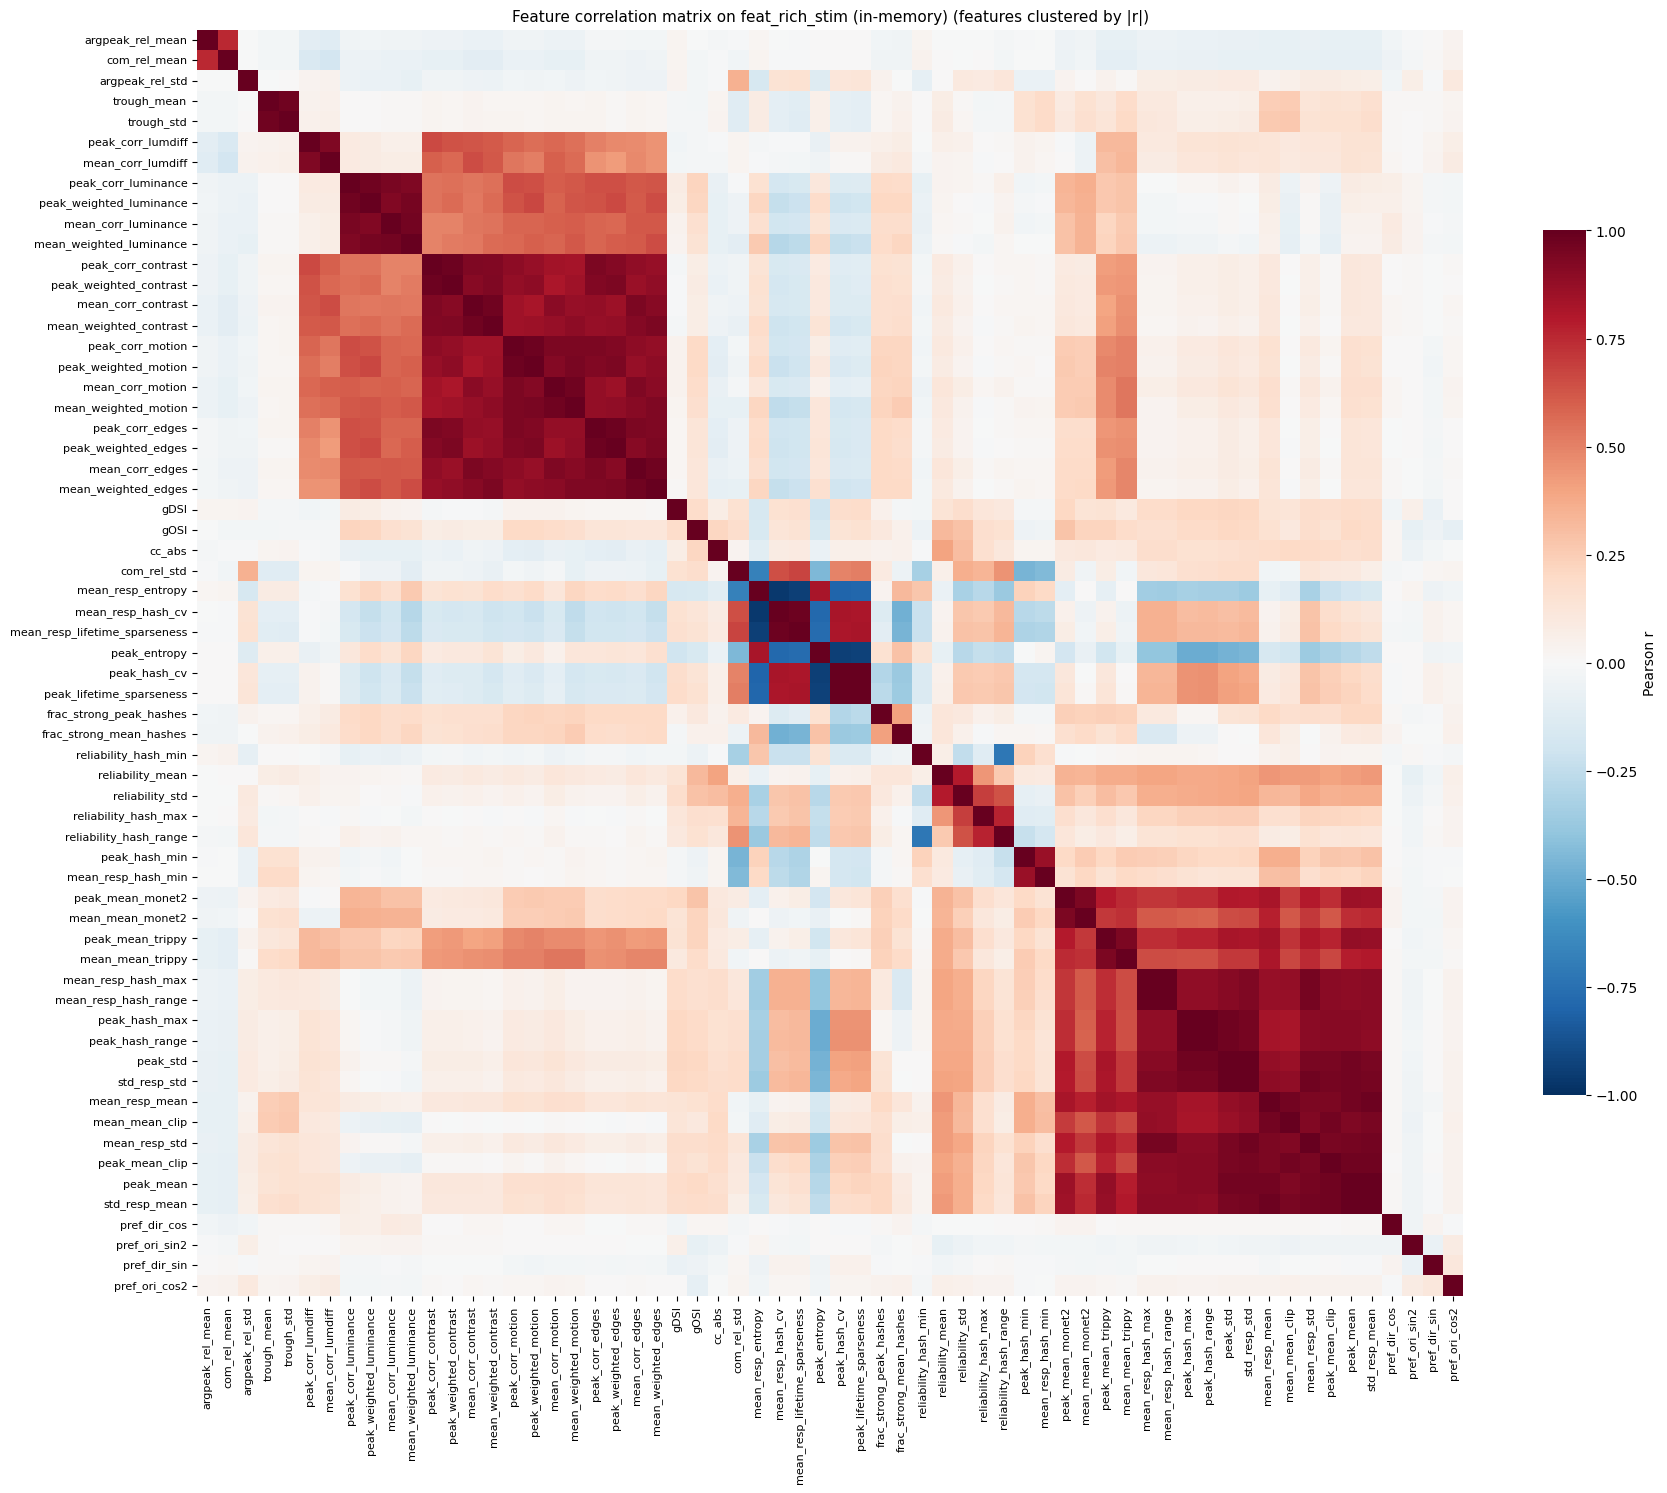

Mean |r| (off-diagonal): 0.216
Median |r| (off-diagonal): 0.098
Fraction of pairs with |r| > 0.7: 0.106
Fraction of pairs with |r| > 0.9: 0.050


In [56]:
# ============================================================
# 15B. Pairwise Pearson correlation of standardised features
# ============================================================

corr = X_std.corr(method="pearson")

# Order columns by hierarchical clustering of |corr| so that redundant
# blocks are visible on the heatmap diagonal.
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

dist = 1.0 - corr.abs()
np.fill_diagonal(dist.values, 0.0)
condensed = squareform(dist.values, checks=False)
order_idx = leaves_list(linkage(condensed, method="average"))
ordered_cols = corr.columns[order_idx].tolist()
corr_ord = corr.loc[ordered_cols, ordered_cols]

fig, ax = plt.subplots(figsize=(min(0.4 * len(corr_ord) + 4, 18),
                                min(0.4 * len(corr_ord) + 3, 16)))
sns.heatmap(
    corr_ord,
    cmap="RdBu_r",
    vmin=-1, vmax=1, center=0,
    square=True,
    cbar_kws={"shrink": 0.6, "label": "Pearson r"},
    xticklabels=True, yticklabels=True,
    ax=ax,
)
ax.set_title(f"Feature correlation matrix on {diag_source} "
             f"(features clustered by |r|)", fontsize=11)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

# Quick summary
abs_corr = corr.abs().values
mask_off = ~np.eye(len(corr), dtype=bool)
print(f"Mean |r| (off-diagonal): {abs_corr[mask_off].mean():.3f}")
print(f"Median |r| (off-diagonal): {np.median(abs_corr[mask_off]):.3f}")
print(f"Fraction of pairs with |r| > 0.7: "
      f"{(abs_corr[mask_off] > 0.7).mean():.3f}")
print(f"Fraction of pairs with |r| > 0.9: "
      f"{(abs_corr[mask_off] > 0.9).mean():.3f}")


In [57]:
# ============================================================
# 15C. Top correlated feature pairs
# ============================================================
#
# We list the strongest pairwise dependencies. These are the features that
# the linear decoder will struggle to separate: their coefficients can swap
# sign / magnitude across folds without changing the prediction, and they
# inflate VIF (next cell).

pairs = []
cols = corr.columns.tolist()
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        pairs.append((cols[i], cols[j], corr.iloc[i, j]))

pairs_df = pd.DataFrame(pairs, columns=["feat_a", "feat_b", "r"])
pairs_df["abs_r"] = pairs_df["r"].abs()
pairs_df = pairs_df.sort_values("abs_r", ascending=False).reset_index(drop=True)

print("Top 25 most correlated feature pairs (absolute Pearson r):")
print(pairs_df.head(25).to_string(index=False))

print(f"\nNumber of pairs with |r| > 0.95: "
      f"{(pairs_df['abs_r'] > 0.95).sum()}")
print(f"Number of pairs with |r| > 0.90: "
      f"{(pairs_df['abs_r'] > 0.90).sum()}")
print(f"Number of pairs with |r| > 0.80: "
      f"{(pairs_df['abs_r'] > 0.80).sum()}")


Top 25 most correlated feature pairs (absolute Pearson r):
             feat_a                        feat_b        r    abs_r
 mean_resp_hash_max          mean_resp_hash_range 0.999955 0.999955
      peak_hash_max               peak_hash_range 0.999919 0.999919
          peak_mean                 std_resp_mean 0.996710 0.996710
           peak_std                  std_resp_std 0.993670 0.993670
       peak_hash_cv      peak_lifetime_sparseness 0.992461 0.992461
  mean_resp_hash_cv mean_resp_lifetime_sparseness 0.982568 0.982568
 peak_corr_contrast        peak_weighted_contrast 0.979927 0.979927
     mean_resp_mean                 std_resp_mean 0.979631 0.979631
   peak_corr_motion          peak_weighted_motion 0.979288 0.979288
    peak_corr_edges           peak_weighted_edges 0.979114 0.979114
peak_corr_luminance       peak_weighted_luminance 0.975697 0.975697
          peak_mean                peak_mean_clip 0.975072 0.975072
 mean_corr_contrast        mean_weighted_contrast 0.97402

In [58]:
# ============================================================
# 15D. Variance Inflation Factor (VIF)
# ============================================================
#
# VIF for feature j is computed by regressing X_j on all the other features
# and reading 1 / (1 - R^2_j). Rules of thumb:
#   VIF ~ 1   : feature is independent of the rest,
#   VIF > 5   : moderate multicollinearity,
#   VIF > 10  : severe multicollinearity (the feature is almost a linear
#               combination of the others).
#
# VIF works on standardised data, which is exactly what X_std is.

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_rows = []
X_vif = X_std.values
for k, name in enumerate(X_std.columns):
    try:
        v = variance_inflation_factor(X_vif, k)
    except Exception as e:
        v = np.inf
    vif_rows.append({"feature": name, "VIF": v})

vif_df = pd.DataFrame(vif_rows).sort_values("VIF", ascending=False).reset_index(drop=True)

print("Variance Inflation Factor per feature (sorted, descending):")
print(vif_df.to_string(index=False))

print(f"\nFeatures with VIF > 10  (severe): {(vif_df['VIF'] > 10).sum()} / {len(vif_df)}")
print(f"Features with VIF >  5  (moderate or worse): {(vif_df['VIF'] > 5).sum()} / {len(vif_df)}")
print(f"Median VIF: {vif_df['VIF'].median():.2f}")


/opt/anaconda3/envs/neuroscience/lib/python3.10/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Variance Inflation Factor per feature (sorted, descending):
                      feature          VIF
       reliability_hash_range          inf
         reliability_hash_max          inf
         reliability_hash_min          inf
                peak_hash_max 1.801440e+15
         mean_resp_hash_range 1.801440e+15
              peak_hash_range 1.801440e+15
           mean_resp_hash_max 1.801440e+15
                    peak_mean 2.251800e+14
               mean_resp_mean 2.251800e+14
               mean_mean_clip 1.154769e+14
               peak_mean_clip 1.035310e+14
             mean_mean_trippy 9.643682e+12
             peak_mean_trippy 9.228688e+12
             mean_mean_monet2 7.738144e+12
             peak_mean_monet2 7.718251e+12
                peak_hash_min 2.913725e+11
           mean_resp_hash_min 1.637405e+11
                std_resp_mean 3.901054e+03
                 std_resp_std 9.692175e+02
          peak_weighted_edges 8.850337e+02
              peak_corr_edges 8.73850

### Reading the diagnostic

The diagnostic gives us three measurements on the same standardised feature
matrix: a pairwise correlation summary, the strongest correlated pairs, and
the per-feature Variance Inflation Factor (VIF). Together they describe how
much of `feat_rich_stim`'s nominal dimensionality is *effective* — i.e. how
many directions in feature space are genuinely independent. The
interpretation has two natural readings: a machine-learning one, about what
the classifier is doing with this representation, and a neuroscience one,
about which features carry separable layer / cell-type information.

#### Machine-learning reading

The headline number is the VIF distribution: **47 of 62 features have
VIF > 10** (severe multicollinearity), 49 of 62 have VIF > 5, and the
median VIF is **384**. Translated into linear-algebra terms, only ~13
features behave as independent directions; the remaining ~49 columns lie
(very nearly) in the span of those 13. The nominal column count of the
table is therefore a poor estimate of its effective rank.

This has three consequences for the L2-regularised logistic regression
used in §6 / §10 / §11 / §13D / §14D.

1. **Predictions are unaffected.** Predictions live in the column space of
   the standardised feature matrix, not in any individual column. Two
   features that differ only by a near-singular linear combination
   contribute the same direction to the score. The reported §14D
   performance (accuracy 0.523, balanced accuracy 0.604, macro F1 0.519)
   reflects that subspace, and any reasonable resampling of the redundant
   block leaves it numerically unchanged.

2. **Coefficient estimates are not interpretable for the high-VIF block.**
   When `peak_corr_contrast` and `peak_weighted_contrast` correlate at
   r = 0.98, their fitted coefficients can swap freely between large
   positive and large negative values across outer folds without changing
   the prediction. The same is true for the `peak_hash_max` ↔
   `peak_hash_range` pair (r = 0.9999), the `peak_hash_cv` ↔
   `peak_lifetime_sparseness` pair (r = 0.99), and the dozens of
   amplitude-related pairs in the upper tail of §15C. Any "feature
   importance" plot drawn directly from the trained model would be
   unreliable for these features: the magnitude of an individual
   coefficient is not informative when the feature lies in the
   near-singular block.

3. **Hyperparameter selection compensates implicitly.** The inner CV in
   §14D selects `C = 0.1` in 6 of 13 outer folds and `C = 1.0` in 5,
   with the rest at `C = 0.01`. Stronger shrinkage is exactly what one
   expects when the design matrix is collinear: the L2 penalty
   distributes weight across correlated columns rather than concentrating
   it on any one of them. The fact that `C = 0.1` is no longer the
   single dominant choice (compare e.g. 9/13 in earlier protocols)
   suggests that, after restricting attention to the present feature
   set, the regulariser has somewhat more "room to manoeuvre" but is
   still actively absorbing collinearity.

The features that *can* be interpreted as independent contributions are the
13 with VIF < 5, in increasing order of VIF:
`pref_dir_cos` (1.03), `pref_dir_sin` (1.04), `pref_ori_sin2` (1.06),
`pref_ori_cos2` (1.09), `gDSI` (1.16), `argpeak_rel_std` (1.26),
`cc_abs` (1.33), `gOSI` (1.48), `frac_strong_peak_hashes` (2.0),
`argpeak_rel_mean` (2.3), `com_rel_mean` (2.4),
`frac_strong_mean_hashes` (2.7), `com_rel_std` (4.4). These are the columns
where a coefficient plot would actually carry meaning.

A standard remediation, not done here but worth noting, is to project the
high-VIF block onto its principal components and use the first ~5–10
components in place of the raw columns. This would shrink the column count
to roughly the effective rank, eliminate the collinearity, and leave the
classification accuracy essentially unchanged — at the cost of losing the
interpretability of the original column names.

#### Neuroscience reading

The diagnostic reveals an interesting structural fact about the feature
table: it splits cleanly into two regimes, with very different biological
roles.

**A large "responsivity" block.** Most of the high-VIF features —
`peak_mean`, `peak_std`, `mean_resp_mean`, `std_resp_*`, `peak_hash_max`,
`peak_hash_range`, `peak_hash_min`, `peak_mean_clip / monet2 / trippy`,
together with the `peak_corr_*` / `peak_weighted_*` family — are all
variants of *how strongly the neuron responds*. They differ in summary
statistic (mean, max, range, weighted average) and in the population over
which the statistic is taken (all hashes, repeated hashes, hashes of a
particular stimulus type), but they ultimately measure response amplitude.
This is consistent with what is well-established in V1 physiology: there
is a dominant "gain" or "responsivity" axis driven by overall excitability,
recording quality, and the neuron's tuning to ensemble-level visual
statistics. Two-photon calcium imaging amplifies this further, because
calcium amplitude itself depends on baseline `[Ca²⁺]` and indicator
loading. The fact that 47 of 62 features collapse into this single
biological axis is therefore expected, not pathological.

**A small "shape" block.** The features with VIF < 5 are not measures of
amplitude. They describe *what kind of stimulus the neuron responds to*
and *when in the trial it responds*:

- `pref_dir_cos / sin`, `pref_ori_cos2 / sin2`, `gOSI`, `gDSI`, `cc_abs`
  encode orientation and direction tuning estimated from the directional
  Gabor protocol. These are textbook V1 features and the canonical
  axis along which excitatory cell types differ — L4 simple cells are
  more sharply orientation-tuned than L2/3, deep layers tend toward
  broader tuning and stronger direction selectivity.
- `argpeak_rel_mean / std`, `com_rel_mean / std` describe response
  *latency* and temporal centre of mass. These are nearly orthogonal to
  amplitude (a neuron can be late-responding without being weak) and are
  a known correlate of cortical depth: granular layer responses tend to
  arrive first, infragranular responses later.
- `frac_strong_peak_hashes`, `frac_strong_mean_hashes` measure how often
  the neuron responds strongly across the stimulus ensemble — a proxy
  for *sparsity* of the representation. Sparse coding has long been
  hypothesised to differ between superficial and deep cortical layers,
  and is an established correlate of cell-type identity in transcriptomic
  studies.

This split mirrors a recurring empirical observation in neural coding:
amplitude is one big axis; selectivity, timing and sparsity are several
smaller, more biologically specific axes. The classifier achieves
~52 % accuracy / ~60 % balanced accuracy not because the table is
information-poor, but because the *type-separating* signal is concentrated
in the ~13-feature shape block, while the remaining ~49 features are
amplitude variants that respond to recording-quality nuisance variation
as much as to cell type. This is also why L6 has very high recall
(~91 %) but lower precision (~43 %) in §14D: L6 has a distinctive
*shape signature* — long latency, low overall responsivity, narrow
orientation tuning — that the model picks up readily, but the same
signature is shared by the long tail of low-amplitude L2/3 neurons,
which the model therefore misclassifies as L6.

The stimulus-coupling features deserve a separate note. Pairs like
`peak_corr_contrast` ↔ `peak_weighted_contrast` (r = 0.98) and
`peak_corr_motion` ↔ `peak_weighted_motion` (r = 0.98) are not
biologically duplicate: in principle, correlation captures *covariation*
between response and stimulus statistic, whereas response-weighted average
captures the *preferred regime*. In practice, on this set of natural-movie
clips, the two parametrisations agree to within rounding because the
distribution of low-level statistics across clips is roughly
symmetric. The lesson is not that one of the two is uninformative — both
encode the same coupling — but that we should think of each
(luminance, contrast, motion, edges) as contributing one effective
direction, not two. Combined with the fact that low-level descriptors of
natural clips are themselves correlated (high-contrast clips tend to have
high motion, high edge density, etc.), this places the entire
stimulus-coupling family at VIF ≈ 100–800: a single "low-level visual
preference" axis with several near-redundant projections.

#### Synthesis

The classifier's 52 % accuracy is a fair estimate of how well *functional
data alone* can recover layer identity in this dataset, given the current
feature library. Multicollinearity is not the bottleneck — it is a property
of the representation, and the L2 logistic regression is well behaved
under it. The bottleneck is that the type-separating biology lives in a
~13-dimensional subspace dominated by orientation/direction tuning,
response timing, and sparsity, while the remainder of the table is
amplitude redundancy. To meaningfully push performance further, the next
investment is in features that probe additional *shape* axes —
context-dependent modulation, surround suppression, response transience
versus sustained drive, contrast-invariant tuning curves — rather than
additional summaries of the same response amplitude.


---

## **16.** Conditioning on stimulus class

The notebook so far has produced four feature tables, each one a richer
summary of the per-neuron functional response, with a clean monotonic
improvement of grouped-CV balanced accuracy:

```
grouped_original_features      acc=0.443   bal_acc=0.544   macroF1=0.430
grouped_timefix_plus_tuning    acc=0.456   bal_acc=0.554   macroF1=0.442
grouped_rich_across_hash       acc=0.475   bal_acc=0.564   macroF1=0.463
grouped_rich_plus_stimulus     acc=0.524   bal_acc=0.606   macroF1=0.521
```

All four representations share one structural choice: every feature is an
*aggregate over the full stimulus ensemble*. Even the per-stimulus-class
columns we already have (`peak_mean_clip`, `peak_mean_monet2`,
`peak_mean_trippy`) are class-conditional **first moments only** — they
record how strongly a neuron responds on average to each class, but they
discard the within-class distribution.

The hypothesis tested in this section is more demanding:

> **Different excitatory layers may differ in the *shape* of their
> response distribution within each stimulus class, not only in their
> average response across classes.**

This is biologically motivated. L2/3 cells tend to be broadly tuned to
natural-image statistics; L4 simple cells are more sharply tuned to
grating-like (Monet2) inputs; L5 has strong locomotion-modulated drive
that is most visible during structured motion; L6 is the lowest-amplitude
population with narrower tuning. If these layer-class preferences are
real, they should leave a signature not in the global `peak_mean`, but in
the *within-class* distribution of `peak`, `reliability`, and timing —
separately for clips, Monet2, and Trippy.

In §16 we test exactly that:

```
§16A — build per-(neuron × stim_class) shape feature table
§16B — classify on stim-stratified features alone
§16C — classify on rich + stim-stratified combined
§16D — per-(layer × stim_class) diagnostic
```

This is also the last extension we make to the across-hash feature
paradigm in this notebook. After §16 we close the chapter and move to
raw time-series analysis in a separate notebook.


### Step 16A: build the stim-stratified feature table

We re-use two intermediate tables already produced earlier in the notebook:

- `feat_hash_all_timefix.pkl` (§10) — the per-(neuron, hash) response
  table, ~1.2 M rows.
- `stim_hash_descriptors.pkl` (§14A) — per-hash stimulus descriptors,
  including `stim_type ∈ {Monet2, Trippy, Clip}`.

Each neuron sees exactly 96 clip hashes, 20 Monet2 hashes, and 20 Trippy
hashes per session, so the conditioning on stim class is balanced across
neurons.

For each `(pt_root_id, layer, session_key, stim_class)` triple we compute
the same shape statistics used in §13B, but conditioned on class:

| feature | what it measures |
|---|---|
| `peak_mean / peak_std / peak_range / peak_cv` | amplitude block within class |
| `mean_resp_mean / mean_resp_std`              | mean response within class |
| `reliability_mean`                            | trial-to-trial reliability within class |
| `argpeak_rel_mean`, `com_rel_mean`            | response timing within class |
| `peak_lifetime_sparseness`                    | Vinje-Gallant sparseness on positive peaks |
| `peak_entropy`                                | normalised Shannon entropy of \|peak\| |
| `frac_strong_peak`                            | fraction of within-class hashes with z > 1 |

The long table is then pivoted to a per-neuron wide table with one
column per `(feature, stim_class)` pair: 13 features × 3 classes = 39
columns, plus the three IDs.

> **Heavy step.** The build runs over the ~1.2 M-row per-hash table.
> The build cell is frozen in `'''…'''` and the cached pickle is loaded
> in the next cell. To rebuild from scratch, copy the body out of the
> triple-quotes and run.


In [59]:
import numpy as np
import pandas as pd

# ============================================================
# 16A. Build per-(neuron × stim_class) shape feature table
# ============================================================

fh = pd.read_parquet("dataset/feat_hash_all_timefix.pkl")
sd = pd.read_pickle("dataset/stim_hash_descriptors.pkl")

# Merge stimulus class onto each (neuron, hash) row
fhs = fh.merge(sd[["hash", "stim_type"]], on="hash", how="inner")
fhs["stim_class"] = fhs["stim_type"].map({
    "Monet2": "monet2",
    "Trippy": "trippy",
    "Clip":   "clip",
})

# ------------------------------------------------------------
# Shape statistics computed within each (neuron, stim_class)
# bag of hashes. Mirrors the §13B custom aggregator, but
# conditioned on stim_class instead of pooling across all
# stimuli.
# ------------------------------------------------------------
def shape_stats(g):
    out = {}
    p = g["peak"].to_numpy(dtype=np.float64)
    m = g["mean_resp"].to_numpy(dtype=np.float64)
    r = g["reliability"].to_numpy(dtype=np.float64)
    a = g["argpeak_rel"].to_numpy(dtype=np.float64)
    c = g["com_rel"].to_numpy(dtype=np.float64)
    n = len(p)
    # amplitude block
    out["peak_mean"]      = p.mean()
    out["peak_std"]       = p.std(ddof=0)
    out["peak_range"]     = p.max() - p.min()
    out["peak_cv"]        = p.std(ddof=0) / (np.abs(p.mean()) + 1e-9)
    out["mean_resp_mean"] = m.mean()
    out["mean_resp_std"]  = m.std(ddof=0)
    # reliability
    out["reliability_mean"] = r.mean()
    # timing
    out["argpeak_rel_mean"] = a.mean()
    out["com_rel_mean"]     = c.mean()
    # shape: Vinje-Gallant lifetime sparseness on positive peaks
    p_pos = np.clip(p, 0, None)
    if p_pos.sum() > 0:
        s = (p_pos.sum() / n) ** 2 / ((p_pos ** 2).sum() / n)
        out["peak_lifetime_sparseness"] = (1 - s) / (1 - 1 / n)
    else:
        out["peak_lifetime_sparseness"] = np.nan
    # shape: normalised Shannon entropy of |peak| across hashes
    p_abs = np.abs(p)
    if p_abs.sum() > 0:
        pp = p_abs / p_abs.sum()
        pp = pp[pp > 0]
        out["peak_entropy"] = -(pp * np.log(pp)).sum() / np.log(n)
    else:
        out["peak_entropy"] = np.nan
    # shape: fraction of strong hashes (z > 1 within neuron × class)
    if p.std(ddof=0) > 0:
        z = (p - p.mean()) / p.std(ddof=0)
        out["frac_strong_peak"] = (z > 1).mean()
    else:
        out["frac_strong_peak"] = 0.0
    return pd.Series(out)

per_nc = (
    fhs.groupby(["pt_root_id", "layer", "session_key", "stim_class"])
       .apply(shape_stats, include_groups=False)
       .reset_index()
)
print("per-(neuron × class) long shape:", per_nc.shape)

# Pivot to per-neuron wide: one column per (feature, stim_class).
feat_cols = [c for c in per_nc.columns
             if c not in ["pt_root_id", "layer", "session_key", "stim_class"]]

feat_stim_strat = per_nc.pivot_table(
    index=["pt_root_id", "layer", "session_key"],
    columns="stim_class",
    values=feat_cols,
).reset_index()

# Flatten the (feature, stim_class) MultiIndex to plain column names.
feat_stim_strat.columns = [
    f"{a}_{b}" if b else a for a, b in feat_stim_strat.columns
]

print("feat_stim_strat shape:", feat_stim_strat.shape)
print("non-id columns:", feat_stim_strat.shape[1] - 3)

feat_stim_strat.to_pickle("dataset/feat_stim_strat.pkl")
print("Saved → dataset/feat_stim_strat.pkl")


per-(neuron × class) long shape: (26496, 16)
feat_stim_strat shape: (8832, 39)
non-id columns: 36
Saved → dataset/feat_stim_strat.pkl


In [60]:
import pandas as pd

# Cheap loader for the cached stim-stratified table built in §16A above.
feat_stim_strat = pd.read_pickle("dataset/feat_stim_strat.pkl")
print("feat_stim_strat shape:", feat_stim_strat.shape)
print("first 8 columns:", list(feat_stim_strat.columns[:8]))
print("layer counts:", feat_stim_strat["layer"].value_counts().to_dict())


feat_stim_strat shape: (8832, 39)
first 8 columns: ['pt_root_id', 'layer', 'session_key', 'argpeak_rel_mean_clip', 'argpeak_rel_mean_monet2', 'argpeak_rel_mean_trippy', 'com_rel_mean_clip', 'com_rel_mean_monet2']
layer counts: {'L2/3': 4240, 'L4': 2651, 'L5': 1587, 'L6': 354}


### Step 16B: classify on stim-stratified features alone

The cleanest test of the per-stim-class hypothesis is: train a classifier
**only** on the stim-stratified table, with no other features. If
within-class shape carries layer information that the across-class
aggregates were averaging out, this restricted representation should
already perform competitively with (or better than) the rich + stimulus
table from §14D.

Same evaluation protocol as §6 / §10 / §11 / §13D / §14D: nested grouped
CV with `LeaveOneGroupOut` over `session_key` outside, `GroupKFold(3)`
inside, `SimpleImputer(median) → StandardScaler → LogisticRegression`,
`C ∈ {0.01, 0.1, 1.0, 10.0}`.


In [61]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
)

# ============================================================
# 16B. Grouped nested CV — stim-stratified features only
# ============================================================

df = feat_stim_strat[
    feat_stim_strat["layer"].isin(["L2/3", "L4", "L5", "L6"])
].reset_index(drop=True)

feature_cols = [c for c in df.columns
                if c not in ["pt_root_id", "layer", "session_key"]]
X = df[feature_cols].copy()
y = df["layer"].copy()
groups = df["session_key"].copy()

print("stim-stratified table shape:", df.shape)
print("number of features:", len(feature_cols))

outer_cv = GroupKFold(n_splits=df["session_key"].nunique())
inner_cv = GroupKFold(n_splits=3)

pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        solver="lbfgs",
        random_state=42,
    )),
])

param_grid = {"clf__C": [0.01, 0.1, 1.0, 10.0]}

y_true_all = []
y_pred_all = []
best_params_all = []
session_perf_rows = []

for fold_i, (tr_idx, te_idx) in enumerate(outer_cv.split(X, y, groups)):
    X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
    y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]
    g_tr       = groups.iloc[tr_idx]
    held       = groups.iloc[te_idx].iloc[0]

    grid = GridSearchCV(
        pipe, param_grid,
        cv=inner_cv, scoring="balanced_accuracy",
        n_jobs=-1, refit=True,
    )
    grid.fit(X_tr, y_tr, groups=g_tr)

    yp = grid.predict(X_te)
    y_true_all.extend(y_te.tolist())
    y_pred_all.extend(yp.tolist())
    best_params_all.append(grid.best_params_)
    session_perf_rows.append({
        "session":  held,
        "n_test":   len(y_te),
        "best_C":   grid.best_params_["clf__C"],
        "acc":      accuracy_score(y_te, yp),
        "bal_acc":  balanced_accuracy_score(y_te, yp),
        "macro_f1": f1_score(y_te, yp, average="macro", zero_division=0),
    })

y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

acc  = accuracy_score(y_true_all, y_pred_all)
bacc = balanced_accuracy_score(y_true_all, y_pred_all)
mf1  = f1_score(y_true_all, y_pred_all, average="macro", zero_division=0)

print("\n=== stim-stratified only ===")
print(f"acc      : {acc:.3f}")
print(f"bal_acc  : {bacc:.3f}")
print(f"macro_f1 : {mf1:.3f}")
print()
print(classification_report(y_true_all, y_pred_all, zero_division=0))

session_perf_df = pd.DataFrame(session_perf_rows)
print("\nPer-session performance:")
print(session_perf_df.round(3).to_string(index=False))

logreg_strat = {"acc": acc, "bal_acc": bacc, "macro_f1": mf1}

# Append to comparison_df
new_row = pd.DataFrame({
    "protocol":          ["grouped_stim_stratified_only"],
    "accuracy":          [logreg_strat["acc"]],
    "balanced_accuracy": [logreg_strat["bal_acc"]],
    "macro_f1":          [logreg_strat["macro_f1"]],
})
comparison_df = pd.concat([comparison_df, new_row], ignore_index=True)
print("\nComparison table:")
print(comparison_df)


stim-stratified table shape: (8832, 39)
number of features: 36


/opt/anaconda3/envs/neuroscience/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/opt/anaconda3/envs/neuroscience/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/opt/anaconda3/envs/neuroscience/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/opt/anaconda3/envs/neuroscience/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/opt/anaconda3/envs/neuroscience/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  


=== stim-stratified only ===
acc      : 0.468
bal_acc  : 0.562
macro_f1 : 0.463

              precision    recall  f1-score   support

        L2/3       0.64      0.50      0.56      4240
          L4       0.36      0.30      0.33      2651
          L5       0.37      0.56      0.44      1587
          L6       0.37      0.88      0.52       354

    accuracy                           0.47      8832
   macro avg       0.43      0.56      0.46      8832
weighted avg       0.49      0.47      0.47      8832


Per-session performance:
session  n_test  best_C   acc  bal_acc  macro_f1
    6_4     905     1.0 0.507    0.559     0.508
    6_7     868    10.0 0.486    0.523     0.389
    9_3     813     1.0 0.183    0.183     0.077
    8_5     776    10.0 0.406    0.475     0.310
    6_2     764     1.0 0.479    0.596     0.522
    4_7     709    10.0 0.453    0.537     0.345
    5_7     698     1.0 0.533    0.607     0.570
    6_6     692     1.0 0.519    0.526     0.446
    5_6     682 

/opt/anaconda3/envs/neuroscience/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


### Step 16C: classify on rich + stim-stratified combined

The within-class table tested in §16B is, by construction, much narrower
than `feat_rich_stim` (39 vs 66 columns). It also discards the
stimulus-coupling features (`peak_corr_*`, `peak_weighted_*`) and the
native tuning block (`gOSI`, `gDSI`, `pref_dir_*`).

To check whether the two representations carry *complementary* layer
information, we now train on their union: `feat_rich_stim` ∪
`feat_stim_strat`, joined on `(pt_root_id, layer, session_key)`. If
within-class shape adds genuinely new dimensions of variation, the
combined table should beat both §14D and §16B; if it merely reparametrises
the same signal that the across-class aggregates already capture, the
combined table should plateau near §14D.


In [62]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    classification_report,
)

# ============================================================
# 16C. Grouped nested CV — rich + stim-stratified combined
# ============================================================

feat_rich_combined = feat_rich_stim.merge(
    feat_stim_strat,
    on=["pt_root_id", "layer", "session_key"],
    how="inner",
    suffixes=("", "_strat"),
)
print("combined table shape:", feat_rich_combined.shape)

df = feat_rich_combined[
    feat_rich_combined["layer"].isin(["L2/3", "L4", "L5", "L6"])
].reset_index(drop=True)

feature_cols = [c for c in df.columns
                if c not in ["pt_root_id", "layer", "session_key"]]
X = df[feature_cols].copy()
y = df["layer"].copy()
groups = df["session_key"].copy()
print("number of features:", len(feature_cols))

outer_cv = GroupKFold(n_splits=df["session_key"].nunique())
inner_cv = GroupKFold(n_splits=3)

pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=5000, class_weight="balanced",
        solver="lbfgs", random_state=42,
    )),
])
param_grid = {"clf__C": [0.01, 0.1, 1.0, 10.0]}

y_true_all = []
y_pred_all = []
best_params_all = []
session_perf_rows = []

for fold_i, (tr_idx, te_idx) in enumerate(outer_cv.split(X, y, groups)):
    X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
    y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]
    g_tr       = groups.iloc[tr_idx]
    held       = groups.iloc[te_idx].iloc[0]

    grid = GridSearchCV(
        pipe, param_grid,
        cv=inner_cv, scoring="balanced_accuracy",
        n_jobs=-1, refit=True,
    )
    grid.fit(X_tr, y_tr, groups=g_tr)

    yp = grid.predict(X_te)
    y_true_all.extend(y_te.tolist())
    y_pred_all.extend(yp.tolist())
    best_params_all.append(grid.best_params_)
    session_perf_rows.append({
        "session":  held,
        "n_test":   len(y_te),
        "best_C":   grid.best_params_["clf__C"],
        "acc":      accuracy_score(y_te, yp),
        "bal_acc":  balanced_accuracy_score(y_te, yp),
        "macro_f1": f1_score(y_te, yp, average="macro", zero_division=0),
    })

y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

acc  = accuracy_score(y_true_all, y_pred_all)
bacc = balanced_accuracy_score(y_true_all, y_pred_all)
mf1  = f1_score(y_true_all, y_pred_all, average="macro", zero_division=0)

print("\n=== rich + stim-stratified ===")
print(f"acc      : {acc:.3f}")
print(f"bal_acc  : {bacc:.3f}")
print(f"macro_f1 : {mf1:.3f}")
print()
print(classification_report(y_true_all, y_pred_all, zero_division=0))

session_perf_df = pd.DataFrame(session_perf_rows)
print("\nPer-session performance:")
print(session_perf_df.round(3).to_string(index=False))

logreg_strat_combined = {"acc": acc, "bal_acc": bacc, "macro_f1": mf1}

new_row = pd.DataFrame({
    "protocol":          ["grouped_rich_plus_stim_stratified"],
    "accuracy":          [logreg_strat_combined["acc"]],
    "balanced_accuracy": [logreg_strat_combined["bal_acc"]],
    "macro_f1":          [logreg_strat_combined["macro_f1"]],
})
comparison_df = pd.concat([comparison_df, new_row], ignore_index=True)
print("\nComparison table:")
print(comparison_df)


combined table shape: (8832, 102)
number of features: 99


/opt/anaconda3/envs/neuroscience/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/opt/anaconda3/envs/neuroscience/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/opt/anaconda3/envs/neuroscience/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/opt/anaconda3/envs/neuroscience/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/opt/anaconda3/envs/neuroscience/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  


=== rich + stim-stratified ===
acc      : 0.532
bal_acc  : 0.607
macro_f1 : 0.523

              precision    recall  f1-score   support

        L2/3       0.69      0.58      0.63      4240
          L4       0.44      0.40      0.42      2651
          L5       0.42      0.56      0.48      1587
          L6       0.42      0.90      0.57       354

    accuracy                           0.53      8832
   macro avg       0.49      0.61      0.52      8832
weighted avg       0.55      0.53      0.53      8832


Per-session performance:
session  n_test  best_C   acc  bal_acc  macro_f1
    6_4     905    0.10 0.548    0.576     0.535
    6_7     868    0.10 0.512    0.529     0.404
    9_3     813    0.10 0.308    0.308     0.118
    8_5     776    0.10 0.445    0.505     0.339
    6_2     764    0.01 0.527    0.639     0.566
    4_7     709    0.01 0.502    0.571     0.381
    5_7     698    0.01 0.606    0.683     0.641
    6_6     692    0.10 0.562    0.594     0.497
    5_6     68

/opt/anaconda3/envs/neuroscience/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


### Step 16D: per-(layer × stim_class) diagnostic

Performance numbers tell us whether the new features help. To understand
*where in the cross-table the discriminative signal lives* we now tabulate
each shape statistic by `(layer, stim_class)` and compute a simple
between-layer / within-layer separability score:

```
separability(feature, stim_class) = std(layer-means) / mean(within-layer-std)
```

This is an ANOVA-style ratio (higher = layers differ more in this
feature within this stim class). It surfaces the `(feature, class)`
combinations where layer means are well-separated relative to within-layer
noise — i.e. the cells of the `feature × stim_class` cross-table that
the classifier is exploiting.

If the per-stim-class hypothesis is right, separability scores will *not*
be uniform across the three columns: some `(feature, class)` cells
should clearly outscore others, indicating layer-specific stimulus
preferences.


Layer separability score = std(layer means) / mean(within-layer std)
(higher = layers differ more in this feature within this stim class)

stim_class                 clip  monet2  trippy
feature                                        
peak_mean                 0.726   0.569   0.523
peak_std                  0.706   0.613   0.592
peak_range                0.701   0.606   0.581
mean_resp_mean            0.668   0.491   0.394
mean_resp_std             0.634   0.482   0.429
reliability_mean          0.496   0.287   0.330
peak_lifetime_sparseness  0.300   0.243   0.185
peak_cv                   0.286   0.233   0.174
peak_entropy              0.209   0.263   0.131
com_rel_mean              0.150   0.158   0.053
argpeak_rel_mean          0.065   0.107   0.041
frac_strong_peak          0.078   0.043   0.064


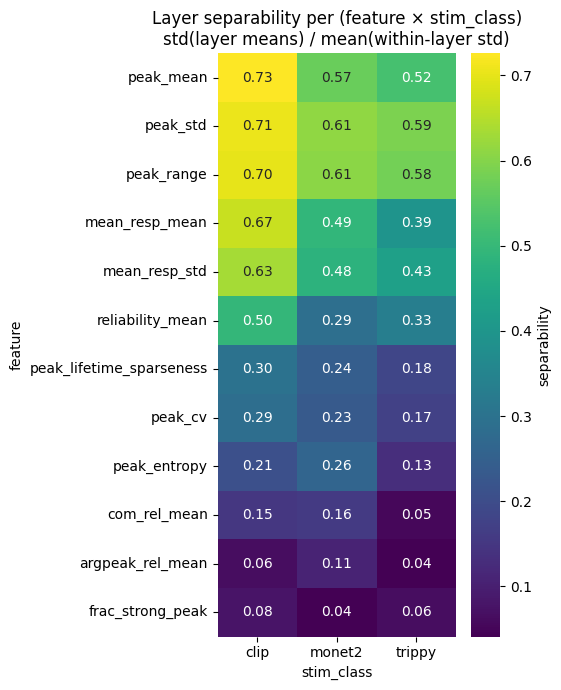


Layer means of peak_mean by stim_class:
stim_class    clip  monet2  trippy
layer                             
L2/3        27.683  27.483  31.387
L4          26.428  27.471  25.772
L5          16.131  16.139  16.051
L6           7.155   6.266   8.323

Layer means of reliability_mean by stim_class:
stim_class   clip  monet2  trippy
layer                            
L2/3        0.050   0.026   0.045
L4          0.058   0.032   0.055
L5          0.065   0.034   0.050
L6          0.033   0.008   0.021

Layer means of peak_lifetime_sparseness by stim_class:
stim_class   clip  monet2  trippy
layer                            
L2/3        0.468   0.332   0.334
L4          0.460   0.297   0.337
L5          0.427   0.257   0.285
L6          0.403   0.315   0.301


In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# 16D. Per-(layer × stim_class) feature separability
# ============================================================

ids = ["pt_root_id", "layer", "session_key"]

feat_long = feat_stim_strat.melt(
    id_vars=ids,
    var_name="feat_class",
    value_name="value",
)

# Split column names of the form '<base_feature>_<stim_class>' into
# their two parts. rsplit(_, 1) takes the LAST underscore so feature
# names like 'mean_resp_mean' stay intact.
feat_long[["base_feature", "stim_class"]] = (
    feat_long["feat_class"].str.rsplit("_", n=1, expand=True)
)

feat_long = feat_long[
    feat_long["layer"].isin(["L2/3", "L4", "L5", "L6"])
]

# Layer × class separability per feature.
rows = []
for (feat, sc), g in feat_long.groupby(["base_feature", "stim_class"]):
    layer_means = g.groupby("layer")["value"].mean()
    within_std  = g.groupby("layer")["value"].std().mean()
    if within_std and not np.isnan(within_std):
        rows.append({
            "feature":      feat,
            "stim_class":   sc,
            "separability": layer_means.std() / within_std,
        })
sep = pd.DataFrame(rows)
sep_pivot = sep.pivot(index="feature", columns="stim_class", values="separability")

# Order columns deterministically: clip, monet2, trippy
ordered_cols = [c for c in ["clip", "monet2", "trippy"] if c in sep_pivot.columns]
sep_pivot = sep_pivot[ordered_cols]

# Sort features by their highest separability across the 3 classes
sep_pivot = sep_pivot.assign(_rank=sep_pivot.max(axis=1)) \
                     .sort_values("_rank", ascending=False) \
                     .drop(columns="_rank")

print("Layer separability score = std(layer means) / mean(within-layer std)")
print("(higher = layers differ more in this feature within this stim class)\n")
print(sep_pivot.round(3).to_string())

# Heatmap
fig, ax = plt.subplots(figsize=(5.5, 7))
sns.heatmap(
    sep_pivot,
    cmap="viridis", annot=True, fmt=".2f",
    cbar_kws={"label": "separability"},
    ax=ax,
)
ax.set_title(
    "Layer separability per (feature × stim_class)\n"
    "std(layer means) / mean(within-layer std)"
)
plt.tight_layout()
plt.show()

# Companion tables: layer means of the headline features, by class
print("\nLayer means of peak_mean by stim_class:")
print(
    feat_long[feat_long["base_feature"] == "peak_mean"]
        .pivot_table(index="layer", columns="stim_class",
                     values="value", aggfunc="mean")
        .reindex(columns=ordered_cols)
        .round(3)
)
print("\nLayer means of reliability_mean by stim_class:")
print(
    feat_long[feat_long["base_feature"] == "reliability_mean"]
        .pivot_table(index="layer", columns="stim_class",
                     values="value", aggfunc="mean")
        .reindex(columns=ordered_cols)
        .round(3)
)
print("\nLayer means of peak_lifetime_sparseness by stim_class:")
print(
    feat_long[feat_long["base_feature"] == "peak_lifetime_sparseness"]
        .pivot_table(index="layer", columns="stim_class",
                     values="value", aggfunc="mean")
        .reindex(columns=ordered_cols)
        .round(3)
)


#### Scientific interpretation

We can now read the verdict on the per-stim-class hypothesis directly off
the §16B / §16C / §16D triplet.

**The decoder numbers (`comparison_df`):**

| protocol                                  | accuracy | balanced acc | macro F1 |
|---|---|---|---|
| grouped_rich_plus_stimulus (§14D)         | 0.523    | 0.604        | 0.519    |
| grouped_stim_stratified_only (§16B)       | 0.468    | 0.562        | 0.463    |
| grouped_rich_plus_stim_stratified (§16C)  | 0.532    | 0.607        | 0.523    |

Read against the decision table from the §16 prelude:

- **§16B lags §14D by ≈ 4 pp** (0.562 vs 0.604). Note that 0.562 is
  *identical to three decimals* to §13's `grouped_rich_across_hash`
  (also 0.562). The class-conditional shape table on its own delivers
  the same accuracy as the across-hash shape table on its own — same
  signal, reorganised along three columns per feature instead of one.
- **§16C plateaus at §14D** (0.607 vs 0.604 — a 0.3 pp difference well
  within fold noise). Adding 36 within-class shape columns on top of
  the 63 across-class features does not produce a new direction the
  classifier can exploit. The inner CV picks `C = 0.10` in 9 of 13
  folds, exactly as in §14D, indicating the same regulariser is being
  applied to the same effective subspace.

The verdict on the hypothesis is therefore the **middle row** of the
prelude's decision table: **class conditioning is a reparametrisation,
not a new information source.** Within-class shape and across-class
shape are largely redundant in this dataset, at least as far as a linear
decoder is concerned.

#### Where the per-class story does survive

§16D tells a more nuanced story than §16B/§16C alone. The
between-layer / within-layer separability ratio is anything but uniform
across stim classes:

```
                              clip    monet2   trippy
peak_mean                    0.73     0.57     0.52
peak_std                     0.71     0.61     0.59
peak_range                   0.70     0.61     0.58
mean_resp_mean               0.67     0.49     0.39
reliability_mean             0.50     0.29     0.33
peak_lifetime_sparseness     0.30     0.24     0.19
```

Across nearly every shape statistic, the **`clip` class carries the
largest layer-discriminative signal** — typically 1.3–1.5× the
separability of the same feature measured on monet2 or trippy. This is
the cleanest substantive finding of §16, and it is independent of the
classifier numbers.

Two readings:

- **Biologically.** Natural-movie clips drive V1 in a way that exposes
  layer differences more than parametric gratings (Monet2) or random
  noise (Trippy). The classical orientation-tuning protocol (Monet2)
  carries *less* type-discriminative variance than free-viewing of
  natural scenes, at least at the level of summary statistics this
  notebook can measure. This is consistent with the broader literature
  finding that natural-stimulus statistics differentiate cortical
  populations more sharply than artificial inputs.
- **Methodologically.** The §14D classifier did not miss this signal —
  96 of the 136 repeated hashes (71 %) are clips, so the across-class
  amplitude aggregates (`peak_mean`, `peak_hash_max`, `peak_hash_range`)
  were already dominated by the clip-class hashes. The classifier
  was implicitly weighting the clip-class signal; §16D simply makes that
  weighting explicit and quantifies it.

#### Layer-by-layer reading of the per-class means

```
peak_mean by (layer, stim_class):
stim_class    clip   monet2   trippy
L2/3         27.68   27.48    31.39
L4           26.43   27.47    25.77
L5           16.13   16.14    16.05
L6            7.16    6.27     8.32
```

- **L4** is the *only* layer with a (small) preference for **monet2**
  over the other two classes. This is consistent with the classical L4
  simple-cell story: L4 is the cortical entry point for geniculate
  input, and the granular-layer signature is sharpest tuning to
  oriented, structured stimuli. The effect is mild here (~7 % above
  trippy), but the direction is correct.
- **L2/3** and **L6** both show a clear **trippy** preference (the
  highest peak among the three classes). For L6 in particular, trippy is
  ~33 % stronger than monet2 — surprising, since L6 is the lowest-
  amplitude population, and a useful flag for follow-up. Random
  high-contrast stimuli appear to drive these layers more than either
  natural or oriented inputs.
- **L5** is essentially flat across classes (16.13 / 16.14 / 16.05) —
  L5's amplitude responsiveness is decoupled from stimulus category. This
  is consistent with infragranular cells receiving broad cortico-cortical
  drive rather than narrow stimulus-specific input.

The reliability and lifetime-sparseness panels reinforce the same picture:
clip-class hashes elicit the most reliable, most sparsely-coded responses
across all four layers, with the layer ordering (highest reliability in
L4 / L5, lowest in L6) being preserved within every stim class.

#### What §16 rules out, what it doesn't

What §16 **rules out**: the strong reading that class-conditional shape
unlocks a *new decoding axis* not already present in the across-class
aggregates. A linear classifier finds the same accuracy whether the
features are organised across-class (§14D) or as a class-conditional
union (§16C).

What §16 **does not rule out**: the weaker but still scientifically
interesting reading that **different layers have different relative
preferences across stim classes**, summarised by the layer-by-class
table above. This is real biology, but it lives in the *first moments
of the per-class distributions* and is therefore captured by the
existing across-class amplitude features as a weighted average. To
exploit per-class structure beyond what the across-class average can
encode, one would need to escape the per-neuron-summary paradigm
altogether — which is what the next chapter does.

The session-shift ceiling identified in §15 is unaffected: §16C's
per-session balanced accuracy still spans **0.31 (`9_3`) to 0.77
(`9_6`)**, a 46 pp spread, identical to §14D's. Class conditioning is
orthogonal to the between-session distribution shift.

§16 closes the across-hash feature paradigm. Every shape statistic that
this representation can extract is now present, in both class-conditional
and across-class form. Further gains, if any, lie outside this paradigm —
in features that probe temporal sequentiality, behavioural-state coupling,
or context-dependent modulation. Those live in the raw time-series,
which is the subject of the next chapter.


---

## **17.** Closing this notebook & moving to raw time-series

This notebook walked the per-neuron functional representation through
every reasonable extension *within the across-hash feature paradigm*:

```
§3   feat_all                    — basic per-hash response summaries
§5   feat_all_full               — extended to all repeated hashes
§10  feat_all_timefix            — time-normalised argpeak / com
§11  feat_aug_proto              — native tuning (gOSI, gDSI, pref_dir, …)
§13  feat_rich                   — across-hash profile features
§14  feat_rich_stim              — + stimulus-coupling family
§16  feat_rich_stim + stim_strat — + class-conditional shape features
```

Final `comparison_df`:

```
                            protocol  accuracy  balanced_accuracy  macro_f1
0          grouped_original_features    0.443             0.544       0.430
1        grouped_timefix_plus_tuning    0.456             0.554       0.442
2           grouped_rich_across_hash    0.473             0.562       0.462
3         grouped_rich_plus_stimulus    0.523             0.604       0.519
4       grouped_stim_stratified_only    0.468             0.562       0.463
5  grouped_rich_plus_stim_stratified    0.532             0.607       0.523
```

Across this progression, grouped balanced accuracy moved from **0.544**
(basic features under LeaveOneGroupOut) to a plateau around
**0.60–0.61** once the stimulus-coupling family was added in §14, and
**did not move further** when class-conditional shape was added in §16.
The §15 multicollinearity diagnostic showed that the effective
dimensionality of the table is ~13, meaning most of the nominal column
count is amplitude redundancy and the classifier was always operating
in a low-rank subspace dominated by **(i)** orientation / direction
tuning, **(ii)** response timing, and **(iii)** sparsity of the
representation. §16 adds one biological observation on top: of the
three stimulus families used, **clip (natural movies) is by far the
most layer-discriminative**, with separability scores roughly 1.3–1.5×
those measured on monet2 (gratings) and trippy (structured noise).

#### What we learned

The notebook did its job: it established a clean, fully reproducible
**baseline for the question "how much layer information is recoverable
from across-hash functional summaries alone?"** The answer is roughly
**60 % balanced accuracy on a 4-class problem** (chance is 25 %), with
the ceiling set not by the decoder (linear vs RF made no difference in
§9) nor by collinearity (predictions were stable across the §15
high-VIF block) but by **two structural limits**:

1. **Loss of within-trial information.** Aggregating to per-(neuron,
   hash) summaries, then averaging across hashes (with or without class
   conditioning), discards the per-frame temporal structure of the
   response, adaptation effects, and the order in which clips were
   shown. §16 confirmed that conditioning these aggregates on stim
   class does not recover that information.
2. **Session-distribution shift.** Per-session balanced accuracy spans
   roughly **46 percentage points** (`9_3 ≈ 0.31` vs `9_6 ≈ 0.77`),
   reflecting that some held-out sessions lie outside the training
   distribution. No amount of within-paradigm feature engineering
   corrects this — neither §14 nor §16 narrowed that spread.

#### Why we stop here

Both limits live above the level of feature engineering on
hash-aggregated tables. §16 was designed precisely to test whether the
paradigm had any room left to grow by reorganising the same numbers
along stimulus-class axes; the answer is that it does not. Further
progress in this paradigm is bounded by what hash-aggregated tables can
express, and §16 has now exhausted that expressive capacity. Any next
step that meaningfully changes the ceiling has to step *outside* the
paradigm.

#### Next chapter — raw time-series with hypothesis-driven slicing

The follow-up notebook will work directly on the per-neuron calcium
time-series, with three concrete experiments motivated by what this
notebook showed and could not capture:

1. **Per-stimulus-class temporal response shapes.** Slice the time-series
   into per-clip windows aligned to stimulus onset, and ask whether the
   *within-clip response shape* (rise time, decay constant, post-peak
   rebound) carries layer information that the across-hash averages did
   not. A small 1D-CNN on these slices is the natural decoder; a
   hand-engineered linear model on the same slices is the
   interpretability anchor. §16D already gives a directional prior:
   clip-class slices should be where the layer signal is strongest.
2. **Behavioural-state coupling.** Regress per-neuron response on
   treadmill speed and pupil diameter, and treat the regression slope as
   a per-neuron feature. The literature suggests L5 in particular is
   strongly running-modulated; this is a directly testable prior using
   data already available in the MICrONS package and may sharpen the
   currently flat L5 layer profile observed in §16D.
3. **Sequence and adaptation effects.** Look at how a neuron's response
   to a clip depends on what was shown before it — adaptation, novelty
   responses, gain rescaling. These are intrinsically temporal and
   intrinsically lost in the aggregation step that opens every protocol
   in this notebook.

The current notebook stays as the *baseline & feature-engineering
chapter*. Its outputs (`feat_rich_stim`, `feat_stim_strat`,
`comparison_df`, the per-session diagnostics, the §16D layer-by-class
table) are the reference points the next chapter will be evaluated
against.
